## Resume A — Minimal Environment + Google Drive

In [ ]:
# ============================================================
# RESUME A — MINIMAL ENVIRONMENT + GOOGLE DRIVE
# NO DATA DOWNLOAD / NO EXTRACTION / NO PRIMARY TRAINING
# ============================================================

import os
import sys
import gc
import json
import math
import time
import random
import shutil
import hashlib
import warnings
import subprocess
import importlib.util
import tarfile

from pathlib import Path
from itertools import cycle

def pip_install_missing(module_to_package):
    missing = [
        pkg
        for module, pkg in module_to_package.items()
        if importlib.util.find_spec(module) is None
    ]
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *missing]
        )
    else:
        print("✓ Required packages already available")

pip_install_missing({
    "timm": "timm==1.0.15",
    "albumentations": "albumentations",
    "cv2": "opencv-python-headless",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "pyarrow": "pyarrow",
    "tqdm": "tqdm",
    "segmentation_models_pytorch": "segmentation-models-pytorch",
    "statsmodels": "statsmodels",
    "openpyxl": "openpyxl",
})

from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

from scipy.ndimage import binary_erosion, distance_transform_edt
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive")
DATA_PROJECT = ROOT / "MTG_MambaX"
PROJECT = ROOT / "MTG_MaxViTX"

DATA = DATA_PROJECT / "data"
RAW = DATA / "raw"
EXTRACTED = DATA / "extracted"
META = DATA / "metadata"

SPLITS = PROJECT / "splits"
CHECKPOINTS = PROJECT / "checkpoints"
CACHE = PROJECT / "cache"
RESULTS = PROJECT / "results"
FIGURES = PROJECT / "figures"
STATE = PROJECT / "state"
EXPERIMENTS = PROJECT / "q1_experiments"

for p in [
    PROJECT, SPLITS, CHECKPOINTS, CACHE,
    RESULTS, FIGURES, STATE, EXPERIMENTS
]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["TORCH_HOME"] = str(PROJECT / "torch_cache")
(PROJECT / "torch_cache").mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Q1 CONFIG
# ------------------------------------------------------------

SEED = 42
IMG_SIZE = 256
BATCH_CLS = 16
BATCH_SEG = 8
NUM_WORKERS = 0

LR = 2e-4
WEIGHT_DECAY = 1e-4

MODEL_NAME = "maxvit_rmlp_tiny_rw_256.sw_in1k"

Q1_SEEDS = [42, 123, 2024, 3407, 8192]

# Main requested mode:
RUN_HEAVY_Q1_SUITE = True
RUN_FULL_Q1_SUITE = True

# Ablation is normally sufficient with one fixed seed;
# baselines + proposed reproducibility use all five seeds.
ABLATION_SEEDS = [42]

Q1_EXPERIMENT_EPOCHS = 12
Q1_EXPERIMENT_PATIENCE = 3

LAMBDA_SEG_CLS = 0.05
LAMBDA_BOUNDARY = 0.20
LAMBDA_CONSISTENCY = 0.15

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

HK_CLASSES = [
    "barretts", "bbps-0-1", "bbps-2-3", "dyed-lifted-polyps",
    "dyed-resection-margins", "hemorrhoids", "ileum", "impacted-stool",
    "normal-cecum", "normal-pylorus", "normal-z-line", "oesophagitis-a",
    "oesophagitis-b-d", "polyp", "retroflex-rectum", "retroflex-stomach",
    "short-segment-barretts", "ulcerative-colitis-0-1",
    "ulcerative-colitis-1-2", "ulcerative-colitis-2-3",
    "ulcerative-colitis-grade-1", "ulcerative-colitis-grade-2",
    "ulcerative-colitis-grade-3",
]

POLYP_LABEL = HK_CLASSES.index("polyp")

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything()

def atomic_torch_save(payload, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = Path(str(path) + ".tmp")
    torch.save(payload, tmp)
    os.replace(tmp, path)

def savefig(name):
    path = FIGURES / f"{name}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    return path

print("=" * 72)
print("Q1 RESUME MODE")
print("=" * 72)
print("Device              :", DEVICE)
print("Ablation seeds      :", ABLATION_SEEDS)
print("Baseline seeds      :", Q1_SEEDS)
print("Proposed five seeds :", Q1_SEEDS)
print("Experiment epochs   :", Q1_EXPERIMENT_EPOCHS)
print("Patience            :", Q1_EXPERIMENT_PATIENCE)
print("✓ No dataset download/extraction will run")

Installing missing packages: ['segmentation-models-pytorch']
Mounted at /content/drive
Q1 RESUME MODE
Device              : cuda
Ablation seeds      : [42]
Baseline seeds      : [42, 123, 2024, 3407, 8192]
Proposed five seeds : [42, 123, 2024, 3407, 8192]
Experiment epochs   : 12
Patience            : 3
✓ No dataset download/extraction will run


## Resume B — Load Saved Metadata + Restore Persistent Runtime Caches

In [ ]:
# ============================================================
# RESUME B — SAVED METADATA + PERSISTENT RUNTIME CACHE
# ============================================================

CLS_INDEX = META / "hyper_kvasir_classification_index_v6.parquet"
SEG_INDEX = META / "hyper_kvasir_segmentation_index_v7.parquet"
GV_MAPPED_CSV = SPLITS / "gastrovision_external_mapped.csv"

for required in [CLS_INDEX, SEG_INDEX, GV_MAPPED_CSV]:
    if not required.exists():
        raise FileNotFoundError(
            f"Required saved artifact is missing: {required}\n"
            "Do not redownload anything; use the previously completed project Drive."
        )

cls_df = pd.read_parquet(CLS_INDEX)
seg_df = pd.read_parquet(SEG_INDEX)
gv_mapped = pd.read_csv(GV_MAPPED_CSV)

# Preserve the already-used official split protocol.
cls_df["split"] = np.where(
    cls_df["fold"].eq(0),
    "test",
    np.where(cls_df["fold"].eq(1), "val", "train")
)

seg_df["split"] = np.where(
    seg_df["fold"].eq(0),
    "test",
    np.where(seg_df["fold"].eq(1), "val", "train")
)

gv_mapped["hk_label"] = gv_mapped["hk_label"].astype(int)

PERSISTENT_DIR = CACHE / "runtime_cache_archives"

CLS_ARCHIVE = (
    PERSISTENT_DIR
    / "hyper_kvasir_classification_256.tar"
)

EXT_ARCHIVE = (
    PERSISTENT_DIR
    / "gastrovision_mapped_256.tar"
)

SEG_ARCHIVE = (
    PERSISTENT_DIR
    / "hyper_kvasir_segmentation_runtime.tar"
)

SEG_RUNTIME_INDEX = (
    PERSISTENT_DIR
    / "hyper_kvasir_segmentation_runtime_index.csv"
)

LOCAL_CLS_CACHE = Path(
    "/content/MTG_MaxViTX_classification_cache_256"
)

LOCAL_EXT_CACHE = Path(
    "/content/MTG_MaxViTX_gastrovision_cache_256"
)

LOCAL_SEG_CACHE = Path(
    "/content/MTG_MaxViTX_segmentation_cache"
)

def restore_flat_archive(archive_path, target_dir, expected_count):
    target_dir.mkdir(parents=True, exist_ok=True)

    current = len(list(target_dir.glob("*.jpg")))
    if current >= expected_count:
        print(f"✓ Local cache already present: {target_dir} ({current})")
        return

    if not archive_path.exists():
        raise FileNotFoundError(
            f"Persistent cache archive missing: {archive_path}"
        )

    print("Restoring:", archive_path.name)
    with tarfile.open(archive_path, "r") as tf:
        tf.extractall(target_dir)

    restored = len(list(target_dir.glob("*.jpg")))
    print("  restored:", restored)

    if restored < expected_count:
        raise RuntimeError(
            f"Incomplete restored cache: {restored}/{expected_count}"
        )

def cached_256_path(src_path, cache_dir):
    src_path = Path(str(src_path))
    key = hashlib.md5(
        str(src_path).encode("utf-8")
    ).hexdigest()[:12]
    return cache_dir / f"{key}_{src_path.stem}.jpg"

restore_flat_archive(
    CLS_ARCHIVE,
    LOCAL_CLS_CACHE,
    len(cls_df)
)

restore_flat_archive(
    EXT_ARCHIVE,
    LOCAL_EXT_CACHE,
    len(gv_mapped)
)

# Remap the original Drive paths to the restored /content cache.
cls_df = cls_df.copy()
cls_df["path"] = cls_df["path"].map(
    lambda p: str(
        cached_256_path(p, LOCAL_CLS_CACHE)
    )
)

gv_mapped = gv_mapped.copy()
gv_mapped["path"] = gv_mapped["path"].map(
    lambda p: str(
        cached_256_path(p, LOCAL_EXT_CACHE)
    )
)

# Restore verified segmentation cache + saved runtime index.
if not SEG_RUNTIME_INDEX.exists():
    raise FileNotFoundError(
        f"Missing segmentation runtime index: {SEG_RUNTIME_INDEX}"
    )

seg_df_local = pd.read_csv(SEG_RUNTIME_INDEX)

local_seg_ok = (
    seg_df_local["image_path"]
    .map(lambda p: Path(str(p)).exists())
    .all()
    and
    seg_df_local["mask_path"]
    .map(lambda p: Path(str(p)).exists())
    .all()
)

if not local_seg_ok:
    if not SEG_ARCHIVE.exists():
        raise FileNotFoundError(
            f"Missing segmentation archive: {SEG_ARCHIVE}"
        )

    print("Restoring verified segmentation runtime cache...")
    if LOCAL_SEG_CACHE.exists():
        shutil.rmtree(LOCAL_SEG_CACHE)

    with tarfile.open(SEG_ARCHIVE, "r") as tf:
        tf.extractall(Path("/content"))

    local_seg_ok = (
        seg_df_local["image_path"]
        .map(lambda p: Path(str(p)).exists())
        .all()
        and
        seg_df_local["mask_path"]
        .map(lambda p: Path(str(p)).exists())
        .all()
    )

if not local_seg_ok:
    raise RuntimeError(
        "Segmentation runtime cache restore failed."
    )

print()
print("=" * 72)
print("RESUME DATA READY")
print("=" * 72)
print("Classification:", len(cls_df))
print("Segmentation   :", len(seg_df_local))
print("External mapped:", len(gv_mapped))
print("✓ No raw Drive image preflight performed")

Restoring: hyper_kvasir_classification_256.tar
  restored: 10619
Restoring: gastrovision_mapped_256.tar
  restored: 1780
Restoring verified segmentation runtime cache...

RESUME DATA READY
Classification: 10619
Segmentation   : 1000
External mapped: 1780
✓ No raw Drive image preflight performed


## Resume C — Rebuild Lightweight DataLoaders from the Restored Caches

In [ ]:
# ============================================================
# RESUME C — TRANSFORMS + DATASETS + LOADERS
# ============================================================

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

cls_train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.12),
    A.Rotate(
        limit=12,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.45
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.12,
        contrast_limit=0.12,
        p=0.35
    ),
    A.HueSaturationValue(
        hue_shift_limit=4,
        sat_shift_limit=8,
        val_shift_limit=8,
        p=0.20
    ),
    A.GaussNoise(
        std_range=(0.01, 0.03),
        p=0.15
    ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

eval_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

seg_train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.12),
    A.Rotate(
        limit=12,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.45
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.30
    ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

def safe_read(path, grayscale=False):
    flag = (
        cv2.IMREAD_GRAYSCALE
        if grayscale
        else cv2.IMREAD_COLOR
    )
    img = cv2.imread(str(path), flag)
    if img is not None:
        return img

    raw = np.fromfile(str(path), dtype=np.uint8)
    if raw.size:
        img = cv2.imdecode(raw, flag)
    return img

class ClassificationDataset(Dataset):
    def __init__(self, frame, transform):
        self.df = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = safe_read(r.path)

        if img is None:
            raise RuntimeError(
                f"Unreadable cached classification image: {r.path}"
            )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        x = self.transform(
            image=img
        )["image"]

        return x, int(r.label), str(r.filename)

class SegmentationDataset(Dataset):
    def __init__(self, frame, transform):
        self.df = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]

        img = safe_read(
            r.image_path
        )

        mask = safe_read(
            r.mask_path,
            grayscale=True
        )

        if img is None or mask is None:
            raise RuntimeError(
                f"Unreadable cached segmentation pair: {r.image_path}"
            )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        mask = (
            mask > 127
        ).astype(
            np.float32
        )

        out = self.transform(
            image=img,
            mask=mask
        )

        x = out["image"]
        y = out["mask"].float()

        if y.ndim == 2:
            y = y.unsqueeze(0)

        filename = getattr(
            r,
            "seg_filename",
            Path(str(r.image_path)).name
        )

        return x, y, str(filename)

class ExternalClassificationDataset(Dataset):
    def __init__(self, frame, transform):
        self.df = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]

        img = safe_read(
            r.path
        )

        if img is None:
            raise RuntimeError(
                f"Unreadable cached external image: {r.path}"
            )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        x = self.transform(
            image=img
        )["image"]

        return x, int(r.hk_label), str(r.filename)

cls_train_df = (
    cls_df[cls_df["split"].eq("train")]
    .copy()
    .reset_index(drop=True)
)

cls_val_df = (
    cls_df[cls_df["split"].eq("val")]
    .copy()
    .reset_index(drop=True)
)

cls_test_df = (
    cls_df[cls_df["split"].eq("test")]
    .copy()
    .reset_index(drop=True)
)

seg_train_df = (
    seg_df_local[seg_df_local["split"].eq("train")]
    .copy()
    .reset_index(drop=True)
)

seg_val_df = (
    seg_df_local[seg_df_local["split"].eq("val")]
    .copy()
    .reset_index(drop=True)
)

seg_test_df = (
    seg_df_local[seg_df_local["split"].eq("test")]
    .copy()
    .reset_index(drop=True)
)

# Weighted sampler: same classification imbalance handling.
class_counts = (
    cls_train_df["label"]
    .value_counts()
    .to_dict()
)

sample_weights = np.asarray([
    1.0 / class_counts[int(y)]
    for y in cls_train_df["label"].values
])

cls_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(
        sample_weights,
        dtype=torch.double
    ),
    num_samples=len(sample_weights),
    replacement=True
)

cls_train_loader = DataLoader(
    ClassificationDataset(
        cls_train_df,
        cls_train_tf
    ),
    batch_size=BATCH_CLS,
    sampler=cls_sampler,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

cls_val_loader = DataLoader(
    ClassificationDataset(
        cls_val_df,
        eval_tf
    ),
    batch_size=BATCH_CLS,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

cls_test_loader = DataLoader(
    ClassificationDataset(
        cls_test_df,
        eval_tf
    ),
    batch_size=BATCH_CLS,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

seg_train_loader = DataLoader(
    SegmentationDataset(
        seg_train_df,
        seg_train_tf
    ),
    batch_size=BATCH_SEG,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

seg_val_loader = DataLoader(
    SegmentationDataset(
        seg_val_df,
        eval_tf
    ),
    batch_size=BATCH_SEG,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

seg_test_loader = DataLoader(
    SegmentationDataset(
        seg_test_df,
        eval_tf
    ),
    batch_size=BATCH_SEG,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

external_loader = DataLoader(
    ExternalClassificationDataset(
        gv_mapped,
        eval_tf
    ),
    batch_size=BATCH_CLS,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

print("=" * 72)
print("RESUME DATALOADERS")
print("=" * 72)
print("Classification:", len(cls_train_df), len(cls_val_df), len(cls_test_df))
print("Segmentation   :", len(seg_train_df), len(seg_val_df), len(seg_test_df))
print("External       :", len(gv_mapped))
print("✓ num_workers=0")

RESUME DATALOADERS
Classification: 6388 2112 2119
Segmentation   : 598 199 203
External       : 1780
✓ num_workers=0


## Resume D — MTG-MaxViTX Architecture

In [ ]:
# ============================================================
# STAGE 11 — MTG-MAXVITX ARCHITECTURE
# ============================================================

class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3):
        super().__init__()

        groups = min(32, out_ch)
        while groups > 1 and out_ch % groups != 0:
            groups -= 1

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch, out_ch, kernel_size=k,
                padding=k // 2, bias=False
            ),
            nn.GroupNorm(groups, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleContext(nn.Module):
    def __init__(self, channels, context_dim):
        super().__init__()

        self.channels = list(channels)
        total_dim = int(sum(self.channels))

        self.multi_scale = nn.Sequential(
            nn.LayerNorm(total_dim),
            nn.Linear(total_dim, context_dim * 2),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(context_dim * 2, context_dim),
            nn.LayerNorm(context_dim),
        )

        self.single_scale = nn.Sequential(
            nn.LayerNorm(self.channels[-1]),
            nn.Linear(self.channels[-1], context_dim),
            nn.GELU(),
            nn.LayerNorm(context_dim),
        )

    def forward(self, feats, use_multiscale=True):
        if use_multiscale:
            pooled = [
                F.adaptive_avg_pool2d(f, 1).flatten(1)
                for f in feats
            ]
            return self.multi_scale(
                torch.cat(pooled, dim=1)
            )

        deepest = F.adaptive_avg_pool2d(
            feats[-1], 1
        ).flatten(1)

        return self.single_scale(deepest)


class SemanticBoundaryFPN(nn.Module):
    def __init__(
        self,
        channels,
        context_dim,
        decoder_dim=128
    ):
        super().__init__()

        self.lateral = nn.ModuleList(
            [
                nn.Conv2d(c, decoder_dim, 1)
                for c in channels
            ]
        )

        self.gates = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(context_dim, decoder_dim),
                    nn.Sigmoid(),
                )
                for _ in channels
            ]
        )

        self.refine = nn.ModuleList(
            [
                ConvGNAct(decoder_dim, decoder_dim)
                for _ in channels
            ]
        )

        self.fusion = nn.Sequential(
            ConvGNAct(
                decoder_dim * len(channels),
                decoder_dim
            ),
            nn.Dropout2d(0.10),
            ConvGNAct(decoder_dim, decoder_dim),
        )

        self.mask_head = nn.Sequential(
            ConvGNAct(decoder_dim, decoder_dim // 2),
            nn.Conv2d(decoder_dim // 2, 1, 1),
        )

        self.boundary_head = nn.Sequential(
            ConvGNAct(decoder_dim, decoder_dim // 2),
            nn.Conv2d(decoder_dim // 2, 1, 1),
        )

    def forward(
        self,
        feats,
        semantic_context,
        output_size,
        use_gating=True,
        use_boundary=True
    ):
        lateral = []

        for feat, projection, gate_layer in zip(
            feats, self.lateral, self.gates
        ):
            x = projection(feat)

            if use_gating:
                gate = gate_layer(
                    semantic_context
                ).unsqueeze(-1).unsqueeze(-1)

                x = x * (0.5 + gate)

            lateral.append(x)

        pyramid = [None] * len(lateral)
        pyramid[-1] = self.refine[-1](
            lateral[-1]
        )

        for i in range(
            len(lateral) - 2, -1, -1
        ):
            up = F.interpolate(
                pyramid[i + 1],
                size=lateral[i].shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            pyramid[i] = self.refine[i](
                lateral[i] + up
            )

        target = pyramid[0].shape[-2:]

        resized = [
            F.interpolate(
                p,
                size=target,
                mode="bilinear",
                align_corners=False
            )
            for p in pyramid
        ]

        fused = self.fusion(
            torch.cat(resized, dim=1)
        )

        mask_logits = self.mask_head(fused)
        mask_logits = F.interpolate(
            mask_logits,
            size=output_size,
            mode="bilinear",
            align_corners=False
        )

        boundary_logits = None

        if use_boundary:
            boundary_logits = self.boundary_head(
                pyramid[0]
            )
            boundary_logits = F.interpolate(
                boundary_logits,
                size=output_size,
                mode="bilinear",
                align_corners=False
            )

        return mask_logits, boundary_logits


class MTGMaxViTX(nn.Module):
    def __init__(
        self,
        num_classes=len(HK_CLASSES),
        model_name=MODEL_NAME,
        decoder_dim=128,
        use_multiscale_context=True,
        use_semantic_gating=True,
        use_boundary_head=True
    ):
        super().__init__()

        self.use_multiscale_context = bool(
            use_multiscale_context
        )
        self.use_semantic_gating = bool(
            use_semantic_gating
        )
        self.use_boundary_head = bool(
            use_boundary_head
        )

        self.encoder = timm.create_model(
            model_name,
            pretrained=True,
            features_only=True,
            out_indices=(1, 2, 3, 4)
        )

        self.feature_channels = list(
            self.encoder.feature_info.channels()
        )

        if len(self.feature_channels) != 4:
            raise RuntimeError(
                f"Expected 4 MaxViT feature stages, "
                f"received {self.feature_channels}"
            )

        context_dim = int(
            self.feature_channels[-1]
        )

        self.context = MultiScaleContext(
            self.feature_channels,
            context_dim
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(context_dim),
            nn.Dropout(0.25),
            nn.Linear(context_dim, num_classes),
        )

        self.class_semantic_embedding = nn.Sequential(
            nn.Linear(num_classes, context_dim),
            nn.GELU(),
            nn.Linear(context_dim, context_dim),
            nn.LayerNorm(context_dim),
        )

        self.decoder = SemanticBoundaryFPN(
            self.feature_channels,
            context_dim,
            decoder_dim=decoder_dim
        )

    def forward(
        self,
        x,
        task="both",
        return_features=False
    ):
        if task not in {"both", "cls", "seg"}:
            raise ValueError(
                f"Unsupported task: {task}"
            )

        feats = self.encoder(x)

        context = self.context(
            feats,
            use_multiscale=self.use_multiscale_context
        )

        cls_logits = self.classifier(context)

        disease_prob = torch.softmax(
            cls_logits, dim=1
        )

        semantic_context = (
            context
            +
            self.class_semantic_embedding(
                disease_prob
            )
        )

        out = {}

        if task in {"both", "cls"}:
            out["cls"] = cls_logits

        if task in {"both", "seg"}:
            seg_logits, boundary_logits = self.decoder(
                feats,
                semantic_context,
                x.shape[-2:],
                use_gating=self.use_semantic_gating,
                use_boundary=self.use_boundary_head
            )

            out["seg"] = seg_logits

            if boundary_logits is not None:
                out["boundary"] = boundary_logits

            flat = seg_logits.flatten(1)

            smooth_max = (
                torch.logsumexp(flat, dim=1)
                -
                math.log(flat.shape[1])
            )

            out["seg_presence"] = torch.sigmoid(
                smooth_max
            )

        if return_features:
            out["pooled"] = context
            out["features"] = feats
            out["semantic_context"] = semantic_context

        return out


## Resume E — Losses + Metrics Needed by Q1 Experiments

In [ ]:
# ============================================================
# RESUME E — LOSSES + METRICS
# ============================================================

def soft_dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    dims = tuple(range(1, probs.ndim))
    inter = (probs * targets).sum(dims)
    denom = probs.sum(dims) + targets.sum(dims)
    return (
        1
        -
        (2 * inter + eps)
        /
        (denom + eps)
    ).mean()

def gradient_boundary_loss(logits, targets):
    probs = torch.sigmoid(logits)

    kx = torch.tensor(
        [[-1,0,1],[-2,0,2],[-1,0,1]],
        dtype=probs.dtype,
        device=probs.device
    ).view(1,1,3,3)

    ky = kx.transpose(2,3)

    pg = torch.sqrt(
        F.conv2d(probs, kx, padding=1).pow(2)
        +
        F.conv2d(probs, ky, padding=1).pow(2)
        +
        1e-6
    )

    tg = torch.sqrt(
        F.conv2d(targets, kx, padding=1).pow(2)
        +
        F.conv2d(targets, ky, padding=1).pow(2)
        +
        1e-6
    )

    return F.l1_loss(pg, tg)

def make_boundary_target(targets):
    dilated = F.max_pool2d(
        targets, 3, stride=1, padding=1
    )
    eroded = -F.max_pool2d(
        -targets, 3, stride=1, padding=1
    )
    return (
        dilated - eroded
    ).clamp(0,1)

def segmentation_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets
    )
    dice = soft_dice_loss(
        logits,
        targets
    )
    edge = gradient_boundary_loss(
        logits,
        targets
    )
    return (
        0.40*bce
        +
        0.45*dice
        +
        0.15*edge
    )

def explicit_boundary_loss(boundary_logits, targets):
    boundary_target = make_boundary_target(
        targets
    )
    bce = F.binary_cross_entropy_with_logits(
        boundary_logits,
        boundary_target
    )
    dice = soft_dice_loss(
        boundary_logits,
        boundary_target
    )
    return 0.60*bce + 0.40*dice

def cross_task_consistency_loss(cls_logits, seg_presence):
    p_polyp = torch.softmax(
        cls_logits,
        dim=1
    )[:, POLYP_LABEL]

    return F.smooth_l1_loss(
        p_polyp,
        seg_presence
    )

def multiclass_ece(y, probs, n_bins=15):
    y = np.asarray(y)
    probs = np.asarray(probs)

    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y).astype(float)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (conf > lo) & (conf <= hi)
        if not mask.any():
            continue
        ece += (
            mask.mean()
            *
            abs(
                correct[mask].mean()
                -
                conf[mask].mean()
            )
        )

    return float(ece)

def classification_metrics(y, pred, probs, labels=None):
    y = np.asarray(y)
    pred = np.asarray(pred)
    probs = np.asarray(probs)

    if labels is None:
        labels = np.arange(
            len(HK_CLASSES)
        )
    labels = np.asarray(labels)

    p, r, f, _ = precision_recall_fscore_support(
        y,
        pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y,
        pred,
        average="weighted",
        zero_division=0
    )

    out = {
        "accuracy":
            float(accuracy_score(y, pred)),
        "balanced_accuracy":
            float(balanced_accuracy_score(y, pred)),
        "macro_precision":
            float(p),
        "macro_recall":
            float(r),
        "macro_f1":
            float(f),
        "weighted_f1":
            float(weighted_f1),
        "mcc":
            float(matthews_corrcoef(y, pred)),
        "ece":
            float(multiclass_ece(y, probs)),
        "brier_multiclass":
            float(
                np.mean(
                    np.sum(
                        (
                            probs
                            -
                            np.eye(
                                probs.shape[1]
                            )[y]
                        )**2,
                        axis=1
                    )
                )
            ),
    }

    try:
        present = sorted(
            set(y.tolist())
        )

        if len(present) > 1:
            y_bin = np.eye(
                probs.shape[1]
            )[y][:, present]

            p_sub = probs[:, present]
            p_sub = (
                p_sub
                /
                (
                    p_sub.sum(
                        axis=1,
                        keepdims=True
                    )
                    +
                    1e-12
                )
            )

            out["macro_auroc_ovr"] = float(
                roc_auc_score(
                    y_bin,
                    p_sub,
                    average="macro",
                    multi_class="ovr"
                )
            )
        else:
            out["macro_auroc_ovr"] = np.nan

    except Exception:
        out["macro_auroc_ovr"] = np.nan

    return out

def boundary_f1(pred, gt, tolerance=2):
    pred = np.asarray(pred).astype(bool)
    gt = np.asarray(gt).astype(bool)

    pred_edge = pred ^ binary_erosion(pred)
    gt_edge = gt ^ binary_erosion(gt)

    if not pred_edge.any() and not gt_edge.any():
        return 1.0

    if not pred_edge.any() or not gt_edge.any():
        return 0.0

    gt_dist = distance_transform_edt(
        ~gt_edge
    )
    pred_dist = distance_transform_edt(
        ~pred_edge
    )

    pred_match = (
        gt_dist[pred_edge] <= tolerance
    ).mean()

    gt_match = (
        pred_dist[gt_edge] <= tolerance
    ).mean()

    return float(
        2
        *
        pred_match
        *
        gt_match
        /
        (
            pred_match
            +
            gt_match
            +
            1e-12
        )
    )

print("✓ Q1 losses and metrics ready")

✓ Q1 losses and metrics ready


## Stage 31R — Checkpoint-Safe Q1 Experiment Engine

In [ ]:
# ============================================================
# STAGE 31R — CHECKPOINT-SAFE Q1 EXPERIMENT ENGINE
# ============================================================

def q1_class_weights():
    cp = np.sort(
        cls_train_df.label.unique()
    )

    w = compute_class_weight(
        class_weight="balanced",
        classes=cp,
        y=cls_train_df.label.values
    )

    out = torch.ones(
        len(HK_CLASSES),
        dtype=torch.float32
    )

    out[cp] = torch.tensor(
        w,
        dtype=torch.float32
    )

    return out.to(DEVICE)

Q1_CLASS_WEIGHTS = q1_class_weights()

@torch.no_grad()
def q1_predict_cls(model_obj, loader, plain=False):
    model_obj.eval()

    ys, preds, probs, names, latency = (
        [],
        [],
        [],
        [],
        [],
    )

    for x, y, fn in loader:
        x = x.to(
            DEVICE,
            non_blocking=True
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()

        if plain:
            logits = model_obj(x)
        else:
            logits = model_obj(
                x,
                task="cls"
            )["cls"]

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        latency.append(
            (
                time.perf_counter()
                -
                t0
            )
            /
            len(x)
        )

        pr = torch.softmax(
            logits,
            dim=1
        )

        ys.extend(
            y.numpy()
        )

        preds.extend(
            pr.argmax(1)
            .cpu()
            .numpy()
        )

        probs.append(
            pr.cpu().numpy()
        )

        names.extend(fn)

    return (
        np.asarray(ys),
        np.asarray(preds),
        np.concatenate(probs),
        names,
        np.asarray(latency),
    )

@torch.no_grad()
def q1_predict_seg(model_obj, loader, plain=False):
    model_obj.eval()
    rows = []

    for x, y, fn in loader:
        x = x.to(
            DEVICE,
            non_blocking=True
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()

        if plain:
            logits = model_obj(x)
        else:
            logits = model_obj(
                x,
                task="seg"
            )["seg"]

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        latency = (
            time.perf_counter()
            -
            t0
        ) / len(x)

        pred = (
            torch.sigmoid(logits)
            .cpu()
            .numpy()
            >
            0.5
        )

        gt = (
            y.numpy()
            >
            0.5
        )

        for i in range(len(fn)):
            a = pred[i,0]
            b = gt[i,0]

            tp = np.logical_and(
                a,
                b
            ).sum()

            fp = np.logical_and(
                a,
                ~b
            ).sum()

            fnv = np.logical_and(
                ~a,
                b
            ).sum()

            dice = (
                2*tp + 1e-9
            ) / (
                2*tp + fp + fnv + 1e-9
            )

            iou = (
                tp + 1e-9
            ) / (
                tp + fp + fnv + 1e-9
            )

            rows.append({
                "filename":
                    fn[i],
                "dice":
                    float(dice),
                "iou":
                    float(iou),
                "boundary_f1":
                    boundary_f1(a,b),
                "latency_ms":
                    float(latency*1000),
            })

    return pd.DataFrame(rows)

def q1_eval_multitask(model_obj):
    y, p, prob, names, lat = q1_predict_cls(
        model_obj,
        cls_test_loader
    )

    cls_m = classification_metrics(
        y,
        p,
        prob
    )

    seg_m = q1_predict_seg(
        model_obj,
        seg_test_loader
    )

    ey, ep, eprob, _, _ = q1_predict_cls(
        model_obj,
        external_loader
    )

    ext_labels = sorted(
        gv_mapped.hk_label.unique().tolist()
    )

    ext_m = classification_metrics(
        ey,
        ep,
        eprob,
        labels=ext_labels
    )

    return {
        "y": y,
        "pred": p,
        "prob": prob,
        "names": names,
        "cls": cls_m,
        "seg": seg_m,
        "external": ext_m,
        "latency_ms":
            float(lat.mean()*1000),
    }


def q1_cleanup():
    import gc
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass


def make_interleaved_task_schedule(
    n_cls,
    n_seg,
    seed
):
    """
    One-pass multi-task schedule.

    Exactly one pass through classification batches and exactly
    one pass through segmentation batches per epoch.

    This corrects the previous protocol that cycled the much
    smaller segmentation loader to match the classification
    loader length.
    """
    schedule = (
        ["cls"] * int(n_cls)
        +
        ["seg"] * int(n_seg)
    )

    rng = random.Random(
        int(seed)
    )

    rng.shuffle(
        schedule
    )

    return schedule


def q1_fit_multitask(
    experiment_name,
    seed,
    use_multiscale_context=True,
    use_semantic_gating=True,
    use_boundary_head=True,
    lambda_consistency=LAMBDA_CONSISTENCY,
    lambda_boundary=LAMBDA_BOUNDARY,
    multitask=True,
    output_group=None,
    max_epochs=None,
    patience=None,
):
    """
    Checkpoint-safe corrected MTG-MaxViTX multi-task trainer.

    Key correction:
        classification loader = one pass / epoch
        segmentation loader   = one pass / epoch
        optimizer updates are randomly interleaved

    No segmentation cycling is used.

    Resume artifacts:
        resume.pt
        best.pt
        training_history.csv

    Final artifacts:
        metrics.json
        classification_predictions.npz
        segmentation_per_image.csv
    """

    max_epochs = (
        Q1_EXPERIMENT_EPOCHS
        if max_epochs is None
        else int(max_epochs)
    )

    patience = (
        Q1_EXPERIMENT_PATIENCE
        if patience is None
        else int(patience)
    )

    safe = (
        experiment_name
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    if output_group is None:
        out_dir = (
            EXPERIMENTS
            / safe
            / f"seed_{seed}"
        )
    else:
        out_dir = (
            EXPERIMENTS
            / output_group
            / safe
            / f"seed_{seed}"
        )

    out_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    metric_path = out_dir / "metrics.json"
    pred_path = out_dir / "classification_predictions.npz"
    seg_path = out_dir / "segmentation_per_image.csv"
    resume_path = out_dir / "resume.pt"
    best_path = out_dir / "best.pt"
    history_path = out_dir / "training_history.csv"

    if (
        metric_path.exists()
        and pred_path.exists()
        and seg_path.exists()
    ):
        print(
            f"✓ COMPLETE — skipping "
            f"{experiment_name} | seed={seed}"
        )

        return json.loads(
            metric_path.read_text()
        )

    seed_everything(
        seed
    )

    q1_cleanup()

    m = MTGMaxViTX(
        use_multiscale_context=
            use_multiscale_context,
        use_semantic_gating=
            use_semantic_gating,
        use_boundary_head=
            use_boundary_head
    ).to(
        DEVICE
    )

    criterion = nn.CrossEntropyLoss(
        weight=Q1_CLASS_WEIGHTS,
        label_smoothing=0.05
    )

    opt = torch.optim.AdamW(
        m.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    sched = (
        torch.optim.lr_scheduler
        .CosineAnnealingLR(
            opt,
            T_max=max_epochs,
            eta_min=LR * 0.02
        )
    )

    amp = torch.amp.GradScaler(
        "cuda",
        enabled=DEVICE.type == "cuda"
    )

    start_epoch = 0
    best_score = -np.inf
    bad = 0

    history = []

    if history_path.exists():
        try:
            history = (
                pd.read_csv(
                    history_path
                )
                .to_dict(
                    "records"
                )
            )
        except Exception:
            history = []

    if resume_path.exists():
        state = torch.load(
            resume_path,
            map_location=DEVICE,
            weights_only=False
        )

        m.load_state_dict(
            state["model"]
        )

        opt.load_state_dict(
            state["optimizer"]
        )

        try:
            sched.load_state_dict(
                state["scheduler"]
            )
        except Exception:
            pass

        try:
            amp.load_state_dict(
                state["scaler"]
            )
        except Exception:
            pass

        start_epoch = (
            int(
                state["epoch"]
            )
            +
            1
        )

        best_score = float(
            state.get(
                "best_score",
                -np.inf
            )
        )

        bad = int(
            state.get(
                "bad",
                0
            )
        )

        print(
            f"✓ RESUME {experiment_name} | seed={seed} "
            f"from epoch {start_epoch + 1}"
        )

        del state

    elif best_path.exists():
        best_state = torch.load(
            best_path,
            map_location="cpu",
            weights_only=False
        )

        best_score = float(
            best_state.get(
                "best_score",
                -np.inf
            )
        )

        del best_state

    n_cls_batches = len(
        cls_train_loader
    )

    n_seg_batches = len(
        seg_train_loader
    )

    print()
    print("=" * 78)
    print(
        f"CORRECTED ONE-PASS TRAINING: "
        f"{experiment_name} | seed={seed}"
    )
    print("=" * 78)
    print(
        "Classification batches/epoch:",
        n_cls_batches
    )
    print(
        "Segmentation batches/epoch  :",
        n_seg_batches
    )
    print(
        "Classification passes/epoch : 1.00"
    )
    print(
        "Segmentation passes/epoch   : 1.00"
    )
    print(
        "Total optimizer steps/epoch :",
        n_cls_batches + n_seg_batches
    )
    print(
        "Max epochs                  :",
        max_epochs
    )
    print(
        "Patience                    :",
        patience
    )

    # If an interrupted run had already met patience or finished
    # the max epoch, skip training and go directly to evaluation.
    training_finished = (
        start_epoch >= max_epochs
        or bad >= patience
    )

    if not training_finished:

        for epoch in range(
            start_epoch,
            max_epochs
        ):

            m.train()

            cls_iter = iter(
                cls_train_loader
            )

            seg_iter = iter(
                seg_train_loader
            )

            schedule = (
                make_interleaved_task_schedule(
                    n_cls=n_cls_batches,
                    n_seg=n_seg_batches,
                    seed=(
                        seed
                        +
                        epoch
                        *
                        1009
                    )
                )
            )

            cls_loss_sum = 0.0
            seg_loss_sum = 0.0
            cls_steps = 0
            seg_steps = 0

            pbar = tqdm(
                schedule,
                desc=(
                    f"{experiment_name} | seed={seed} "
                    f"| epoch={epoch+1}/{max_epochs}"
                )
            )

            for task_name in pbar:

                opt.zero_grad(
                    set_to_none=True
                )

                # --------------------------------------------
                # CLASSIFICATION UPDATE
                # --------------------------------------------
                if task_name == "cls":

                    cx, cy, _ = next(
                        cls_iter
                    )

                    cx = cx.to(
                        DEVICE,
                        non_blocking=True
                    )

                    cy = cy.to(
                        DEVICE,
                        non_blocking=True
                    )

                    with torch.amp.autocast(
                        "cuda",
                        enabled=DEVICE.type == "cuda"
                    ):

                        cls_out = m(
                            cx,
                            task="cls"
                        )

                        loss = criterion(
                            cls_out["cls"],
                            cy
                        )

                    amp.scale(
                        loss
                    ).backward()

                    amp.unscale_(
                        opt
                    )

                    torch.nn.utils.clip_grad_norm_(
                        m.parameters(),
                        1.0
                    )

                    amp.step(
                        opt
                    )

                    amp.update()

                    cls_loss_sum += float(
                        loss.item()
                    )

                    cls_steps += 1

                    pbar.set_postfix(
                        task="CLS",
                        loss=f"{loss.item():.3f}"
                    )

                    del (
                        cx,
                        cy,
                        cls_out,
                        loss
                    )

                # --------------------------------------------
                # SEGMENTATION UPDATE
                # --------------------------------------------
                else:

                    sx, sy, _ = next(
                        seg_iter
                    )

                    sx = sx.to(
                        DEVICE,
                        non_blocking=True
                    )

                    sy = sy.to(
                        DEVICE,
                        non_blocking=True
                    )

                    with torch.amp.autocast(
                        "cuda",
                        enabled=DEVICE.type == "cuda"
                    ):

                        seg_out = m(
                            sx,
                            task=(
                                "both"
                                if multitask
                                else "seg"
                            )
                        )

                        l_seg = segmentation_loss(
                            seg_out["seg"],
                            sy
                        )

                        loss = l_seg

                        if multitask:

                            polyp_y = torch.full(
                                (len(sx),),
                                POLYP_LABEL,
                                dtype=torch.long,
                                device=DEVICE
                            )

                            l_seg_cls = criterion(
                                seg_out["cls"],
                                polyp_y
                            )

                            l_cons = (
                                cross_task_consistency_loss(
                                    seg_out["cls"],
                                    seg_out["seg_presence"]
                                )
                            )

                            if (
                                use_boundary_head
                                and
                                "boundary"
                                in seg_out
                            ):
                                l_bnd = (
                                    explicit_boundary_loss(
                                        seg_out["boundary"],
                                        sy
                                    )
                                )
                            else:
                                l_bnd = torch.zeros(
                                    (),
                                    device=DEVICE
                                )

                            loss = (
                                l_seg
                                +
                                LAMBDA_SEG_CLS
                                *
                                l_seg_cls
                                +
                                lambda_consistency
                                *
                                l_cons
                                +
                                lambda_boundary
                                *
                                l_bnd
                            )

                    amp.scale(
                        loss
                    ).backward()

                    amp.unscale_(
                        opt
                    )

                    torch.nn.utils.clip_grad_norm_(
                        m.parameters(),
                        1.0
                    )

                    amp.step(
                        opt
                    )

                    amp.update()

                    seg_loss_sum += float(
                        loss.item()
                    )

                    seg_steps += 1

                    pbar.set_postfix(
                        task="SEG",
                        loss=f"{loss.item():.3f}"
                    )

                    if multitask:
                        del (
                            sx,
                            sy,
                            seg_out,
                            l_seg,
                            l_seg_cls,
                            l_cons,
                            l_bnd,
                            polyp_y,
                            loss
                        )
                    else:
                        del (
                            sx,
                            sy,
                            seg_out,
                            l_seg,
                            loss
                        )

            sched.step()

            # --------------------------------------------
            # VALIDATION
            # --------------------------------------------
            vy, vp, _, _, _ = q1_predict_cls(
                m,
                cls_val_loader
            )

            vf1 = f1_score(
                vy,
                vp,
                average="macro",
                zero_division=0
            )

            vseg = q1_predict_seg(
                m,
                seg_val_loader
            )

            vdice = float(
                vseg["dice"].mean()
            )

            vbf1 = float(
                vseg["boundary_f1"].mean()
            )

            score = (
                0.5
                *
                vf1
                +
                0.5
                *
                vdice
            )

            improved = (
                score
                >
                best_score
                +
                1e-4
            )

            if improved:

                best_score = float(
                    score
                )

                bad = 0

                atomic_torch_save(
                    {
                        "model":
                            m.state_dict(),
                        "epoch":
                            int(epoch),
                        "best_score":
                            float(best_score),
                        "val_macro_f1":
                            float(vf1),
                        "val_dice":
                            float(vdice),
                        "val_boundary_f1":
                            float(vbf1),
                    },
                    best_path
                )

            else:
                bad += 1

            epoch_row = {
                "epoch":
                    int(epoch + 1),
                "cls_steps":
                    int(cls_steps),
                "seg_steps":
                    int(seg_steps),
                "cls_loss":
                    float(
                        cls_loss_sum
                        /
                        max(cls_steps, 1)
                    ),
                "seg_loss":
                    float(
                        seg_loss_sum
                        /
                        max(seg_steps, 1)
                    ),
                "val_macro_f1":
                    float(vf1),
                "val_dice":
                    float(vdice),
                "val_boundary_f1":
                    float(vbf1),
                "score":
                    float(score),
                "best_score":
                    float(best_score),
                "bad":
                    int(bad),
                "lr":
                    float(
                        opt.param_groups[0]["lr"]
                    ),
            }

            history.append(
                epoch_row
            )

            pd.DataFrame(
                history
            ).to_csv(
                history_path,
                index=False
            )

            atomic_torch_save(
                {
                    "model":
                        m.state_dict(),
                    "optimizer":
                        opt.state_dict(),
                    "scheduler":
                        sched.state_dict(),
                    "scaler":
                        amp.state_dict(),
                    "epoch":
                        int(epoch),
                    "best_score":
                        float(best_score),
                    "bad":
                        int(bad),
                },
                resume_path
            )

            print(
                epoch_row
            )

            del (
                vy,
                vp,
                vseg
            )

            q1_cleanup()

            if bad >= patience:
                print(
                    "Early stopping."
                )
                break

    if not best_path.exists():
        raise RuntimeError(
            f"No best checkpoint created for "
            f"{experiment_name} seed={seed}"
        )

    best = torch.load(
        best_path,
        map_location=DEVICE,
        weights_only=False
    )

    m.load_state_dict(
        best["model"]
    )

    selected_best_epoch = (
        int(
            best.get(
                "epoch",
                -1
            )
        )
        +
        1
    )

    ev = q1_eval_multitask(
        m
    )

    row = {
        "experiment":
            experiment_name,
        "protocol":
            "balanced_one_pass_v2",
        "seed":
            int(seed),
        "max_epochs":
            int(max_epochs),
        "selected_best_epoch":
            int(selected_best_epoch),
        "macro_f1":
            float(
                ev["cls"]["macro_f1"]
            ),
        "accuracy":
            float(
                ev["cls"]["accuracy"]
            ),
        "mcc":
            float(
                ev["cls"]["mcc"]
            ),
        "ece":
            float(
                ev["cls"]["ece"]
            ),
        "dice":
            float(
                ev["seg"]["dice"].mean()
            ),
        "iou":
            float(
                ev["seg"]["iou"].mean()
            ),
        "boundary_f1":
            float(
                ev["seg"]["boundary_f1"].mean()
            ),
        "external_macro_f1":
            float(
                ev["external"]["macro_f1"]
            ),
        "classification_latency_ms":
            float(
                ev["latency_ms"]
            ),
        "segmentation_latency_ms":
            float(
                ev["seg"]["latency_ms"].mean()
            ),
        "parameters_m":
            float(
                sum(
                    p.numel()
                    for p in m.parameters()
                )
                /
                1e6
            ),
        "cls_batches_per_epoch":
            int(n_cls_batches),
        "seg_batches_per_epoch":
            int(n_seg_batches),
        "segmentation_passes_per_epoch":
            1.0,
    }

    metric_path.write_text(
        json.dumps(
            row,
            indent=2
        )
    )

    np.savez_compressed(
        pred_path,
        y=ev["y"],
        pred=ev["pred"],
        prob=ev["prob"],
        names=np.asarray(
            ev["names"]
        )
    )

    ev["seg"].to_csv(
        seg_path,
        index=False
    )

    try:
        resume_path.unlink(
            missing_ok=True
        )
    except Exception:
        pass

    del (
        m,
        best,
        ev
    )

    q1_cleanup()

    return row


print(
    "✓ Corrected checkpoint-safe one-pass Q1 engine ready"
)


✓ Corrected checkpoint-safe one-pass Q1 engine ready


## Resume Status — See What Is Already Complete Before Spending GPU Time

In [ ]:
# ============================================================
# Q1 RESUME STATUS
# ============================================================

def q1_run_status():
    rows = []

    # Proposed five runs
    for seed in Q1_SEEDS:
        d = (
            EXPERIMENTS
            / "five_run_full_mtg_maxvitx"
            / f"seed_{seed}"
        )

        rows.append({
            "group": "Proposed five-run",
            "method": "MTG-MaxViTX",
            "seed": seed,
            "complete": (d/"metrics.json").exists(),
            "resume": (d/"resume.pt").exists(),
            "best": (d/"best.pt").exists(),
        })

    # Classification baselines
    cls_names = [
        "resnet-50",
        "efficientnet-b0",
        "convnext-tiny",
        "swin-tiny",
        "vit-s_16",
        "maxvit-tiny_single-task",
    ]

    # The exact safe folder names will be discovered too.
    base_root = (
        EXPERIMENTS
        / "classification_baselines"
    )

    if base_root.exists():
        for method_dir in sorted(
            p for p in base_root.iterdir()
            if p.is_dir()
        ):
            for seed in Q1_SEEDS:
                d = method_dir / f"seed_{seed}"
                rows.append({
                    "group": "Classification baseline",
                    "method": method_dir.name,
                    "seed": seed,
                    "complete": (d/"metrics.json").exists(),
                    "resume": (d/"resume.pt").exists(),
                    "best": (d/"best.pt").exists(),
                })

    seg_root = (
        EXPERIMENTS
        / "segmentation_baselines"
    )

    if seg_root.exists():
        for method_dir in sorted(
            p for p in seg_root.iterdir()
            if p.is_dir()
        ):
            for seed in Q1_SEEDS:
                d = method_dir / f"seed_{seed}"
                rows.append({
                    "group": "Segmentation baseline",
                    "method": method_dir.name,
                    "seed": seed,
                    "complete": (d/"metrics.json").exists(),
                    "resume": (d/"resume.pt").exists(),
                    "best": (d/"best.pt").exists(),
                })

    status_df = pd.DataFrame(rows)

    if len(status_df):
        display(status_df)
        print()
        print(
            status_df
            .groupby("group")[
                ["complete", "resume"]
            ]
            .sum()
        )

    return status_df

status_df = q1_run_status()

,group,method,seed,complete,resume,best
0,Proposed five-run,MTG-MaxViTX,42,False,False,False
1,Proposed five-run,MTG-MaxViTX,123,False,False,False
2,Proposed five-run,MTG-MaxViTX,2024,False,False,False
3,Proposed five-run,MTG-MaxViTX,3407,False,False,False
4,Proposed five-run,MTG-MaxViTX,8192,False,False,False
5,Classification baseline,convnext-tiny,42,True,False,True
6,Classification baseline,convnext-tiny,123,True,False,True
7,Classification baseline,convnext-tiny,2024,True,False,True
8,Classification baseline,convnext-tiny,3407,True,False,True
9,Classification baseline,convnext-tiny,8192,True,False,True



                         complete  resume
group                                    
Classification baseline        30       0
Proposed five-run               0       0
Segmentation baseline          25       0


## Stage 32R-V2 — Corrected One-Pass Ablation Study

The only targeted methodological correction is removal of repeated segmentation cycling. Each classification batch and each segmentation batch is consumed exactly once per epoch. Existing single-task results are reused/resumed because those two models already used one pass per task.


In [ ]:
# ============================================================
# STAGE 32R — CHECKPOINT-SAFE ABLATION STUDY
# ============================================================

def q1_fit_single_task_pair(
    experiment_name,
    seed
):
    """
    Checkpoint-safe genuine single-task ablation.
    Separate MaxViT models for classification and segmentation.
    """

    safe = (
        experiment_name
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    out_dir = (
        EXPERIMENTS
        / safe
        / f"seed_{seed}"
    )

    out_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    metric_path = out_dir / "metrics.json"
    pred_path = out_dir / "classification_predictions.npz"
    seg_path = out_dir / "segmentation_per_image.csv"

    cls_resume = out_dir / "cls_resume.pt"
    cls_best = out_dir / "cls_best.pt"
    seg_resume = out_dir / "seg_resume.pt"
    seg_best = out_dir / "seg_best.pt"

    if (
        metric_path.exists()
        and pred_path.exists()
        and seg_path.exists()
    ):
        print(
            f"✓ COMPLETE — skipping {experiment_name} seed={seed}"
        )
        return json.loads(
            metric_path.read_text()
        )

    seed_everything(seed)

    criterion = nn.CrossEntropyLoss(
        weight=Q1_CLASS_WEIGHTS,
        label_smoothing=0.05
    )

    # ========================================================
    # CLASSIFICATION-ONLY
    # ========================================================

    cls_model = MTGMaxViTX(
        use_multiscale_context=True,
        use_semantic_gating=False,
        use_boundary_head=False
    ).to(DEVICE)

    cls_opt = torch.optim.AdamW(
        cls_model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    cls_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        cls_opt,
        T_max=Q1_EXPERIMENT_EPOCHS,
        eta_min=LR*0.02
    )

    cls_amp = torch.amp.GradScaler(
        "cuda",
        enabled=DEVICE.type == "cuda"
    )

    cls_start = 0
    best_f1 = -np.inf
    bad = 0

    if cls_resume.exists():
        st = torch.load(
            cls_resume,
            map_location=DEVICE,
            weights_only=False
        )

        cls_model.load_state_dict(
            st["model"]
        )

        cls_opt.load_state_dict(
            st["optimizer"]
        )

        cls_sched.load_state_dict(
            st["scheduler"]
        )

        try:
            cls_amp.load_state_dict(
                st["scaler"]
            )
        except Exception:
            pass

        cls_start = int(
            st["epoch"]
        ) + 1

        best_f1 = float(
            st.get("best_f1", -np.inf)
        )

        bad = int(
            st.get("bad", 0)
        )

        print(
            f"✓ Resume single-task classification "
            f"from epoch {cls_start+1}"
        )

    for epoch in range(
        cls_start,
        Q1_EXPERIMENT_EPOCHS
    ):
        cls_model.train()

        for x, y, _ in tqdm(
            cls_train_loader,
            desc=(
                f"Single-task CLS seed={seed} "
                f"epoch={epoch+1}"
            ),
            leave=False
        ):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            cls_opt.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda",
                enabled=DEVICE.type == "cuda"
            ):
                logits = cls_model(
                    x,
                    task="cls"
                )["cls"]

                loss = criterion(
                    logits,
                    y
                )

            cls_amp.scale(loss).backward()
            cls_amp.unscale_(cls_opt)

            torch.nn.utils.clip_grad_norm_(
                cls_model.parameters(),
                1.0
            )

            cls_amp.step(cls_opt)
            cls_amp.update()

        cls_sched.step()

        vy, vp, _, _, _ = q1_predict_cls(
            cls_model,
            cls_val_loader
        )

        vf1 = f1_score(
            vy,
            vp,
            average="macro",
            zero_division=0
        )

        if vf1 > best_f1 + 1e-4:
            best_f1 = float(vf1)
            bad = 0

            atomic_torch_save(
                {
                    "model":
                        cls_model.state_dict(),
                    "epoch":
                        int(epoch),
                    "best_f1":
                        float(best_f1),
                },
                cls_best
            )
        else:
            bad += 1

        atomic_torch_save(
            {
                "model":
                    cls_model.state_dict(),
                "optimizer":
                    cls_opt.state_dict(),
                "scheduler":
                    cls_sched.state_dict(),
                "scaler":
                    cls_amp.state_dict(),
                "epoch":
                    int(epoch),
                "best_f1":
                    float(best_f1),
                "bad":
                    int(bad),
            },
            cls_resume
        )

        if bad >= Q1_EXPERIMENT_PATIENCE:
            break

    cls_model.load_state_dict(
        torch.load(
            cls_best,
            map_location=DEVICE,
            weights_only=False
        )["model"]
    )

    # ========================================================
    # SEGMENTATION-ONLY
    # ========================================================

    seg_model = MTGMaxViTX(
        use_multiscale_context=False,
        use_semantic_gating=False,
        use_boundary_head=True
    ).to(DEVICE)

    seg_opt = torch.optim.AdamW(
        seg_model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    seg_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        seg_opt,
        T_max=Q1_EXPERIMENT_EPOCHS,
        eta_min=LR*0.02
    )

    seg_amp = torch.amp.GradScaler(
        "cuda",
        enabled=DEVICE.type == "cuda"
    )

    seg_start = 0
    best_dice = -np.inf
    bad = 0

    if seg_resume.exists():
        st = torch.load(
            seg_resume,
            map_location=DEVICE,
            weights_only=False
        )

        seg_model.load_state_dict(
            st["model"]
        )

        seg_opt.load_state_dict(
            st["optimizer"]
        )

        seg_sched.load_state_dict(
            st["scheduler"]
        )

        try:
            seg_amp.load_state_dict(
                st["scaler"]
            )
        except Exception:
            pass

        seg_start = int(
            st["epoch"]
        ) + 1

        best_dice = float(
            st.get("best_dice", -np.inf)
        )

        bad = int(
            st.get("bad", 0)
        )

        print(
            f"✓ Resume single-task segmentation "
            f"from epoch {seg_start+1}"
        )

    for epoch in range(
        seg_start,
        Q1_EXPERIMENT_EPOCHS
    ):
        seg_model.train()

        for x, y, _ in tqdm(
            seg_train_loader,
            desc=(
                f"Single-task SEG seed={seed} "
                f"epoch={epoch+1}"
            ),
            leave=False
        ):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            seg_opt.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda",
                enabled=DEVICE.type == "cuda"
            ):
                out = seg_model(
                    x,
                    task="seg"
                )

                loss = segmentation_loss(
                    out["seg"],
                    y
                )

                if "boundary" in out:
                    loss = (
                        loss
                        +
                        LAMBDA_BOUNDARY
                        *
                        explicit_boundary_loss(
                            out["boundary"],
                            y
                        )
                    )

            seg_amp.scale(loss).backward()
            seg_amp.unscale_(seg_opt)

            torch.nn.utils.clip_grad_norm_(
                seg_model.parameters(),
                1.0
            )

            seg_amp.step(seg_opt)
            seg_amp.update()

        seg_sched.step()

        val_seg = q1_predict_seg(
            seg_model,
            seg_val_loader
        )

        vdice = float(
            val_seg["dice"].mean()
        )

        if vdice > best_dice + 1e-4:
            best_dice = float(vdice)
            bad = 0

            atomic_torch_save(
                {
                    "model":
                        seg_model.state_dict(),
                    "epoch":
                        int(epoch),
                    "best_dice":
                        float(best_dice),
                },
                seg_best
            )
        else:
            bad += 1

        atomic_torch_save(
            {
                "model":
                    seg_model.state_dict(),
                "optimizer":
                    seg_opt.state_dict(),
                "scheduler":
                    seg_sched.state_dict(),
                "scaler":
                    seg_amp.state_dict(),
                "epoch":
                    int(epoch),
                "best_dice":
                    float(best_dice),
                "bad":
                    int(bad),
            },
            seg_resume
        )

        if bad >= Q1_EXPERIMENT_PATIENCE:
            break

    seg_model.load_state_dict(
        torch.load(
            seg_best,
            map_location=DEVICE,
            weights_only=False
        )["model"]
    )

    # ========================================================
    # FINAL TEST EVALUATION
    # ========================================================

    y, pred, prob, names, lat = q1_predict_cls(
        cls_model,
        cls_test_loader
    )

    cls_m = classification_metrics(
        y,
        pred,
        prob
    )

    seg_m = q1_predict_seg(
        seg_model,
        seg_test_loader
    )

    ey, ep, eprob, _, _ = q1_predict_cls(
        cls_model,
        external_loader
    )

    ext_m = classification_metrics(
        ey,
        ep,
        eprob,
        labels=sorted(
            gv_mapped.hk_label.unique().tolist()
        )
    )

    row = {
        "experiment":
            experiment_name,
        "seed":
            int(seed),
        "macro_f1":
            float(cls_m["macro_f1"]),
        "accuracy":
            float(cls_m["accuracy"]),
        "mcc":
            float(cls_m["mcc"]),
        "ece":
            float(cls_m["ece"]),
        "dice":
            float(seg_m["dice"].mean()),
        "iou":
            float(seg_m["iou"].mean()),
        "boundary_f1":
            float(
                seg_m["boundary_f1"].mean()
            ),
        "external_macro_f1":
            float(ext_m["macro_f1"]),
        "classification_latency_ms":
            float(lat.mean()*1000),
        "segmentation_latency_ms":
            float(
                seg_m["latency_ms"].mean()
            ),
        "parameters_m":
            float(
                (
                    sum(
                        p.numel()
                        for p in cls_model.parameters()
                    )
                    +
                    sum(
                        p.numel()
                        for p in seg_model.parameters()
                    )
                )
                /
                1e6
            ),
    }

    metric_path.write_text(
        json.dumps(
            row,
            indent=2
        )
    )

    np.savez_compressed(
        pred_path,
        y=y,
        pred=pred,
        prob=prob,
        names=np.asarray(names)
    )

    seg_m.to_csv(
        seg_path,
        index=False
    )

    for p in [
        cls_resume,
        seg_resume,
    ]:
        try:
            p.unlink(
                missing_ok=True
            )
        except Exception:
            pass

    del cls_model, seg_model
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return row



# ============================================================
# STAGE 32R-V2 — CORRECTED ABLATION STUDY
# ============================================================

ABLATION_SEEDS = [42]

BALANCED_ABLATION_CONFIGS = {

    "Full MTG-MaxViTX": {
        "use_multiscale_context": True,
        "use_semantic_gating": True,
        "use_boundary_head": True,
        "lambda_consistency": LAMBDA_CONSISTENCY,
        "lambda_boundary": LAMBDA_BOUNDARY,
        "multitask": True,
    },

    "w/o Context Fusion": {
        "use_multiscale_context": False,
        "use_semantic_gating": True,
        "use_boundary_head": True,
        "lambda_consistency": LAMBDA_CONSISTENCY,
        "lambda_boundary": LAMBDA_BOUNDARY,
        "multitask": True,
    },

    "w/o Semantic Gating": {
        "use_multiscale_context": True,
        "use_semantic_gating": False,
        "use_boundary_head": True,
        "lambda_consistency": LAMBDA_CONSISTENCY,
        "lambda_boundary": LAMBDA_BOUNDARY,
        "multitask": True,
    },

    "w/o Consistency Loss": {
        "use_multiscale_context": True,
        "use_semantic_gating": True,
        "use_boundary_head": True,
        "lambda_consistency": 0.0,
        "lambda_boundary": LAMBDA_BOUNDARY,
        "multitask": True,
    },

    "w/o Boundary Head": {
        "use_multiscale_context": True,
        "use_semantic_gating": True,
        "use_boundary_head": False,
        "lambda_consistency": LAMBDA_CONSISTENCY,
        "lambda_boundary": 0.0,
        "multitask": True,
    },
}

ablation_rows = []

# ------------------------------------------------------------
# Corrected multi-task variants
# ------------------------------------------------------------

for name, cfg in BALANCED_ABLATION_CONFIGS.items():

    for seed in ABLATION_SEEDS:

        print()
        print(
            f"CORRECTED ABLATION | {name} | seed={seed}"
        )

        row = q1_fit_multitask(
            experiment_name=name,
            seed=seed,
            output_group="ablation_balanced_v2",
            max_epochs=Q1_EXPERIMENT_EPOCHS,
            patience=Q1_EXPERIMENT_PATIENCE,
            **cfg
        )

        ablation_rows.append(
            row
        )

# ------------------------------------------------------------
# Separate single-task reference
#
# This training was already one-pass per task, so the previous
# result is scientifically compatible with the correction.
# It will be skipped automatically if already complete.
# ------------------------------------------------------------

for seed in ABLATION_SEEDS:

    print()
    print(
        f"SINGLE-TASK REFERENCE | seed={seed}"
    )

    row = q1_fit_single_task_pair(
        experiment_name="ablation_Single-Task Training",
        seed=seed
    )

    row = dict(
        row
    )

    row["experiment"] = (
        "Separate Single-Task Models"
    )

    row["protocol"] = (
        "independent_one_pass"
    )

    ablation_rows.append(
        row
    )

corrected_ablation_df = pd.DataFrame(
    ablation_rows
)

corrected_ablation_df.to_csv(
    RESULTS
    / "q1_ablation_corrected_comparison.csv",
    index=False
)

summary_metrics = [
    "accuracy",
    "macro_f1",
    "dice",
    "iou",
    "boundary_f1",
    "external_macro_f1",
]

corrected_ablation_summary = (
    corrected_ablation_df
    .groupby("experiment")[
        summary_metrics
    ]
    .agg(["mean", "std"])
)

corrected_ablation_summary.to_csv(
    RESULTS
    / "q1_ablation_corrected_summary.csv"
)

display(
    corrected_ablation_df[
        [
            "experiment",
            "accuracy",
            "macro_f1",
            "dice",
            "iou",
            "boundary_f1",
            "external_macro_f1",
            "parameters_m",
        ]
    ]
)

display(
    corrected_ablation_summary
)

print(
    "✓ Corrected ablation study complete/resumed"
)



CORRECTED ABLATION | Full MTG-MaxViTX | seed=42
✓ COMPLETE — skipping Full MTG-MaxViTX | seed=42

CORRECTED ABLATION | w/o Context Fusion | seed=42
✓ COMPLETE — skipping w/o Context Fusion | seed=42

CORRECTED ABLATION | w/o Semantic Gating | seed=42
✓ COMPLETE — skipping w/o Semantic Gating | seed=42

CORRECTED ABLATION | w/o Consistency Loss | seed=42
✓ COMPLETE — skipping w/o Consistency Loss | seed=42

CORRECTED ABLATION | w/o Boundary Head | seed=42
✓ COMPLETE — skipping w/o Boundary Head | seed=42

SINGLE-TASK REFERENCE | seed=42
✓ COMPLETE — skipping ablation_Single-Task Training seed=42


,experiment,accuracy,macro_f1,dice,iou,boundary_f1,external_macro_f1,parameters_m
0,Full MTG-MaxViTX,0.899009,0.603040,0.889452,0.826477,0.686680,0.851698,32.562705
1,w/o Context Fusion,0.895706,0.584275,0.880658,0.818729,0.684958,0.853467,32.562705
2,w/o Semantic Gating,0.888627,0.580358,0.889827,0.828083,0.685224,0.808551,32.562705
3,w/o Consistency Loss,0.893346,0.582691,0.889606,0.829817,0.693544,0.850593,32.562705
4,w/o Boundary Head,0.893346,0.607005,0.886766,0.826160,0.697157,0.833772,32.562705
5,Separate Single-Task Models,0.892402,0.583744,0.901593,0.844434,0.712833,0.759673,65.125410


accuracy      macro_f1          dice      \
                                 mean std      mean std      mean std   
experiment                                                              
Full MTG-MaxViTX             0.899009 NaN  0.603040 NaN  0.889452 NaN   
Separate Single-Task Models  0.892402 NaN  0.583744 NaN  0.901593 NaN   
w/o Boundary Head            0.893346 NaN  0.607005 NaN  0.886766 NaN   
w/o Consistency Loss         0.893346 NaN  0.582691 NaN  0.889606 NaN   
w/o Context Fusion           0.895706 NaN  0.584275 NaN  0.880658 NaN   
w/o Semantic Gating          0.888627 NaN  0.580358 NaN  0.889827 NaN   

                                  iou     boundary_f1     external_macro_f1  \
                                 mean std        mean std              mean   
experiment                                                                    
Full MTG-MaxViTX             0.826477 NaN    0.686680 NaN          0.851698   
Separate Single-Task Models  0.844434 NaN    0.712833 NaN          0.759673   
w/o Boundary Head            0.826160 NaN    0.697157 NaN          0.833772   
w/o Consistency Loss         0.829817 NaN    0.693544 NaN          0.850593   
w/o Context Fusion           0.818729 NaN    0.684958 NaN          0.853467   
w/o Semantic Gating          0.828083 NaN    0.685224 NaN          0.808551   

                                 
                            std  
experiment                       
Full MTG-MaxViTX            NaN  
Separate Single-Task Models NaN  
w/o Boundary Head           NaN  
w/o Consistency Loss        NaN  
w/o Context Fusion          NaN  
w/o Semantic Gating         NaN

✓ Corrected ablation study complete/resumed


## Stage 33 — Five-Seed Classification Baselines

Classification baseline: ResNet-50 | seed=42
Classification baseline: ResNet-50 | seed=123
Classification baseline: ResNet-50 | seed=2024
Classification baseline: ResNet-50 | seed=3407
Classification baseline: ResNet-50 | seed=8192
Classification baseline: EfficientNet-B0 | seed=42
Classification baseline: EfficientNet-B0 | seed=123
Classification baseline: EfficientNet-B0 | seed=2024
Classification baseline: EfficientNet-B0 | seed=3407
Classification baseline: EfficientNet-B0 | seed=8192
Classification baseline: ConvNeXt-Tiny | seed=42
Classification baseline: ConvNeXt-Tiny | seed=123
Classification baseline: ConvNeXt-Tiny | seed=2024
Classification baseline: ConvNeXt-Tiny | seed=3407
Classification baseline: ConvNeXt-Tiny | seed=8192
Classification baseline: Swin-Tiny | seed=42
Classification baseline: Swin-Tiny | seed=123
Classification baseline: Swin-Tiny | seed=2024
Classification baseline: Swin-Tiny | seed=3407
Classification baseline: Swin-Tiny | seed=8192
Classification baselin

,macro_f1_mean,macro_f1_std,accuracy_mean,external_f1_mean,ece_mean,latency_ms,parameters_m
method,,,,,,,
ConvNeXt-Tiny,0.484222,0.046874,0.723077,0.394964,0.306481,5.488489,27.837815
EfficientNet-B0,0.569874,0.009707,0.836338,0.688942,0.349922,1.343319,4.037011
MaxViT-Tiny single-task,0.579895,0.016698,0.879471,0.771432,0.391375,8.210254,28.647695
ResNet-50,0.555212,0.011424,0.812836,0.723343,0.333587,3.355512,23.555159
Swin-Tiny,0.586070,0.007209,0.884285,0.812800,0.382080,6.803041,27.537041
ViT-S/16,0.575032,0.008339,0.872487,0.672539,0.386982,3.650110,21.697559


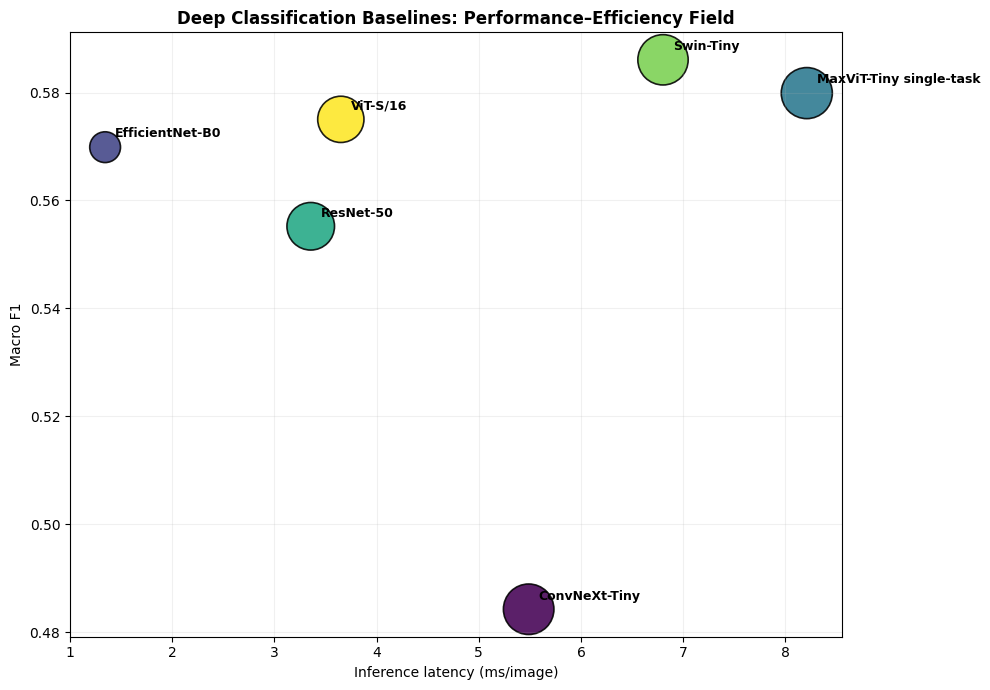

In [ ]:
CLASSIFICATION_BASELINE_EPOCHS = 12
CLASSIFICATION_BASELINE_PATIENCE = 3

if not RUN_HEAVY_Q1_SUITE:

    print(
        "Skipped heavy Q1 classification baselines. "
        "Set RUN_HEAVY_Q1_SUITE=True when GPU quota is available."
    )

else:

    # ========================================================
    # STAGE 33 — CHECKPOINT-SAFE CLASSIFICATION BASELINES
    # ========================================================

    CLASSIFICATION_BASELINES = {
        "ResNet-50":
            "resnet50",

        "EfficientNet-B0":
            "efficientnet_b0",

        "ConvNeXt-Tiny":
            "convnext_tiny",

        "Swin-Tiny":
            "swin_tiny_patch4_window7_224",

        "ViT-S/16":
            "vit_small_patch16_224",

        "MaxViT-Tiny single-task":
            MODEL_NAME,
    }


    def create_timm_classifier(
        model_name
    ):

        attempts = [
            {
                "pretrained":
                    True,

                "num_classes":
                    len(
                        HK_CLASSES
                    ),

                "img_size":
                    IMG_SIZE,
            },
            {
                "pretrained":
                    True,

                "num_classes":
                    len(
                        HK_CLASSES
                    ),
            },
        ]


        last_error = None


        for kwargs in attempts:

            try:

                return timm.create_model(
                    model_name,
                    **kwargs
                )

            except Exception as e:

                last_error = e


        raise RuntimeError(
            f"Could not create baseline {model_name}"
        ) from last_error


    def fit_cls_baseline(
        display_name,
        model_name,
        seed
    ):

        safe = (
            display_name
            .lower()
            .replace(
                " ",
                "_"
            )
            .replace(
                "/",
                "_"
            )
        )


        out_dir = (
            EXPERIMENTS
            /
            "classification_baselines"
            /
            safe
            /
            f"seed_{seed}"
        )


        out_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        metric_path = (
            out_dir
            /
            "metrics.json"
        )

        pred_path = (
            out_dir
            /
            "predictions.npz"
        )

        best_path = (
            out_dir
            /
            "best.pt"
        )

        resume_path = (
            out_dir
            /
            "resume.pt"
        )


        if (
            metric_path.exists()
            and
            pred_path.exists()
        ):

            return json.loads(
                metric_path.read_text()
            )


        seed_everything(
            seed
        )


        m = create_timm_classifier(
            model_name
        ).to(
            DEVICE
        )


        criterion = nn.CrossEntropyLoss(
            weight=Q1_CLASS_WEIGHTS,
            label_smoothing=0.05
        )


        opt = torch.optim.AdamW(
            m.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY
        )


        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt,
            T_max=CLASSIFICATION_BASELINE_EPOCHS,
            eta_min=LR
            *
            0.02
        )


        amp = torch.amp.GradScaler(
            "cuda",
            enabled=DEVICE.type
            ==
            "cuda"
        )


        start_epoch = 0

        best_f1 = -np.inf

        bad = 0


        if resume_path.exists():

            state = torch.load(
                resume_path,
                map_location=DEVICE,
                weights_only=False
            )


            m.load_state_dict(
                state[
                    "model"
                ]
            )


            opt.load_state_dict(
                state[
                    "optimizer"
                ]
            )


            sched.load_state_dict(
                state[
                    "scheduler"
                ]
            )


            amp.load_state_dict(
                state[
                    "scaler"
                ]
            )


            start_epoch = int(
                state[
                    "epoch"
                ]
            ) + 1


            best_f1 = float(
                state.get(
                    "best_f1",
                    -np.inf
                )
            )


            bad = int(
                state.get(
                    "bad",
                    0
                )
            )


            print(
                f"✓ Resuming {display_name} seed {seed} "
                f"from epoch {start_epoch + 1}"
            )


        for epoch in range(
            start_epoch,
            CLASSIFICATION_BASELINE_EPOCHS
        ):

            m.train()


            for x, y, _ in tqdm(
                cls_train_loader,
                desc=(
                    f"{display_name} "
                    f"seed={seed} "
                    f"epoch={epoch + 1}"
                ),
                leave=False
            ):

                x = x.to(
                    DEVICE,
                    non_blocking=True
                )

                y = y.to(
                    DEVICE,
                    non_blocking=True
                )


                opt.zero_grad(
                    set_to_none=True
                )


                with torch.amp.autocast(
                    "cuda",
                    enabled=DEVICE.type
                    ==
                    "cuda"
                ):

                    logits = m(
                        x
                    )


                    loss = criterion(
                        logits,
                        y
                    )


                amp.scale(
                    loss
                ).backward()


                amp.unscale_(
                    opt
                )


                torch.nn.utils.clip_grad_norm_(
                    m.parameters(),
                    1.0
                )


                amp.step(
                    opt
                )

                amp.update()


            sched.step()


            vy, vp, _, _, _ = q1_predict_cls(
                m,
                cls_val_loader,
                plain=True
            )


            vf1 = f1_score(
                vy,
                vp,
                average="macro",
                zero_division=0
            )


            improved = (
                vf1
                >
                best_f1
                +
                1e-4
            )


            if improved:

                best_f1 = float(
                    vf1
                )

                bad = 0


                atomic_torch_save(
                    {
                        "model":
                            m.state_dict(),

                        "epoch":
                            int(
                                epoch
                            ),

                        "best_f1":
                            float(
                                best_f1
                            ),
                    },
                    best_path
                )


            else:

                bad += 1


            atomic_torch_save(
                {
                    "model":
                        m.state_dict(),

                    "optimizer":
                        opt.state_dict(),

                    "scheduler":
                        sched.state_dict(),

                    "scaler":
                        amp.state_dict(),

                    "epoch":
                        int(
                            epoch
                        ),

                    "best_f1":
                        float(
                            best_f1
                        ),

                    "bad":
                        int(
                            bad
                        ),
                },
                resume_path
            )


            if (
                bad
                >=
                CLASSIFICATION_BASELINE_PATIENCE
            ):

                break


        if not best_path.exists():

            raise RuntimeError(
                f"No best checkpoint produced for {display_name}"
            )


        best_state = torch.load(
            best_path,
            map_location=DEVICE,
            weights_only=False
        )


        m.load_state_dict(
            best_state[
                "model"
            ]
        )


        y, pred, prob, names, lat = q1_predict_cls(
            m,
            cls_test_loader,
            plain=True
        )


        metrics = classification_metrics(
            y,
            pred,
            prob
        )


        ey, ep, eprob, _, _ = q1_predict_cls(
            m,
            external_loader,
            plain=True
        )


        ext_metrics = classification_metrics(
            ey,
            ep,
            eprob,
            labels=sorted(
                gv_mapped.hk_label.unique().tolist()
            )
        )


        row = {
            "method":
                display_name,

            "seed":
                int(
                    seed
                ),

            "macro_f1":
                float(
                    metrics[
                        "macro_f1"
                    ]
                ),

            "accuracy":
                float(
                    metrics[
                        "accuracy"
                    ]
                ),

            "mcc":
                float(
                    metrics[
                        "mcc"
                    ]
                ),

            "ece":
                float(
                    metrics[
                        "ece"
                    ]
                ),

            "brier":
                float(
                    metrics[
                        "brier_multiclass"
                    ]
                ),

            "external_macro_f1":
                float(
                    ext_metrics[
                        "macro_f1"
                    ]
                ),

            "latency_ms":
                float(
                    lat.mean()
                    *
                    1000
                ),

            "parameters_m":
                float(
                    sum(
                        p.numel()
                        for p
                        in m.parameters()
                    )
                    /
                    1e6
                ),
        }


        metric_path.write_text(
            json.dumps(
                row,
                indent=2
            )
        )


        np.savez_compressed(
            pred_path,
            y=y,
            pred=pred,
            prob=prob,
            names=np.asarray(
                names
            )
        )


        if resume_path.exists():

            resume_path.unlink()


        del m

        gc.collect()


        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()


        return row


    baseline_seeds = (
        Q1_SEEDS
        if RUN_FULL_Q1_SUITE
        else [
            Q1_SEEDS[
                0
            ]
        ]
    )


    classification_baseline_rows = []


    for display_name, model_name in CLASSIFICATION_BASELINES.items():

        for seed in baseline_seeds:

            print(
                f"Classification baseline: "
                f"{display_name} | seed={seed}"
            )


            classification_baseline_rows.append(
                fit_cls_baseline(
                    display_name,
                    model_name,
                    seed
                )
            )


    classification_baselines_df = pd.DataFrame(
        classification_baseline_rows
    )


    classification_baselines_df.to_csv(
        RESULTS
        /
        "classification_baseline_runs.csv",
        index=False
    )


    classification_baseline_summary = (
        classification_baselines_df
        .groupby(
            "method"
        )
        .agg(
            macro_f1_mean=(
                "macro_f1",
                "mean"
            ),
            macro_f1_std=(
                "macro_f1",
                "std"
            ),
            accuracy_mean=(
                "accuracy",
                "mean"
            ),
            external_f1_mean=(
                "external_macro_f1",
                "mean"
            ),
            ece_mean=(
                "ece",
                "mean"
            ),
            latency_ms=(
                "latency_ms",
                "mean"
            ),
            parameters_m=(
                "parameters_m",
                "mean"
            ),
        )
    )


    display(
        classification_baseline_summary
    )


    classification_baseline_summary.to_csv(
        RESULTS
        /
        "classification_baseline_summary.csv"
    )


    summary = (
        classification_baselines_df
        .groupby(
            "method"
        )
        .mean(
            numeric_only=True
        )
    )


    fig, ax = plt.subplots(
        figsize=(
            10,
            7
        )
    )


    x = summary[
        "latency_ms"
    ].values

    y = summary[
        "macro_f1"
    ].values


    sizes = (
        350
        +
        summary[
            "parameters_m"
        ].values
        *
        35
    )


    colors = np.linspace(
        0.14,
        0.88,
        len(
            summary
        )
    )


    ax.scatter(
        x,
        y,
        s=sizes,
        c=colors,
        cmap="viridis",
        edgecolors="black",
        linewidths=1.2,
        alpha=0.88
    )


    for i, method in enumerate(
        summary.index
    ):

        ax.annotate(
            method,
            (
                x[
                    i
                ],
                y[
                    i
                ]
            ),
            xytext=(
                7,
                7
            ),
            textcoords="offset points",
            fontsize=9,
            weight="bold"
        )


    ax.set_xlabel(
        "Inference latency (ms/image)"
    )


    ax.set_ylabel(
        "Macro F1"
    )


    ax.set_title(
        "Deep Classification Baselines: Performance–Efficiency Field",
        weight="bold"
    )


    ax.grid(
        alpha=0.18
    )


    plt.tight_layout()


    savefig(
        "33_classification_baseline_bubbles"
    )


    plt.show()

## Stage 34 — Five-Seed Segmentation Baselines

Segmentation baseline: U-Net | seed=42
Segmentation baseline: U-Net | seed=123
Segmentation baseline: U-Net | seed=2024
Segmentation baseline: U-Net | seed=3407
Segmentation baseline: U-Net | seed=8192
Segmentation baseline: U-Net++ | seed=42
Segmentation baseline: U-Net++ | seed=123
Segmentation baseline: U-Net++ | seed=2024
Segmentation baseline: U-Net++ | seed=3407
Segmentation baseline: U-Net++ | seed=8192
Segmentation baseline: DeepLabV3+ | seed=42
Segmentation baseline: DeepLabV3+ | seed=123
Segmentation baseline: DeepLabV3+ | seed=2024
Segmentation baseline: DeepLabV3+ | seed=3407
Segmentation baseline: DeepLabV3+ | seed=8192
Segmentation baseline: MAnet | seed=42
Segmentation baseline: MAnet | seed=123
Segmentation baseline: MAnet | seed=2024
Segmentation baseline: MAnet | seed=3407
Segmentation baseline: MAnet | seed=8192
Segmentation baseline: FPN | seed=42
Segmentation baseline: FPN | seed=123
Segmentation baseline: FPN | seed=2024
Segmentation baseline: FPN | seed=3407
Segm

,dice_mean,dice_std,iou_mean,boundary_f1_mean,latency_ms,parameters_m
method,,,,,,
DeepLabV3+,0.874669,0.003895,0.806939,0.624961,7.039883,26.677585
FPN,0.866591,0.005367,0.796495,0.587535,5.418455,23.155393
MAnet,0.869420,0.006682,0.803294,0.659412,6.244862,31.783633
U-Net,0.865393,0.015845,0.795471,0.627897,6.032805,24.436369
U-Net++,0.871465,0.003368,0.805301,0.662767,10.475914,26.078609


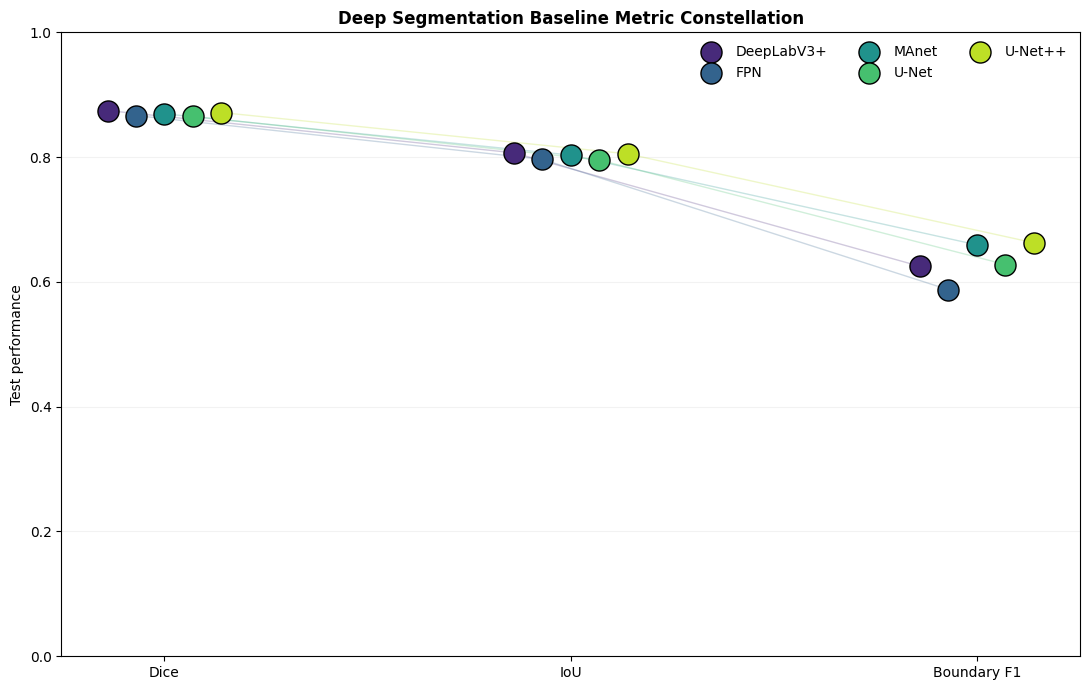

In [ ]:
SEGMENTATION_BASELINE_EPOCHS = 12
SEGMENTATION_BASELINE_PATIENCE = 3

if not RUN_HEAVY_Q1_SUITE:

    print(
        "Skipped heavy Q1 segmentation baselines. "
        "Set RUN_HEAVY_Q1_SUITE=True when GPU quota is available."
    )

else:

    # ========================================================
    # STAGE 34 — CHECKPOINT-SAFE SEGMENTATION BASELINES
    # ========================================================

    SEGMENTATION_BASELINES = {
        "U-Net":
            lambda:
                smp.Unet(
                    encoder_name="resnet34",
                    encoder_weights="imagenet",
                    in_channels=3,
                    classes=1
                ),

        "U-Net++":
            lambda:
                smp.UnetPlusPlus(
                    encoder_name="resnet34",
                    encoder_weights="imagenet",
                    in_channels=3,
                    classes=1
                ),

        "DeepLabV3+":
            lambda:
                smp.DeepLabV3Plus(
                    encoder_name="resnet50",
                    encoder_weights="imagenet",
                    in_channels=3,
                    classes=1
                ),

        "MAnet":
            lambda:
                smp.MAnet(
                    encoder_name="resnet34",
                    encoder_weights="imagenet",
                    in_channels=3,
                    classes=1
                ),

        "FPN":
            lambda:
                smp.FPN(
                    encoder_name="resnet34",
                    encoder_weights="imagenet",
                    in_channels=3,
                    classes=1
                ),
    }


    def fit_seg_baseline(
        display_name,
        builder,
        seed
    ):

        safe = (
            display_name
            .lower()
            .replace(
                " ",
                "_"
            )
            .replace(
                "+",
                "plus"
            )
        )


        out_dir = (
            EXPERIMENTS
            /
            "segmentation_baselines"
            /
            safe
            /
            f"seed_{seed}"
        )


        out_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        metric_path = (
            out_dir
            /
            "metrics.json"
        )

        per_image_path = (
            out_dir
            /
            "per_image.csv"
        )

        best_path = (
            out_dir
            /
            "best.pt"
        )

        resume_path = (
            out_dir
            /
            "resume.pt"
        )


        if (
            metric_path.exists()
            and
            per_image_path.exists()
        ):

            return json.loads(
                metric_path.read_text()
            )


        seed_everything(
            seed
        )


        m = builder().to(
            DEVICE
        )


        opt = torch.optim.AdamW(
            m.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY
        )


        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt,
            T_max=SEGMENTATION_BASELINE_EPOCHS,
            eta_min=LR
            *
            0.02
        )


        amp = torch.amp.GradScaler(
            "cuda",
            enabled=DEVICE.type
            ==
            "cuda"
        )


        start_epoch = 0

        best_dice = -np.inf

        bad = 0


        if resume_path.exists():

            state = torch.load(
                resume_path,
                map_location=DEVICE,
                weights_only=False
            )


            m.load_state_dict(
                state[
                    "model"
                ]
            )


            opt.load_state_dict(
                state[
                    "optimizer"
                ]
            )


            sched.load_state_dict(
                state[
                    "scheduler"
                ]
            )


            amp.load_state_dict(
                state[
                    "scaler"
                ]
            )


            start_epoch = int(
                state[
                    "epoch"
                ]
            ) + 1


            best_dice = float(
                state.get(
                    "best_dice",
                    -np.inf
                )
            )


            bad = int(
                state.get(
                    "bad",
                    0
                )
            )


            print(
                f"✓ Resuming {display_name} seed {seed} "
                f"from epoch {start_epoch + 1}"
            )


        for epoch in range(
            start_epoch,
            SEGMENTATION_BASELINE_EPOCHS
        ):

            m.train()


            for x, y, _ in tqdm(
                seg_train_loader,
                desc=(
                    f"{display_name} "
                    f"seed={seed} "
                    f"epoch={epoch + 1}"
                ),
                leave=False
            ):

                x = x.to(
                    DEVICE,
                    non_blocking=True
                )

                y = y.to(
                    DEVICE,
                    non_blocking=True
                )


                opt.zero_grad(
                    set_to_none=True
                )


                with torch.amp.autocast(
                    "cuda",
                    enabled=DEVICE.type
                    ==
                    "cuda"
                ):

                    logits = m(
                        x
                    )


                    loss = segmentation_loss(
                        logits,
                        y
                    )


                amp.scale(
                    loss
                ).backward()


                amp.unscale_(
                    opt
                )


                torch.nn.utils.clip_grad_norm_(
                    m.parameters(),
                    1.0
                )


                amp.step(
                    opt
                )

                amp.update()


            sched.step()


            val_df = q1_predict_seg(
                m,
                seg_val_loader,
                plain=True
            )


            vdice = float(
                val_df[
                    "dice"
                ].mean()
            )


            improved = (
                vdice
                >
                best_dice
                +
                1e-4
            )


            if improved:

                best_dice = float(
                    vdice
                )

                bad = 0


                atomic_torch_save(
                    {
                        "model":
                            m.state_dict(),

                        "epoch":
                            int(
                                epoch
                            ),

                        "best_dice":
                            float(
                                best_dice
                            ),
                    },
                    best_path
                )


            else:

                bad += 1


            atomic_torch_save(
                {
                    "model":
                        m.state_dict(),

                    "optimizer":
                        opt.state_dict(),

                    "scheduler":
                        sched.state_dict(),

                    "scaler":
                        amp.state_dict(),

                    "epoch":
                        int(
                            epoch
                        ),

                    "best_dice":
                        float(
                            best_dice
                        ),

                    "bad":
                        int(
                            bad
                        ),
                },
                resume_path
            )


            if (
                bad
                >=
                SEGMENTATION_BASELINE_PATIENCE
            ):

                break


        if not best_path.exists():

            raise RuntimeError(
                f"No best checkpoint produced for {display_name}"
            )


        best_state = torch.load(
            best_path,
            map_location=DEVICE,
            weights_only=False
        )


        m.load_state_dict(
            best_state[
                "model"
            ]
        )


        test_df = q1_predict_seg(
            m,
            seg_test_loader,
            plain=True
        )


        row = {
            "method":
                display_name,

            "seed":
                int(
                    seed
                ),

            "dice":
                float(
                    test_df[
                        "dice"
                    ].mean()
                ),

            "iou":
                float(
                    test_df[
                        "iou"
                    ].mean()
                ),

            "boundary_f1":
                float(
                    test_df[
                        "boundary_f1"
                    ].mean()
                ),

            "latency_ms":
                float(
                    test_df[
                        "latency_ms"
                    ].mean()
                ),

            "parameters_m":
                float(
                    sum(
                        p.numel()
                        for p
                        in m.parameters()
                    )
                    /
                    1e6
                ),
        }


        metric_path.write_text(
            json.dumps(
                row,
                indent=2
            )
        )


        test_df.to_csv(
            per_image_path,
            index=False
        )


        if resume_path.exists():

            resume_path.unlink()


        del m

        gc.collect()


        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()


        return row


    segmentation_baseline_rows = []


    for display_name, builder in SEGMENTATION_BASELINES.items():

        for seed in baseline_seeds:

            print(
                f"Segmentation baseline: "
                f"{display_name} | seed={seed}"
            )


            segmentation_baseline_rows.append(
                fit_seg_baseline(
                    display_name,
                    builder,
                    seed
                )
            )


    segmentation_baselines_df = pd.DataFrame(
        segmentation_baseline_rows
    )


    segmentation_baselines_df.to_csv(
        RESULTS
        /
        "segmentation_baseline_runs.csv",
        index=False
    )


    segmentation_baseline_summary = (
        segmentation_baselines_df
        .groupby(
            "method"
        )
        .agg(
            dice_mean=(
                "dice",
                "mean"
            ),
            dice_std=(
                "dice",
                "std"
            ),
            iou_mean=(
                "iou",
                "mean"
            ),
            boundary_f1_mean=(
                "boundary_f1",
                "mean"
            ),
            latency_ms=(
                "latency_ms",
                "mean"
            ),
            parameters_m=(
                "parameters_m",
                "mean"
            ),
        )
    )


    display(
        segmentation_baseline_summary
    )


    segmentation_baseline_summary.to_csv(
        RESULTS
        /
        "segmentation_baseline_summary.csv"
    )


    means = (
        segmentation_baselines_df
        .groupby(
            "method"
        )[
            [
                "dice",
                "iou",
                "boundary_f1",
            ]
        ]
        .mean()
    )


    fig, ax = plt.subplots(
        figsize=(
            11,
            7
        )
    )


    for mi, method in enumerate(
        means.index
    ):

        vals = means.loc[
            method
        ].values


        jitter = (
            mi
            -
            (
                len(
                    means
                )
                -
                1
            )
            /
            2
        ) * 0.07


        xs = (
            np.arange(
                3
            )
            +
            jitter
        )


        color = mpl.colormaps[
            "viridis"
        ](
            0.12
            +
            0.78
            *
            mi
            /
            max(
                1,
                len(
                    means
                )
                -
                1
            )
        )


        ax.scatter(
            xs,
            vals,
            s=230,
            color=color,
            edgecolors="black",
            linewidths=1.0,
            label=method,
            zorder=3
        )


        ax.plot(
            xs,
            vals,
            color=color,
            alpha=0.25,
            linewidth=1.0
        )


    ax.set_xticks(
        range(
            3
        )
    )


    ax.set_xticklabels(
        [
            "Dice",
            "IoU",
            "Boundary F1",
        ]
    )


    ax.set_ylim(
        0,
        1
    )


    ax.set_ylabel(
        "Test performance"
    )


    ax.set_title(
        "Deep Segmentation Baseline Metric Constellation",
        weight="bold"
    )


    ax.legend(
        frameon=False,
        ncol=3
    )


    ax.grid(
        axis="y",
        alpha=0.16
    )


    plt.tight_layout()


    savefig(
        "34_segmentation_baseline_constellation"
    )


    plt.show()

## Stage 35 — Five-Seed MTG-MaxViTX Reproducibility

Uses the same corrected one-pass multi-task schedule as the revised ablation protocol so the proposed-model statistics are internally consistent.


In [ ]:

if not RUN_HEAVY_Q1_SUITE:

    print(
        "Skipped five-seed proposed-model runs. "
        "Set RUN_HEAVY_Q1_SUITE=True."
    )

else:

    # ========================================================
    # STAGE 35 — FIVE-SEED PROPOSED MODEL
    # Corrected one-pass protocol
    # ========================================================

    PROPOSED_FIVE_RUN_EPOCHS = 12
    PROPOSED_FIVE_RUN_PATIENCE = 3

    five_run_rows = []

    for seed in Q1_SEEDS:

        print()
        print(
            f"Proposed MTG-MaxViTX "
            f"| corrected one-pass "
            f"| seed={seed}"
        )

        row = q1_fit_multitask(
            experiment_name="MTG-MaxViTX",
            seed=seed,
            use_multiscale_context=True,
            use_semantic_gating=True,
            use_boundary_head=True,
            lambda_consistency=LAMBDA_CONSISTENCY,
            lambda_boundary=LAMBDA_BOUNDARY,
            multitask=True,
            output_group=(
                "five_run_full_mtg_maxvitx_balanced_v2"
            ),
            max_epochs=PROPOSED_FIVE_RUN_EPOCHS,
            patience=PROPOSED_FIVE_RUN_PATIENCE,
        )

        five_run_rows.append(
            row
        )

    five_run_df = pd.DataFrame(
        five_run_rows
    )

    five_run_df.to_csv(
        RESULTS
        / "mtg_maxvitx_five_run_results_balanced_v2.csv",
        index=False
    )

    # Canonical alias for downstream cells.
    five_run_df.to_csv(
        RESULTS
        / "mtg_maxvitx_five_run_results.csv",
        index=False
    )

    five_run_summary = (
        five_run_df[
            [
                "macro_f1",
                "accuracy",
                "mcc",
                "ece",
                "dice",
                "iou",
                "boundary_f1",
                "external_macro_f1",
            ]
        ]
        .agg(
            ["mean", "std"]
        )
        .T
    )

    five_run_summary.to_csv(
        RESULTS
        / "mtg_maxvitx_five_run_mean_std_balanced_v2.csv"
    )

    five_run_summary.to_csv(
        RESULTS
        / "mtg_maxvitx_five_run_mean_std.csv"
    )

    display(
        five_run_df
    )

    display(
        five_run_summary
    )

    print(
        "✓ Five-seed proposed-model runs complete/resumed"
    )



Proposed MTG-MaxViTX | corrected one-pass | seed=42
✓ COMPLETE — skipping MTG-MaxViTX | seed=42

Proposed MTG-MaxViTX | corrected one-pass | seed=123
✓ COMPLETE — skipping MTG-MaxViTX | seed=123

Proposed MTG-MaxViTX | corrected one-pass | seed=2024
✓ COMPLETE — skipping MTG-MaxViTX | seed=2024

Proposed MTG-MaxViTX | corrected one-pass | seed=3407
✓ COMPLETE — skipping MTG-MaxViTX | seed=3407

Proposed MTG-MaxViTX | corrected one-pass | seed=8192
✓ COMPLETE — skipping MTG-MaxViTX | seed=8192


,experiment,protocol,seed,max_epochs,selected_best_epoch,macro_f1,accuracy,mcc,ece,dice,iou,boundary_f1,external_macro_f1,classification_latency_ms,segmentation_latency_ms,parameters_m,cls_batches_per_epoch,seg_batches_per_epoch,segmentation_passes_per_epoch
0,MTG-MaxViTX,balanced_one_pass_v2,42,12,12,0.586061,0.887683,0.878349,0.377080,0.885054,0.820959,0.685537,0.831041,8.315174,13.519006,32.562705,400,75,1.0
1,MTG-MaxViTX,balanced_one_pass_v2,123,12,10,0.577865,0.887211,0.877735,0.369974,0.889719,0.826550,0.689745,0.768859,8.405298,10.427291,32.562705,400,75,1.0
2,MTG-MaxViTX,balanced_one_pass_v2,2024,12,12,0.595263,0.902312,0.894214,0.390624,0.887921,0.824450,0.679082,0.834360,8.429398,11.338620,32.562705,400,75,1.0
3,MTG-MaxViTX,balanced_one_pass_v2,3407,12,8,0.577702,0.882492,0.873035,0.367758,0.864620,0.793389,0.639772,0.742587,8.445725,10.498608,32.562705,400,75,1.0
4,MTG-MaxViTX,balanced_one_pass_v2,8192,12,12,0.589477,0.899009,0.890589,0.396407,0.875448,0.808832,0.668310,0.829130,8.421147,10.516111,32.562705,400,75,1.0


,mean,std
macro_f1,0.585273,0.007588
accuracy,0.891741,0.008472
mcc,0.882785,0.009107
ece,0.380369,0.012652
dice,0.880552,0.010470
iou,0.814836,0.013813
boundary_f1,0.672489,0.019996
external_macro_f1,0.801195,0.042578


✓ Five-seed proposed-model runs complete/resumed


## Stage 36 — Statistical Significance

Performs paired five-seed Wilcoxon tests, exact McNemar testing on matched classification predictions, paired per-image Dice testing, bootstrap confidence intervals for differences, and Holm correction for multiple comparisons.


In [ ]:

# ============================================================
# STAGE 36 — STATISTICAL SIGNIFICANCE
# ============================================================

from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests


def paired_bootstrap_difference(
    a,
    b,
    n_boot=5000,
    seed=SEED
):
    a = np.asarray(
        a,
        dtype=float
    )

    b = np.asarray(
        b,
        dtype=float
    )

    mask = (
        np.isfinite(a)
        &
        np.isfinite(b)
    )

    a = a[mask]
    b = b[mask]

    if len(a) != len(b):
        raise ValueError(
            "Paired arrays must have identical length."
        )

    if len(a) == 0:
        return {
            "mean_difference": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    diff = a - b

    rng = np.random.default_rng(
        seed
    )

    boot = np.empty(
        n_boot,
        dtype=float
    )

    for i in range(
        n_boot
    ):
        idx = rng.integers(
            0,
            len(diff),
            len(diff)
        )

        boot[i] = diff[
            idx
        ].mean()

    return {
        "mean_difference":
            float(
                diff.mean()
            ),
        "ci_low":
            float(
                np.percentile(
                    boot,
                    2.5
                )
            ),
        "ci_high":
            float(
                np.percentile(
                    boot,
                    97.5
                )
            ),
    }


def safe_wilcoxon_greater(
    a,
    b
):
    a = np.asarray(
        a,
        dtype=float
    )

    b = np.asarray(
        b,
        dtype=float
    )

    mask = (
        np.isfinite(a)
        &
        np.isfinite(b)
    )

    a = a[mask]
    b = b[mask]

    if len(a) < 2:
        return np.nan, np.nan

    if np.allclose(
        a,
        b
    ):
        return 0.0, 1.0

    try:
        result = wilcoxon(
            a,
            b,
            alternative="greater",
            zero_method="wilcox",
            method="auto"
        )

        return (
            float(result.statistic),
            float(result.pvalue),
        )

    except Exception as e:
        print(
            "Wilcoxon warning:",
            e
        )

        return np.nan, np.nan


# ------------------------------------------------------------
# RELOAD ALL INPUTS FROM DRIVE
# ------------------------------------------------------------

five_run_df = pd.read_csv(
    RESULTS
    / "mtg_maxvitx_five_run_results.csv"
)

classification_baselines_df = pd.read_csv(
    RESULTS
    / "classification_baseline_runs.csv"
)

segmentation_baselines_df = pd.read_csv(
    RESULTS
    / "segmentation_baseline_runs.csv"
)


# ------------------------------------------------------------
# STRONGEST BASELINES BY FIVE-SEED MEAN
# ------------------------------------------------------------

strongest_cls = (
    classification_baselines_df
    .groupby("method")[
        "macro_f1"
    ]
    .mean()
    .idxmax()
)

strongest_seg = (
    segmentation_baselines_df
    .groupby("method")[
        "dice"
    ]
    .mean()
    .idxmax()
)


print(
    "Strongest classification baseline:",
    strongest_cls
)

print(
    "Strongest segmentation baseline:",
    strongest_seg
)


# ------------------------------------------------------------
# SEED-LEVEL PAIRED TESTS
# ------------------------------------------------------------

prop_cls_seed = (
    five_run_df
    .set_index("seed")[
        "macro_f1"
    ]
    .reindex(
        Q1_SEEDS
    )
)

base_cls_seed = (
    classification_baselines_df[
        classification_baselines_df[
            "method"
        ].eq(
            strongest_cls
        )
    ]
    .set_index("seed")[
        "macro_f1"
    ]
    .reindex(
        Q1_SEEDS
    )
)

cls_w_stat, cls_w_p = (
    safe_wilcoxon_greater(
        prop_cls_seed.values,
        base_cls_seed.values
    )
)


prop_seg_seed = (
    five_run_df
    .set_index("seed")[
        "dice"
    ]
    .reindex(
        Q1_SEEDS
    )
)

base_seg_seed = (
    segmentation_baselines_df[
        segmentation_baselines_df[
            "method"
        ].eq(
            strongest_seg
        )
    ]
    .set_index("seed")[
        "dice"
    ]
    .reindex(
        Q1_SEEDS
    )
)

seg_w_stat, seg_w_p = (
    safe_wilcoxon_greater(
        prop_seg_seed.values,
        base_seg_seed.values
    )
)


# ------------------------------------------------------------
# SEED-42 MCNEMAR CLASSIFICATION TEST
# ------------------------------------------------------------

seed0 = int(
    Q1_SEEDS[
        0
    ]
)

prop_pred_path = (
    EXPERIMENTS
    / "five_run_full_mtg_maxvitx_balanced_v2"
    / "mtg-maxvitx"
    / f"seed_{seed0}"
    / "classification_predictions.npz"
)

base_safe = (
    strongest_cls
    .lower()
    .replace(
        " ",
        "_"
    )
    .replace(
        "/",
        "_"
    )
)

base_pred_path = (
    EXPERIMENTS
    / "classification_baselines"
    / base_safe
    / f"seed_{seed0}"
    / "predictions.npz"
)

zp = np.load(
    prop_pred_path,
    allow_pickle=True
)

zb = np.load(
    base_pred_path,
    allow_pickle=True
)

# Match by filename if the arrays are not already aligned.
prop_names = np.asarray(
    zp["names"]
).astype(str)

base_names = np.asarray(
    zb["names"]
).astype(str)

prop_map = {
    name: (
        int(y),
        int(pred)
    )
    for name, y, pred
    in zip(
        prop_names,
        zp["y"],
        zp["pred"]
    )
}

base_map = {
    name: (
        int(y),
        int(pred)
    )
    for name, y, pred
    in zip(
        base_names,
        zb["y"],
        zb["pred"]
    )
}

common_names = sorted(
    set(
        prop_map
    )
    &
    set(
        base_map
    )
)

prop_correct = np.asarray([
    prop_map[n][1]
    ==
    prop_map[n][0]
    for n in common_names
])

base_correct = np.asarray([
    base_map[n][1]
    ==
    base_map[n][0]
    for n in common_names
])

mcn_table = [
    [
        int(
            np.sum(
                prop_correct
                &
                base_correct
            )
        ),
        int(
            np.sum(
                prop_correct
                &
                ~base_correct
            )
        ),
    ],
    [
        int(
            np.sum(
                ~prop_correct
                &
                base_correct
            )
        ),
        int(
            np.sum(
                ~prop_correct
                &
                ~base_correct
            )
        ),
    ],
]

mcn = mcnemar(
    mcn_table,
    exact=True
)


# ------------------------------------------------------------
# SEED-42 PAIRED SEGMENTATION TEST
# ------------------------------------------------------------

prop_seg_path = (
    EXPERIMENTS
    / "five_run_full_mtg_maxvitx_balanced_v2"
    / "mtg-maxvitx"
    / f"seed_{seed0}"
    / "segmentation_per_image.csv"
)

seg_safe = (
    strongest_seg
    .lower()
    .replace(
        " ",
        "_"
    )
    .replace(
        "+",
        "plus"
    )
)

base_seg_path = (
    EXPERIMENTS
    / "segmentation_baselines"
    / seg_safe
    / f"seed_{seed0}"
    / "per_image.csv"
)

prop_seg = pd.read_csv(
    prop_seg_path
)

base_seg = pd.read_csv(
    base_seg_path
)

paired_seg = (
    prop_seg[
        [
            "filename",
            "dice"
        ]
    ]
    .merge(
        base_seg[
            [
                "filename",
                "dice"
            ]
        ],
        on="filename",
        suffixes=(
            "_proposed",
            "_baseline"
        )
    )
)

seg_img_stat, seg_img_p = (
    safe_wilcoxon_greater(
        paired_seg[
            "dice_proposed"
        ].values,
        paired_seg[
            "dice_baseline"
        ].values
    )
)

seg_boot = (
    paired_bootstrap_difference(
        paired_seg[
            "dice_proposed"
        ].values,
        paired_seg[
            "dice_baseline"
        ].values,
        n_boot=5000,
        seed=SEED
    )
)


# ------------------------------------------------------------
# EFFECT MAGNITUDE FOR FIVE-SEED DIFFERENCES
# ------------------------------------------------------------

cls_boot = (
    paired_bootstrap_difference(
        prop_cls_seed.values,
        base_cls_seed.values,
        n_boot=5000,
        seed=SEED
    )
)

seg_seed_boot = (
    paired_bootstrap_difference(
        prop_seg_seed.values,
        base_seg_seed.values,
        n_boot=5000,
        seed=SEED
    )
)


# ------------------------------------------------------------
# BUILD SIGNIFICANCE TABLE
# ------------------------------------------------------------

significance_rows = [
    {
        "comparison":
            (
                "MTG-MaxViTX vs "
                f"{strongest_cls} "
                "— seed-level Macro F1"
            ),
        "test":
            "Wilcoxon signed-rank, one-sided",
        "n":
            int(
                np.sum(
                    np.isfinite(
                        prop_cls_seed.values
                    )
                    &
                    np.isfinite(
                        base_cls_seed.values
                    )
                )
            ),
        "statistic":
            cls_w_stat,
        "p_value":
            cls_w_p,
        "mean_difference":
            cls_boot[
                "mean_difference"
            ],
        "ci_low":
            cls_boot[
                "ci_low"
            ],
        "ci_high":
            cls_boot[
                "ci_high"
            ],
    },

    {
        "comparison":
            (
                "MTG-MaxViTX vs "
                f"{strongest_seg} "
                "— seed-level Dice"
            ),
        "test":
            "Wilcoxon signed-rank, one-sided",
        "n":
            int(
                np.sum(
                    np.isfinite(
                        prop_seg_seed.values
                    )
                    &
                    np.isfinite(
                        base_seg_seed.values
                    )
                )
            ),
        "statistic":
            seg_w_stat,
        "p_value":
            seg_w_p,
        "mean_difference":
            seg_seed_boot[
                "mean_difference"
            ],
        "ci_low":
            seg_seed_boot[
                "ci_low"
            ],
        "ci_high":
            seg_seed_boot[
                "ci_high"
            ],
    },

    {
        "comparison":
            (
                "MTG-MaxViTX vs "
                f"{strongest_cls} "
                f"— seed {seed0} correctness"
            ),
        "test":
            "Exact McNemar",
        "n":
            int(
                len(
                    common_names
                )
            ),
        "statistic":
            float(
                mcn.statistic
            ),
        "p_value":
            float(
                mcn.pvalue
            ),
        "mean_difference":
            float(
                prop_correct.mean()
                -
                base_correct.mean()
            ),
        "ci_low":
            np.nan,
        "ci_high":
            np.nan,
    },

    {
        "comparison":
            (
                "MTG-MaxViTX vs "
                f"{strongest_seg} "
                f"— seed {seed0} per-image Dice"
            ),
        "test":
            "Wilcoxon signed-rank, one-sided",
        "n":
            int(
                len(
                    paired_seg
                )
            ),
        "statistic":
            seg_img_stat,
        "p_value":
            seg_img_p,
        "mean_difference":
            seg_boot[
                "mean_difference"
            ],
        "ci_low":
            seg_boot[
                "ci_low"
            ],
        "ci_high":
            seg_boot[
                "ci_high"
            ],
    },
]

significance_df = pd.DataFrame(
    significance_rows
)

valid_p = (
    significance_df[
        "p_value"
    ]
    .notna()
)

if valid_p.any():

    reject, p_holm, _, _ = (
        multipletests(
            significance_df.loc[
                valid_p,
                "p_value"
            ].values,
            alpha=0.05,
            method="holm"
        )
    )

    significance_df[
        "p_holm"
    ] = np.nan

    significance_df[
        "reject_holm_0_05"
    ] = False

    significance_df.loc[
        valid_p,
        "p_holm"
    ] = p_holm

    significance_df.loc[
        valid_p,
        "reject_holm_0_05"
    ] = reject

else:

    significance_df[
        "p_holm"
    ] = np.nan

    significance_df[
        "reject_holm_0_05"
    ] = False


significance_df.to_csv(
    RESULTS
    / "q1_statistical_significance.csv",
    index=False
)

display(
    significance_df
)

print()
print(
    "McNemar table:",
    mcn_table
)

print(
    "✓ Statistical significance stage complete"
)


Strongest classification baseline: Swin-Tiny
Strongest segmentation baseline: DeepLabV3+


,comparison,test,n,statistic,p_value,mean_difference,ci_low,ci_high,p_holm,reject_holm_0_05
0,MTG-MaxViTX vs Swin-Tiny — seed-level Macro F1,"Wilcoxon signed-rank, one-sided",5,5.0,0.781250,-0.000796,-0.003348,0.001756,0.781250,False
1,MTG-MaxViTX vs DeepLabV3+ — seed-level Dice,"Wilcoxon signed-rank, one-sided",5,13.0,0.093750,0.005883,-0.000458,0.011454,0.281250,False
2,MTG-MaxViTX vs Swin-Tiny — seed 42 correctness,Exact McNemar,2119,88.0,0.103639,0.011326,NaN,NaN,0.281250,False
3,MTG-MaxViTX vs DeepLabV3+ — seed 42 per-image ...,"Wilcoxon signed-rank, one-sided",203,11863.0,0.035783,0.006583,-0.012026,0.025715,0.143133,False



McNemar table: [[1769, 112], [88, 150]]
✓ Statistical significance stage complete


## Final Comparison — Proposed, Baselines, Ablation, and Significance

Reloads all saved experiment outputs from Drive, builds the final five-seed comparison tables, and exports the complete Q1 comparison workbook.


PROPOSED METHOD — FIVE-SEED SUMMARY


,method,task,runs,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,mcc_mean,ece_mean,dice_mean,dice_std,iou_mean,boundary_f1_mean,external_macro_f1_mean,parameters_m
0,MTG-MaxViTX,Joint,5,0.891741,0.008472,0.585273,0.007588,0.882785,0.380369,0.880552,0.01047,0.814836,0.672489,0.801195,32.562705



CLASSIFICATION BASELINE COMPARISON


,method,task,runs,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,mcc_mean,ece_mean,external_macro_f1_mean,latency_ms,parameters_m
4,Swin-Tiny,Classification,5,0.884285,0.008582,0.586070,0.007209,0.875021,0.382080,0.812800,6.803041,27.537041
2,MaxViT-Tiny single-task,Classification,5,0.879471,0.027748,0.579895,0.016698,0.869604,0.391375,0.771432,8.210254,28.647695
5,ViT-S/16,Classification,5,0.872487,0.012281,0.575032,0.008339,0.862083,0.386982,0.672539,3.650110,21.697559
1,EfficientNet-B0,Classification,5,0.836338,0.015062,0.569874,0.009707,0.825439,0.349922,0.688942,1.343319,4.037011
3,ResNet-50,Classification,5,0.812836,0.012533,0.555212,0.011424,0.800343,0.333587,0.723343,3.355512,23.555159
0,ConvNeXt-Tiny,Classification,5,0.723077,0.065373,0.484222,0.046874,0.705331,0.306481,0.394964,5.488489,27.837815



SEGMENTATION BASELINE COMPARISON


...


CORRECTED ABLATION STUDY


,experiment,protocol,seed,max_epochs,selected_best_epoch,macro_f1,accuracy,mcc,ece,dice,iou,boundary_f1,external_macro_f1,classification_latency_ms,segmentation_latency_ms,parameters_m,cls_batches_per_epoch,seg_batches_per_epoch,segmentation_passes_per_epoch
4,w/o Boundary Head,balanced_one_pass_v2,42,12.0,12.0,0.607005,0.893346,0.884414,0.383558,0.886766,0.826160,0.697157,0.833772,7.770005,9.649121,32.562705,400.0,75.0,1.0
0,Full MTG-MaxViTX,balanced_one_pass_v2,42,12.0,11.0,0.603040,0.899009,0.890530,0.387921,0.889452,0.826477,0.686680,0.851698,7.704487,12.380614,32.562705,400.0,75.0,1.0
1,w/o Context Fusion,balanced_one_pass_v2,42,12.0,12.0,0.584275,0.895706,0.886979,0.385908,0.880658,0.818729,0.684958,0.853467,7.762547,11.166567,32.562705,400.0,75.0,1.0
5,Separate Single-Task Models,independent_one_pass,42,NaN,NaN,0.583744,0.892402,0.883590,0.380438,0.901593,0.844434,0.712833,0.759673,7.272365,11.786091,65.125410,NaN,NaN,NaN
3,w/o Consistency Loss,balanced_one_pass_v2,42,12.0,12.0,0.582691,0.893346,0.884393,0.391442,0.889606,0.829817,0.693544,0.850593,7.735105,9.624415,32.562705,400.0,75.0,1.0
2,w/o Semantic Gating,balanced_one_pass_v2,42,12.0,12.0,0.580358,0.888627,0.879459,0.385653,0.889827,0.828083,0.685224,0.808551,7.775399,10.218183,32.562705,400.0,75.0,1.0



STATISTICAL SIGNIFICANCE


,comparison,test,n,statistic,p_value,mean_difference,ci_low,ci_high,p_holm,reject_holm_0_05
0,MTG-MaxViTX vs Swin-Tiny — seed-level Macro F1,"Wilcoxon signed-rank, one-sided",5,5.0,0.781250,-0.000796,-0.003348,0.001756,0.781250,False
1,MTG-MaxViTX vs DeepLabV3+ — seed-level Dice,"Wilcoxon signed-rank, one-sided",5,13.0,0.093750,0.005883,-0.000458,0.011454,0.281250,False
2,MTG-MaxViTX vs Swin-Tiny — seed 42 correctness,Exact McNemar,2119,88.0,0.103639,0.011326,NaN,NaN,0.281250,False
3,MTG-MaxViTX vs DeepLabV3+ — seed 42 per-image ...,"Wilcoxon signed-rank, one-sided",203,11863.0,0.035783,0.006583,-0.012026,0.025715,0.143133,False



✓ Final comparison workbook:
/content/drive/MyDrive/MTG_MaxViTX/results/MTG_MaxViTX_Q1_FINAL_COMPARISON_v2.xlsx


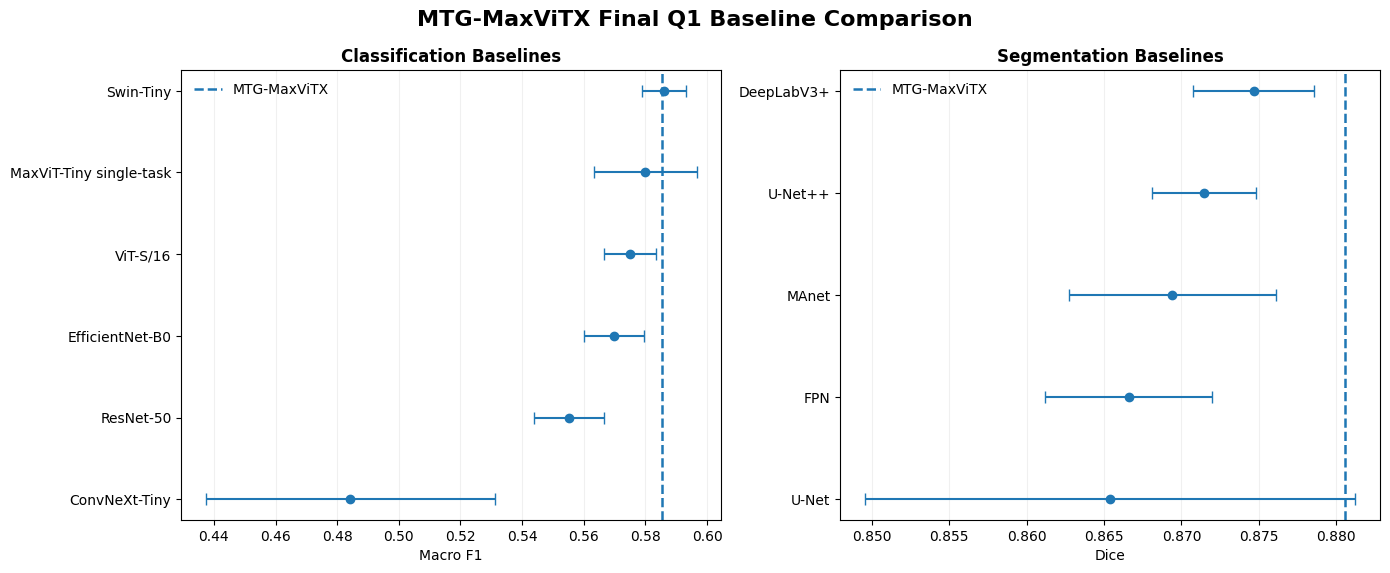

In [ ]:

# ============================================================
# FINAL COMPARISON — Q1 PUBLICATION TABLES
# ============================================================

ablation_path = (
    RESULTS
    / "q1_ablation_corrected_comparison.csv"
)

cls_baseline_path = (
    RESULTS
    / "classification_baseline_runs.csv"
)

seg_baseline_path = (
    RESULTS
    / "segmentation_baseline_runs.csv"
)

five_run_path = (
    RESULTS
    / "mtg_maxvitx_five_run_results.csv"
)

significance_path = (
    RESULTS
    / "q1_statistical_significance.csv"
)

required = [
    ablation_path,
    cls_baseline_path,
    seg_baseline_path,
    five_run_path,
    significance_path,
]

missing = [
    p
    for p in required
    if not p.exists()
]

if missing:

    raise RuntimeError(
        "Run the unfinished stages first. Missing:\n"
        +
        "\n".join(
            str(p)
            for p in missing
        )
    )


ablation_df = pd.read_csv(
    ablation_path
)

classification_baselines_df = pd.read_csv(
    cls_baseline_path
)

segmentation_baselines_df = pd.read_csv(
    seg_baseline_path
)

five_run_df = pd.read_csv(
    five_run_path
)

significance_df = pd.read_csv(
    significance_path
)


# ============================================================
# PROPOSED FIVE-SEED SUMMARY
# ============================================================

proposed = pd.DataFrame([
    {
        "method":
            "MTG-MaxViTX",
        "task":
            "Joint",
        "runs":
            len(
                five_run_df
            ),
        "accuracy_mean":
            five_run_df[
                "accuracy"
            ].mean(),
        "accuracy_std":
            five_run_df[
                "accuracy"
            ].std(
                ddof=1
            ),
        "macro_f1_mean":
            five_run_df[
                "macro_f1"
            ].mean(),
        "macro_f1_std":
            five_run_df[
                "macro_f1"
            ].std(
                ddof=1
            ),
        "mcc_mean":
            five_run_df[
                "mcc"
            ].mean(),
        "ece_mean":
            five_run_df[
                "ece"
            ].mean(),
        "dice_mean":
            five_run_df[
                "dice"
            ].mean(),
        "dice_std":
            five_run_df[
                "dice"
            ].std(
                ddof=1
            ),
        "iou_mean":
            five_run_df[
                "iou"
            ].mean(),
        "boundary_f1_mean":
            five_run_df[
                "boundary_f1"
            ].mean(),
        "external_macro_f1_mean":
            five_run_df[
                "external_macro_f1"
            ].mean(),
        "parameters_m":
            five_run_df[
                "parameters_m"
            ].mean(),
    }
])


# ============================================================
# CLASSIFICATION BASELINES
# ============================================================

cls_comp = (
    classification_baselines_df
    .groupby(
        "method"
    )
    .agg(
        runs=(
            "seed",
            "count"
        ),
        accuracy_mean=(
            "accuracy",
            "mean"
        ),
        accuracy_std=(
            "accuracy",
            "std"
        ),
        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),
        macro_f1_std=(
            "macro_f1",
            "std"
        ),
        mcc_mean=(
            "mcc",
            "mean"
        ),
        ece_mean=(
            "ece",
            "mean"
        ),
        external_macro_f1_mean=(
            "external_macro_f1",
            "mean"
        ),
        latency_ms=(
            "latency_ms",
            "mean"
        ),
        parameters_m=(
            "parameters_m",
            "mean"
        ),
    )
    .reset_index()
)

cls_comp.insert(
    1,
    "task",
    "Classification"
)


# ============================================================
# SEGMENTATION BASELINES
# ============================================================

seg_comp = (
    segmentation_baselines_df
    .groupby(
        "method"
    )
    .agg(
        runs=(
            "seed",
            "count"
        ),
        dice_mean=(
            "dice",
            "mean"
        ),
        dice_std=(
            "dice",
            "std"
        ),
        iou_mean=(
            "iou",
            "mean"
        ),
        iou_std=(
            "iou",
            "std"
        ),
        boundary_f1_mean=(
            "boundary_f1",
            "mean"
        ),
        boundary_f1_std=(
            "boundary_f1",
            "std"
        ),
        latency_ms=(
            "latency_ms",
            "mean"
        ),
        parameters_m=(
            "parameters_m",
            "mean"
        ),
    )
    .reset_index()
)

seg_comp.insert(
    1,
    "task",
    "Segmentation"
)


# ============================================================
# DISPLAY
# ============================================================

print(
    "=" * 78
)

print(
    "PROPOSED METHOD — FIVE-SEED SUMMARY"
)

print(
    "=" * 78
)

display(
    proposed
)


print()
print(
    "=" * 78
)

print(
    "CLASSIFICATION BASELINE COMPARISON"
)

print(
    "=" * 78
)

display(
    cls_comp.sort_values(
        "macro_f1_mean",
        ascending=False
    )
)


print()
print(
    "=" * 78
)

print(
    "SEGMENTATION BASELINE COMPARISON"
)

print(
    "=" * 78
)

display(
    seg_comp.sort_values(
        "dice_mean",
        ascending=False
    )
)


print()
print(
    "=" * 78
)

print(
    "CORRECTED ABLATION STUDY"
)

print(
    "=" * 78
)

display(
    ablation_df.sort_values(
        "macro_f1",
        ascending=False
    )
)


print()
print(
    "=" * 78
)

print(
    "STATISTICAL SIGNIFICANCE"
)

print(
    "=" * 78
)

display(
    significance_df
)


# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = (
    RESULTS
    / "MTG_MaxViTX_Q1_FINAL_COMPARISON_v2.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    proposed.to_excel(
        writer,
        sheet_name="Proposed Summary",
        index=False
    )

    five_run_df.to_excel(
        writer,
        sheet_name="Proposed 5 Runs",
        index=False
    )

    cls_comp.to_excel(
        writer,
        sheet_name="Cls Baseline Summary",
        index=False
    )

    classification_baselines_df.to_excel(
        writer,
        sheet_name="Cls Baseline Runs",
        index=False
    )

    seg_comp.to_excel(
        writer,
        sheet_name="Seg Baseline Summary",
        index=False
    )

    segmentation_baselines_df.to_excel(
        writer,
        sheet_name="Seg Baseline Runs",
        index=False
    )

    ablation_df.to_excel(
        writer,
        sheet_name="Corrected Ablation",
        index=False
    )

    significance_df.to_excel(
        writer,
        sheet_name="Significance",
        index=False
    )


# ============================================================
# CSV EXPORTS FOR PAPER TABLE GENERATION
# ============================================================

proposed.to_csv(
    RESULTS
    / "final_proposed_summary.csv",
    index=False
)

cls_comp.to_csv(
    RESULTS
    / "final_classification_baseline_summary.csv",
    index=False
)

seg_comp.to_csv(
    RESULTS
    / "final_segmentation_baseline_summary.csv",
    index=False
)


print()
print(
    "✓ Final comparison workbook:"
)

print(
    excel_path
)


# ============================================================
# COMPACT PERFORMANCE COMPARISON FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        14,
        5.8
    )
)

cls_plot = (
    cls_comp
    .sort_values(
        "macro_f1_mean"
    )
)

axes[0].errorbar(
    cls_plot[
        "macro_f1_mean"
    ],
    np.arange(
        len(
            cls_plot
        )
    ),
    xerr=cls_plot[
        "macro_f1_std"
    ].fillna(
        0
    ),
    fmt="o",
    capsize=4
)

axes[0].axvline(
    proposed.loc[
        0,
        "macro_f1_mean"
    ],
    linestyle="--",
    linewidth=1.8,
    label="MTG-MaxViTX"
)

axes[0].set_yticks(
    np.arange(
        len(
            cls_plot
        )
    )
)

axes[0].set_yticklabels(
    cls_plot[
        "method"
    ]
)

axes[0].set_xlabel(
    "Macro F1"
)

axes[0].set_title(
    "Classification Baselines",
    weight="bold"
)

axes[0].legend(
    frameon=False
)

axes[0].grid(
    axis="x",
    alpha=0.18
)


seg_plot = (
    seg_comp
    .sort_values(
        "dice_mean"
    )
)

axes[1].errorbar(
    seg_plot[
        "dice_mean"
    ],
    np.arange(
        len(
            seg_plot
        )
    ),
    xerr=seg_plot[
        "dice_std"
    ].fillna(
        0
    ),
    fmt="o",
    capsize=4
)

axes[1].axvline(
    proposed.loc[
        0,
        "dice_mean"
    ],
    linestyle="--",
    linewidth=1.8,
    label="MTG-MaxViTX"
)

axes[1].set_yticks(
    np.arange(
        len(
            seg_plot
        )
    )
)

axes[1].set_yticklabels(
    seg_plot[
        "method"
    ]
)

axes[1].set_xlabel(
    "Dice"
)

axes[1].set_title(
    "Segmentation Baselines",
    weight="bold"
)

axes[1].legend(
    frameon=False
)

axes[1].grid(
    axis="x",
    alpha=0.18
)

fig.suptitle(
    "MTG-MaxViTX Final Q1 Baseline Comparison",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

savefig(
    "final_q1_baseline_comparison_v2"
)

plt.show()


## Q1 Visual — Preprocessing and Augmentation Grid

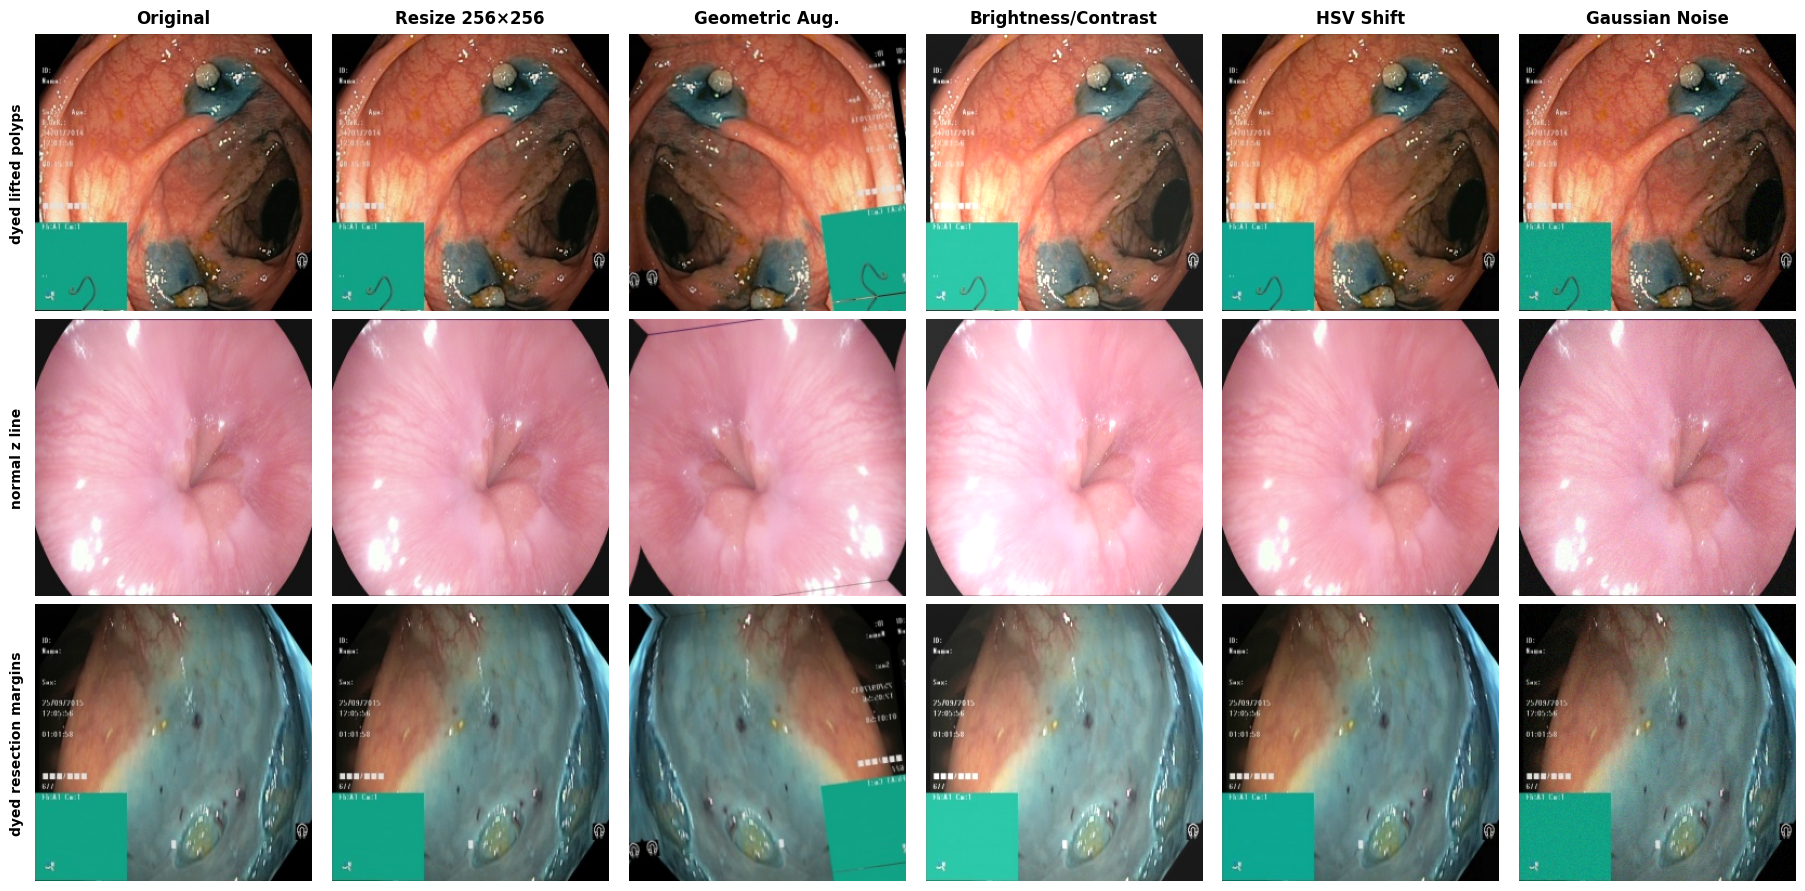

/content/drive/MyDrive/MTG_MaxViTX/figures/q1_preprocessing_augmentation_grid.png


In [ ]:
# ============================================================
# Q1 VISUAL 1 — PREPROCESSING / AUGMENTATION GRID
# Uses only operations that are present in the actual training pipeline.
# ============================================================

from matplotlib import pyplot as plt

VISUAL_DPI = 300
VISUAL_SEED = 42

# Three deterministic training examples; no performance-based selection.
rng_vis = np.random.default_rng(VISUAL_SEED)
vis_indices = np.sort(
    rng_vis.choice(
        len(cls_train_df),
        size=min(3, len(cls_train_df)),
        replace=False
    )
)

column_names = [
    'Original',
    'Resize 256×256',
    'Geometric Aug.',
    'Brightness/Contrast',
    'HSV Shift',
    'Gaussian Noise',
]

# Deterministic visualization transforms matching the ranges used in cls_train_tf.
geom_vis_tf = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(
        limit=(8, 8),
        border_mode=cv2.BORDER_REFLECT_101,
        p=1.0
    ),
])

photo_vis_tf = A.Compose([
    A.RandomBrightnessContrast(
        brightness_limit=(0.10, 0.10),
        contrast_limit=(0.08, 0.08),
        p=1.0
    ),
])

hsv_vis_tf = A.Compose([
    A.HueSaturationValue(
        hue_shift_limit=(2, 2),
        sat_shift_limit=(6, 6),
        val_shift_limit=(4, 4),
        p=1.0
    ),
])

fig, axes = plt.subplots(
    nrows=len(vis_indices),
    ncols=len(column_names),
    figsize=(18, 8.8),
    constrained_layout=True
)

if len(vis_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_i, df_i in enumerate(vis_indices):
    r = cls_train_df.iloc[int(df_i)]

    raw_bgr = safe_read(r.path)
    if raw_bgr is None:
        raise RuntimeError(f'Unreadable visualization image: {r.path}')

    raw = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(
        raw,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    geometric = geom_vis_tf(image=resized)['image']
    photometric = photo_vis_tf(image=resized)['image']
    hsv_shifted = hsv_vis_tf(image=resized)['image']

    # Deterministic mild Gaussian noise within the training range.
    local_rng = np.random.default_rng(VISUAL_SEED + row_i)
    noise = local_rng.normal(
        loc=0.0,
        scale=255.0 * 0.02,
        size=resized.shape
    )
    noisy = np.clip(
        resized.astype(np.float32) + noise,
        0,
        255
    ).astype(np.uint8)

    panels = [
        raw,
        resized,
        geometric,
        photometric,
        hsv_shifted,
        noisy,
    ]

    for col_i, panel in enumerate(panels):
        ax = axes[row_i, col_i]
        ax.imshow(panel)
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        if row_i == 0:
            ax.set_title(
                column_names[col_i],
                fontsize=12,
                fontweight='bold',
                pad=8
            )

    class_name = HK_CLASSES[int(r.label)].replace('-', ' ')
    axes[row_i, 0].set_ylabel(
        class_name,
        fontsize=10,
        fontweight='bold',
        rotation=90,
        labelpad=8
    )

preprocess_png = FIGURES / 'q1_preprocessing_augmentation_grid.png'
fig.savefig(
    preprocess_png,
    dpi=VISUAL_DPI,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()
plt.close(fig)

print(preprocess_png)


## Q1 Visual — Polyp Segmentation Qualitative Grid

model.safetensors: reconstructing file:   0%|          |  0.00B /  117MB            

model.safetensors: downloading bytes:           |  0.00B            

Visual checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt
Scanning segmentation test set for Dice >= 0.90 ...


Selecting high-overlap visual cases:   0%|          | 0/203 [00:00<?, ?it/s]


Eligible cases with Dice >= 0.90: 149

SELECTED HIGH-OVERLAP QUALITATIVE CASES


,filename,gt_area_fraction,dice,iou
0,cju5cky5xb0ay0801oxet697t.jpg,0.054398,0.911088,0.836696
1,cju6w733bveoz0817e600tw72.jpg,0.095108,0.972370,0.946226
2,cju1ats0y372e08011yazcsxm.jpg,0.156006,0.917979,0.848394
3,cju85plp7lmkw0850rx42jdpf.jpg,0.306351,0.958974,0.921181


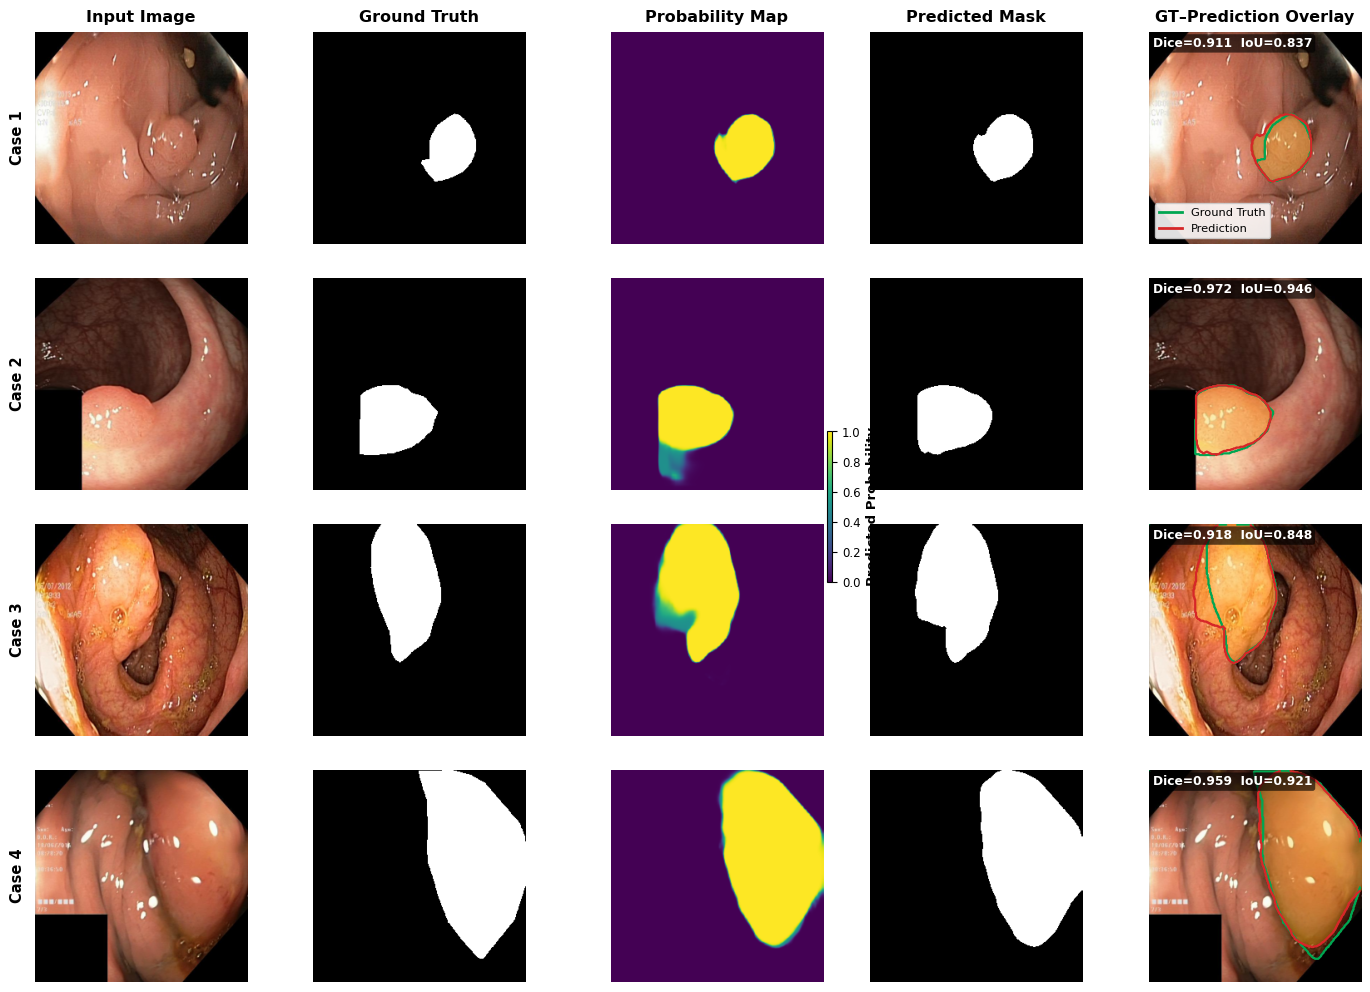

Checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt
Figure: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_segmentation_qualitative_grid_v2.png
Metadata: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_segmentation_qualitative_grid_v2_metadata.csv


,case,filename,test_dataframe_index,gt_area_fraction,dice,iou,selection_basis,selection_quantile
0,1,cju5cky5xb0ay0801oxet697t.jpg,100,0.054398,0.911088,0.836696,Dice >= 0.90 followed by GT lesion-size quantile,0.15
1,2,cju6w733bveoz0817e600tw72.jpg,122,0.095108,0.972370,0.946226,Dice >= 0.90 followed by GT lesion-size quantile,0.40
2,3,cju1ats0y372e08011yazcsxm.jpg,7,0.156006,0.917979,0.848394,Dice >= 0.90 followed by GT lesion-size quantile,0.65
3,4,cju85plp7lmkw0850rx42jdpf.jpg,168,0.306351,0.958974,0.921181,Dice >= 0.90 followed by GT lesion-size quantile,0.90


In [ ]:
# ============================================================
# Q1 VISUAL 2 — SEGMENTATION QUALITATIVE GRID
# Actual Hyper-Kvasir test images + GT + model predictions
#
# Selection:
#   First filters Hyper-Kvasir test cases to Dice >= 0.90
#   using the same visualization checkpoint/inference pipeline.
#   Four cases are then selected across GT lesion-size quantiles.
#
# Columns:
#   Input | Ground Truth | Probability | Prediction | GT–Prediction Overlay
#
# Overlay:
#   GT boundary         = green
#   Predicted boundary  = red
#   Predicted region    = translucent yellow
# ============================================================

from scipy.ndimage import binary_fill_holes
from matplotlib.lines import Line2D


# ============================================================
# 1. CHECKPOINT UTILITIES
# ============================================================

def _extract_model_state(payload):

    if isinstance(payload, dict):

        for key in (
            "model",
            "state_dict",
            "model_state_dict"
        ):
            if (
                key in payload
                and isinstance(payload[key], dict)
            ):
                return payload[key]

        if (
            payload
            and all(
                torch.is_tensor(v)
                for v in payload.values()
            )
        ):
            return payload

    raise RuntimeError(
        "Could not locate a model state_dict in checkpoint."
    )


def _strip_module_prefix(state):

    if (
        state
        and all(
            str(k).startswith("module.")
            for k in state.keys()
        )
    ):
        return {
            str(k)[7:]: v
            for k, v in state.items()
        }

    return state


def _load_visual_model():

    candidates = [

        CHECKPOINTS
        / "mtg_maxvitx_q1_refined_final.pt",

        EXPERIMENTS
        / "five_run_full_mtg_maxvitx_balanced_v2"
        / "mtg-maxvitx"
        / "seed_42"
        / "best.pt",

        EXPERIMENTS
        / "ablation_balanced_v2"
        / "full_mtg-maxvitx"
        / "seed_42"
        / "best.pt",
    ]

    errors = []

    for ckpt_path in candidates:

        if not ckpt_path.exists():
            continue

        try:

            payload = torch.load(
                ckpt_path,
                map_location="cpu",
                weights_only=False
            )

            state = _strip_module_prefix(
                _extract_model_state(
                    payload
                )
            )

            model_vis = MTGMaxViTX().to(
                DEVICE
            )

            model_vis.load_state_dict(
                state,
                strict=True
            )

            model_vis.eval()

            del payload, state

            return model_vis, ckpt_path

        except Exception as exc:

            errors.append(
                f"{ckpt_path.name}: {exc}"
            )

            try:
                del model_vis
            except Exception:
                pass

            q1_cleanup()

    raise RuntimeError(
        "No compatible MTG-MaxViTX checkpoint "
        "was found for visualization.\n"
        + "\n".join(errors)
    )


# ============================================================
# 2. MASK POST-PROCESSING
# ============================================================

def _remove_small_components(
    mask,
    min_fraction=0.003
):

    mask = mask.astype(
        np.uint8
    )

    n_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    out = np.zeros_like(
        mask,
        dtype=np.uint8
    )

    min_area = max(
        1,
        int(
            mask.size
            * float(
                min_fraction
            )
        )
    )

    for lab in range(
        1,
        n_labels
    ):

        if int(
            stats[
                lab,
                cv2.CC_STAT_AREA
            ]
        ) >= min_area:

            out[
                labels == lab
            ] = 1

    out = binary_fill_holes(
        out > 0
    )

    return out.astype(
        np.uint8
    )


# ============================================================
# 3. SEGMENTATION INFERENCE
# ============================================================

def _predict_segmentation_visual(
    model_vis,
    rgb_image
):

    resized = cv2.resize(
        rgb_image,
        (
            IMG_SIZE,
            IMG_SIZE
        ),
        interpolation=cv2.INTER_AREA
    )

    x = (
        eval_tf(
            image=resized
        )["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.inference_mode():

        logits = model_vis(
            x,
            task="seg"
        )["seg"]

        prob = torch.sigmoid(
            logits
        )

        # --------------------------------------------
        # Horizontal TTA
        # --------------------------------------------

        x_flip = torch.flip(
            x,
            dims=[3]
        )

        logits_flip = model_vis(
            x_flip,
            task="seg"
        )["seg"]

        prob_flip = torch.flip(
            torch.sigmoid(
                logits_flip
            ),
            dims=[3]
        )

        prob = (
            0.5
            * (
                prob
                +
                prob_flip
            )
        )

    prob_np = (
        prob[
            0,
            0
        ]
        .detach()
        .cpu()
        .numpy()
    )

    pred = _remove_small_components(
        prob_np >= 0.5,
        min_fraction=0.003
    )

    return (
        resized,
        prob_np,
        pred
    )


# ============================================================
# 4. PER-IMAGE METRICS
# ============================================================

def _binary_seg_metrics(
    gt,
    pred
):

    gt = (
        gt > 0
    ).astype(
        np.uint8
    )

    pred = (
        pred > 0
    ).astype(
        np.uint8
    )

    intersection = float(
        np.logical_and(
            gt,
            pred
        ).sum()
    )

    gt_sum = float(
        gt.sum()
    )

    pred_sum = float(
        pred.sum()
    )

    union = float(
        np.logical_or(
            gt,
            pred
        ).sum()
    )

    eps = 1e-8

    dice = (
        2.0
        * intersection
        /
        (
            gt_sum
            +
            pred_sum
            +
            eps
        )
    )

    iou = (
        intersection
        /
        (
            union
            +
            eps
        )
    )

    return (
        float(dice),
        float(iou)
    )


# ============================================================
# 5. LOAD MODEL BEFORE CASE SELECTION
# ============================================================

model_vis, visual_ckpt = _load_visual_model()

print(
    "Visual checkpoint:",
    visual_ckpt
)


# ============================================================
# 6. SELECT HIGH-QUALITY QUALITATIVE CASES
#
# Criterion:
#   Dice >= 0.90 using the SAME checkpoint and inference
#   pipeline used for the displayed prediction.
#
# Among eligible cases, select four examples spanning
# different GT lesion sizes.
# ============================================================

MIN_DICE_FOR_FIGURE = 0.90
N_VISUAL_CASES = 4

candidate_rows = []

print(
    f"Scanning segmentation test set for "
    f"Dice >= {MIN_DICE_FOR_FIGURE:.2f} ..."
)


for idx in tqdm(
    range(len(seg_test_df)),
    desc="Selecting high-overlap visual cases"
):

    r = seg_test_df.iloc[idx]

    img_bgr = safe_read(
        r.image_path
    )

    gt_raw = safe_read(
        r.mask_path,
        grayscale=True
    )

    if (
        img_bgr is None
        or gt_raw is None
    ):
        continue


    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )


    # --------------------------------------------------------
    # Prediction using the exact visualization pipeline
    # --------------------------------------------------------

    input_256, prob, pred = (
        _predict_segmentation_visual(
            model_vis,
            rgb
        )
    )


    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    gt = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    dice, iou = _binary_seg_metrics(
        gt,
        pred
    )

    gt_area_fraction = float(
        gt.mean()
    )


    # --------------------------------------------------------
    # Keep only Dice >= 0.90
    # --------------------------------------------------------

    if dice >= MIN_DICE_FOR_FIGURE:

        filename = getattr(
            r,
            "seg_filename",
            Path(str(r.image_path)).name
        )

        candidate_rows.append(
            {
                "idx":
                    int(idx),

                "filename":
                    filename,

                "dice":
                    float(dice),

                "iou":
                    float(iou),

                "gt_area_fraction":
                    gt_area_fraction,
            }
        )


candidate_df = pd.DataFrame(
    candidate_rows
)


if len(candidate_df) < N_VISUAL_CASES:

    raise RuntimeError(
        f"Only {len(candidate_df)} test cases achieved "
        f"Dice >= {MIN_DICE_FOR_FIGURE:.2f}. "
        f"At least {N_VISUAL_CASES} are required."
    )


print()
print(
    f"Eligible cases with Dice >= "
    f"{MIN_DICE_FOR_FIGURE:.2f}: "
    f"{len(candidate_df)}"
)


# ============================================================
# Sort candidates by GT lesion size
# ============================================================

candidate_df = (
    candidate_df
    .sort_values(
        "gt_area_fraction"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# Four lesion-size positions:
# small, medium-small, medium-large, large
# ============================================================

visual_quantiles = [
    0.15,
    0.40,
    0.65,
    0.90
]


area_values = candidate_df[
    "gt_area_fraction"
].to_numpy(
    dtype=float
)


targets = np.quantile(
    area_values,
    visual_quantiles
)


selected = []
selected_records = []
used_indices = set()


for target in targets:

    distance_order = np.argsort(
        np.abs(
            area_values
            -
            target
        )
    )

    for pos in distance_order:

        pos = int(pos)

        test_idx = int(
            candidate_df.iloc[
                pos
            ]["idx"]
        )

        if test_idx in used_indices:
            continue

        selected.append(
            test_idx
        )

        selected_records.append(
            candidate_df.iloc[
                pos
            ].to_dict()
        )

        used_indices.add(
            test_idx
        )

        break


if len(selected) != N_VISUAL_CASES:

    raise RuntimeError(
        "Could not select four unique high-Dice cases."
    )


selected_preview = pd.DataFrame(
    selected_records
)


print()
print(
    "=" * 75
)

print(
    "SELECTED HIGH-OVERLAP QUALITATIVE CASES"
)

print(
    "=" * 75
)

display(
    selected_preview[
        [
            "filename",
            "gt_area_fraction",
            "dice",
            "iou",
        ]
    ]
)


# ============================================================
# 7. FIGURE CONFIGURATION
# ============================================================

column_names = [

    "Input Image",

    "Ground Truth",

    "Probability Map",

    "Predicted Mask",

    "GT–Prediction Overlay",
]


n_rows = len(
    selected
)


fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=5,

    figsize=(
        15.2,
        10.8
    ),

    constrained_layout=False
)


plt.subplots_adjust(

    left=0.055,

    right=0.965,

    top=0.935,

    bottom=0.055,

    wspace=0.035,

    hspace=0.16
)


# ============================================================
# 8. FIXED JOURNAL COLORS
# ============================================================

GT_COLOR = "#00A651"       # green
PRED_COLOR = "#D62728"     # red
FILL_COLOR = np.array(
    [
        1.00,
        0.78,
        0.10
    ],
    dtype=np.float32
)

OVERLAY_ALPHA = 0.28


# ============================================================
# 9. DRAW CASES
# ============================================================

metadata_rows = []

probability_artist = None


for row_i, idx in enumerate(
    selected
):

    r = seg_test_df.iloc[
        int(idx)
    ]


    # --------------------------------------------
    # Load image and GT
    # --------------------------------------------

    img_bgr = safe_read(
        r.image_path
    )

    gt_raw = safe_read(
        r.mask_path,
        grayscale=True
    )


    if (
        img_bgr is None
        or gt_raw is None
    ):

        raise RuntimeError(
            f"Unreadable segmentation pair: "
            f"{r.image_path}"
        )


    rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )


    input_256, prob, pred = (
        _predict_segmentation_visual(
            model_vis,
            rgb
        )
    )


    gt = cv2.resize(

        (
            gt_raw > 127
        ).astype(
            np.uint8
        ),

        (
            IMG_SIZE,
            IMG_SIZE
        ),

        interpolation=cv2.INTER_NEAREST
    )


    # --------------------------------------------
    # Metrics
    # --------------------------------------------

    dice, iou = _binary_seg_metrics(
        gt,
        pred
    )


    # --------------------------------------------
    # Overlay
    # --------------------------------------------

    overlay = (
        input_256.astype(
            np.float32
        )
        /
        255.0
    )


    pred_alpha = (

        pred.astype(
            np.float32
        )[..., None]

        *
        OVERLAY_ALPHA
    )


    overlay = (

        overlay
        *
        (
            1.0
            -
            pred_alpha
        )

        +

        FILL_COLOR[
            None,
            None,
            :
        ]
        *
        pred_alpha
    )


    overlay = np.clip(
        overlay,
        0.0,
        1.0
    )


    # --------------------------------------------
    # PANELS
    # --------------------------------------------

    # Input
    axes[
        row_i,
        0
    ].imshow(
        input_256
    )


    # Ground Truth
    axes[
        row_i,
        1
    ].imshow(
        gt,
        cmap="gray",
        vmin=0,
        vmax=1
    )


    # Probability
    probability_artist = (
        axes[
            row_i,
            2
        ].imshow(
            prob,
            cmap="viridis",
            vmin=0,
            vmax=1,
            interpolation="bilinear"
        )
    )


    # Predicted Mask
    axes[
        row_i,
        3
    ].imshow(
        pred,
        cmap="gray",
        vmin=0,
        vmax=1
    )


    # Overlay
    axes[
        row_i,
        4
    ].imshow(
        overlay
    )


    # --------------------------------------------
    # GT contour = green
    # --------------------------------------------

    axes[
        row_i,
        4
    ].contour(

        gt,

        levels=[
            0.5
        ],

        colors=[
            GT_COLOR
        ],

        linewidths=1.6
    )


    # --------------------------------------------
    # Prediction contour = red
    # --------------------------------------------

    axes[
        row_i,
        4
    ].contour(

        pred,

        levels=[
            0.5
        ],

        colors=[
            PRED_COLOR
        ],

        linewidths=1.6
    )


    # --------------------------------------------
    # Dice / IoU annotation
    # --------------------------------------------

    axes[
        row_i,
        4
    ].text(

        0.02,

        0.975,

        (
            f"Dice={dice:.3f}  "
            f"IoU={iou:.3f}"
        ),

        transform=axes[
            row_i,
            4
        ].transAxes,

        fontsize=8.8,

        fontweight="bold",

        color="white",

        va="top",

        ha="left",

        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="black",
            edgecolor="none",
            alpha=0.62
        )
    )


    # --------------------------------------------
    # Row labels
    # --------------------------------------------

    lesion_fraction = float(
        gt.mean()
    )


    axes[
        row_i,
        0
    ].set_ylabel(

        f"Case {row_i + 1}",

        fontsize=10.5,

        fontweight="bold",

        rotation=90,

        labelpad=7
    )


    # --------------------------------------------
    # Metadata
    # --------------------------------------------

    filename = getattr(

        r,

        "seg_filename",

        Path(
            str(
                r.image_path
            )
        ).name
    )


    metadata_rows.append(
        {
            "case":
                row_i + 1,

            "filename":
                filename,

            "test_dataframe_index":
                int(idx),

            "gt_area_fraction":
                lesion_fraction,

            "dice":
                dice,

            "iou":
                iou,

            "selection_basis":
                "Dice >= 0.90 followed by GT lesion-size quantile",

            "selection_quantile":
                visual_quantiles[
                    row_i
                ],
        }
    )


    # --------------------------------------------
    # Common axis formatting
    # --------------------------------------------

    for col_i in range(
        5
    ):

        ax = axes[
            row_i,
            col_i
        ]

        ax.set_xticks(
            []
        )

        ax.set_yticks(
            []
        )

        for spine in (
            ax.spines.values()
        ):
            spine.set_visible(
                False
            )


        if row_i == 0:

            ax.set_title(

                column_names[
                    col_i
                ],

                fontsize=11.5,

                fontweight="bold",

                pad=7
            )


# ============================================================
# 10. SINGLE PROBABILITY COLORBAR
# ============================================================

if probability_artist is not None:

    cbar = fig.colorbar(

        probability_artist,

        ax=axes[
            :,
            2
        ].tolist(),

        fraction=0.020,

        pad=0.015,

        aspect=28
    )


    cbar.set_label(

        "Predicted Probability",

        fontsize=9.5,

        fontweight="bold"
    )


    cbar.ax.tick_params(
        labelsize=8.5
    )


# ============================================================
# 11. OVERLAY LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=GT_COLOR,
        lw=2.0,
        label="Ground Truth"
    ),

    Line2D(
        [0],
        [0],
        color=PRED_COLOR,
        lw=2.0,
        label="Prediction"
    ),
]


axes[
    0,
    4
].legend(

    handles=legend_handles,

    loc="lower left",

    fontsize=8.2,

    frameon=True,

    framealpha=0.88,

    edgecolor="0.8"
)


# ============================================================
# 12. SAVE FIGURE
# ============================================================

seg_visual_png = (
    FIGURES
    /
    "q1_segmentation_qualitative_grid_v2.png"
)


fig.savefig(

    seg_visual_png,

    dpi=VISUAL_DPI,

    bbox_inches="tight",

    facecolor="white",

    pad_inches=0.05
)


plt.show()

plt.close(
    fig
)


# ============================================================
# 13. SAVE CASE METADATA
# ============================================================

seg_visual_metadata = (
    FIGURES
    /
    "q1_segmentation_qualitative_grid_v2_metadata.csv"
)


pd.DataFrame(
    metadata_rows
).to_csv(
    seg_visual_metadata,
    index=False
)


# ============================================================
# 14. REPORT
# ============================================================

print(
    "Checkpoint:",
    visual_ckpt
)

print(
    "Figure:",
    seg_visual_png
)

print(
    "Metadata:",
    seg_visual_metadata
)


display(
    pd.DataFrame(
        metadata_rows
    )
)


# ============================================================
# 15. CLEANUP
# ============================================================

del model_vis

q1_cleanup()

In [ ]:
def _boundary_f1_score(
    gt_boundary,
    pred_boundary,
    tolerance_px=2
):
    """
    Boundary F1 with spatial tolerance.

    GT and prediction boundaries are binary arrays.
    A predicted boundary pixel is considered correct if it lies
    within `tolerance_px` pixels of the GT boundary, and vice versa.
    """

    gt_boundary = (
        gt_boundary > 0
    ).astype(np.uint8)

    pred_boundary = (
        pred_boundary > 0
    ).astype(np.uint8)

    if (
        gt_boundary.sum() == 0
        and pred_boundary.sum() == 0
    ):
        return 1.0

    if (
        gt_boundary.sum() == 0
        or pred_boundary.sum() == 0
    ):
        return 0.0

    kernel_size = (
        2 * int(tolerance_px) + 1
    )

    kernel = np.ones(
        (
            kernel_size,
            kernel_size
        ),
        dtype=np.uint8
    )

    gt_dilated = cv2.dilate(
        gt_boundary,
        kernel,
        iterations=1
    )

    pred_dilated = cv2.dilate(
        pred_boundary,
        kernel,
        iterations=1
    )

    matched_pred = np.logical_and(
        pred_boundary > 0,
        gt_dilated > 0
    ).sum()

    matched_gt = np.logical_and(
        gt_boundary > 0,
        pred_dilated > 0
    ).sum()

    precision = (
        matched_pred
        /
        max(
            pred_boundary.sum(),
            1
        )
    )

    recall = (
        matched_gt
        /
        max(
            gt_boundary.sum(),
            1
        )
    )

    if (
        precision + recall
    ) == 0:
        return 0.0

    bf1 = (
        2.0
        * precision
        * recall
        /
        (
            precision
            +
            recall
        )
    )

    return float(bf1)

Checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt
Scanning performance-guided Hyper-Kvasir classes...


Classification scan:   0%|          | 0/2119 [00:00<?, ?it/s]

Primary class skipped after CAM-quality screening: retroflex-rectum
Primary class skipped after CAM-quality screening: dyed-resection-margins

CLASS-WISE PERFORMANCE-GUIDED GRAD-CAM SELECTION


,class_name,class_support,class_f1,mean_true_class_probability,confidence,selection_group,cam_quality_pass,cam_area_fraction,cam_border_fraction,path
0,polyp,205,0.980296,0.776709,0.609708,primary,True,0.167603,0.000000,/content/MTG_MaxViTX_classification_cache_256/...
1,normal-pylorus,199,0.987531,0.806787,0.562968,primary,True,0.056442,0.000000,/content/MTG_MaxViTX_classification_cache_256/...
2,normal-cecum,201,0.985000,0.781816,0.580894,primary,True,0.079437,0.000000,/content/MTG_MaxViTX_classification_cache_256/...
3,impacted-stool,26,0.813559,0.821526,0.874777,primary,True,0.092072,0.059165,/content/MTG_MaxViTX_classification_cache_256/...
4,bbps-2-3,229,0.966887,0.751765,0.496953,fallback,True,0.015503,0.000000,/content/MTG_MaxViTX_classification_cache_256/...
5,bbps-0-1,129,0.964706,0.815777,0.696273,fallback,True,0.019028,0.000000,/content/MTG_MaxViTX_classification_cache_256/...


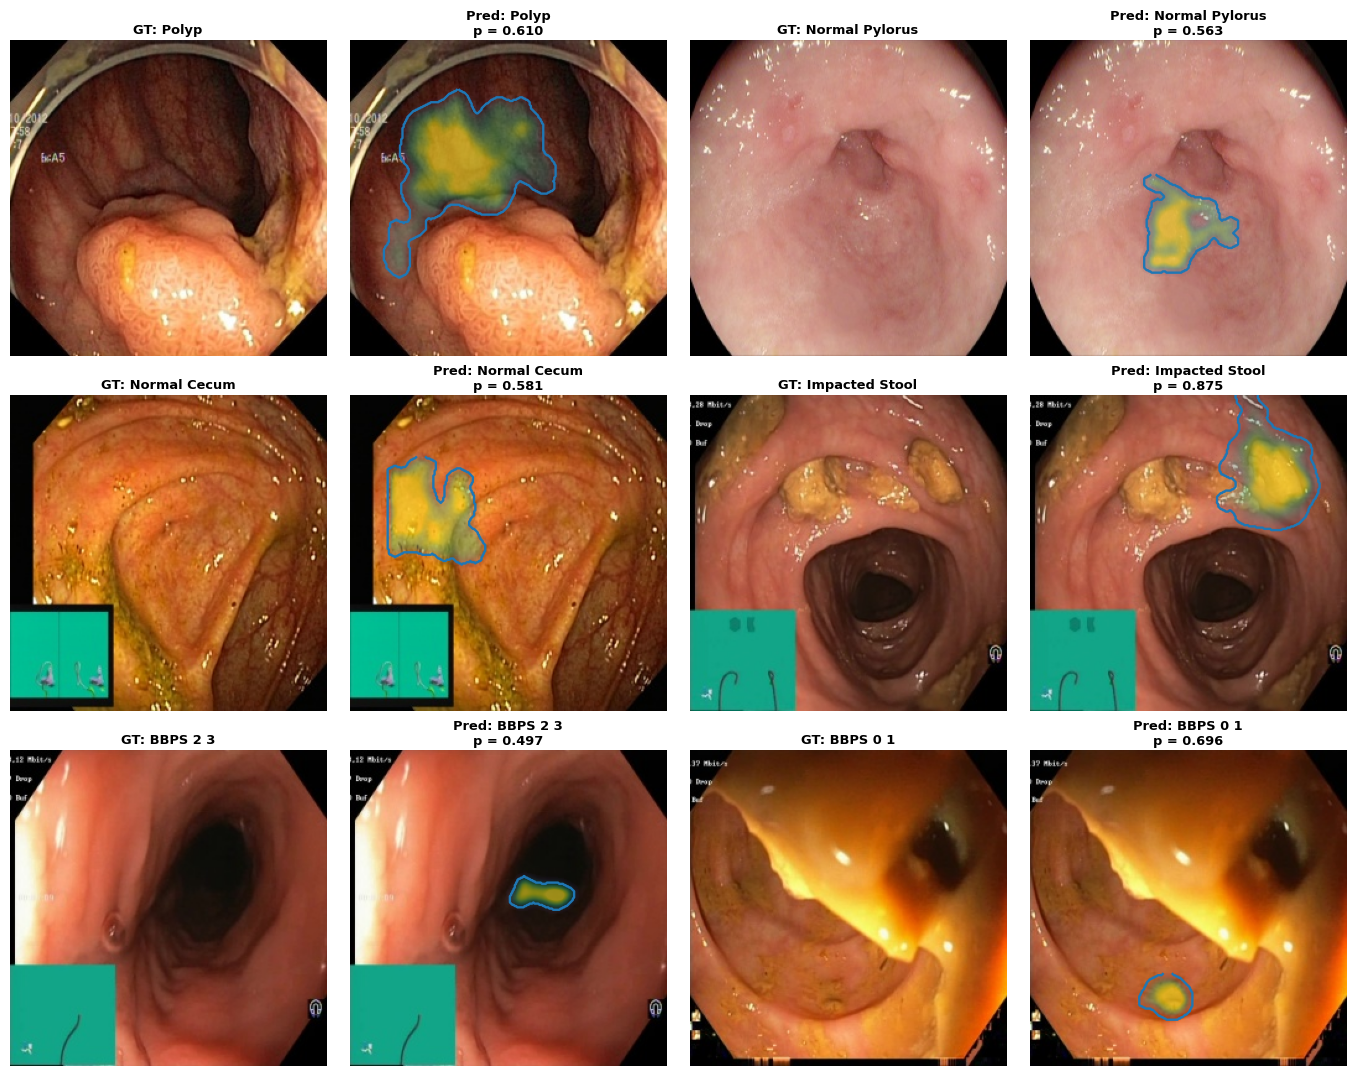


Checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt
PNG: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_classification_gradcam_final.png
PDF: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_classification_gradcam_final.pdf
Metadata: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_classification_gradcam_final_metadata.csv

CAPTION:
Classification-branch Grad-CAM explanations of MTG-MaxViTX on correctly classified Hyper-Kvasir test images. The displayed classes were selected from the class-wise test performance analysis to provide diagnostically diverse examples with reliable class-level recognition. Within each class, a high-confidence correctly classified image was chosen and screened to avoid border-dominated or non-informative Grad-CAM regions. Each original endoscopic image is paired with the Grad-CAM attention map for its predicted class. The highlighted regions represent discriminative classification attention and should not be interpreted as les

,sample,filename,ground_truth,prediction,confidence,correct,class_f1,class_support,mean_true_class_probability,selection_group,cam_quality_pass,cam_quality_score,cam_area_fraction,cam_border_fraction,selection_basis,xai_method
0,1,9fd96c4ba836_f586fb7b-7b28-4bb0-b5ea-9ef404053...,polyp,polyp,0.609708,True,0.980296,205,0.776709,primary,True,0.765654,0.167603,0.000000,Class-wise performance-guided; correct predict...,Flip-smoothed multi-scale classification-branc...
1,2,ffee17b44035_eef81ea8-24d3-4159-bf1f-b388ace71...,normal-pylorus,normal-pylorus,0.562968,True,0.987531,199,0.806787,primary,True,0.829016,0.056442,0.000000,Class-wise performance-guided; correct predict...,Flip-smoothed multi-scale classification-branc...
2,3,9dda7ba9bba0_8fd916c6-ccca-4e0b-8239-5f76b7112...,normal-cecum,normal-cecum,0.580894,True,0.985000,201,0.781816,primary,True,0.858360,0.079437,0.000000,Class-wise performance-guided; correct predict...,Flip-smoothed multi-scale classification-branc...
3,4,ed12326df716_4b94c3d3-73f4-4182-b5ea-c3bb2f285...,impacted-stool,impacted-stool,0.874777,True,0.813559,26,0.821526,primary,True,0.789034,0.092072,0.059165,Class-wise performance-guided; correct predict...,Flip-smoothed multi-scale classification-branc...
4,5,e3a4f8512eb6_72f759ef-281b-4246-b5b3-67706d333...,bbps-2-3,bbps-2-3,0.496953,True,0.966887,229,0.751765,fallback,True,0.814134,0.015503,0.000000,Class-wise performance-guided; correct predict...,Flip-smoothed multi-scale classification-branc...
5,6,3a142f8db334_295efa66-5982-4246-ac7d-5884ac886...,bbps-0-1,bbps-0-1,0.696273,True,0.964706,129,0.815777,fallback,True,0.739010,0.019028,0.000000,Class-wise performance-guided; correct predict...,Flip-smoothed multi-scale classification-branc...


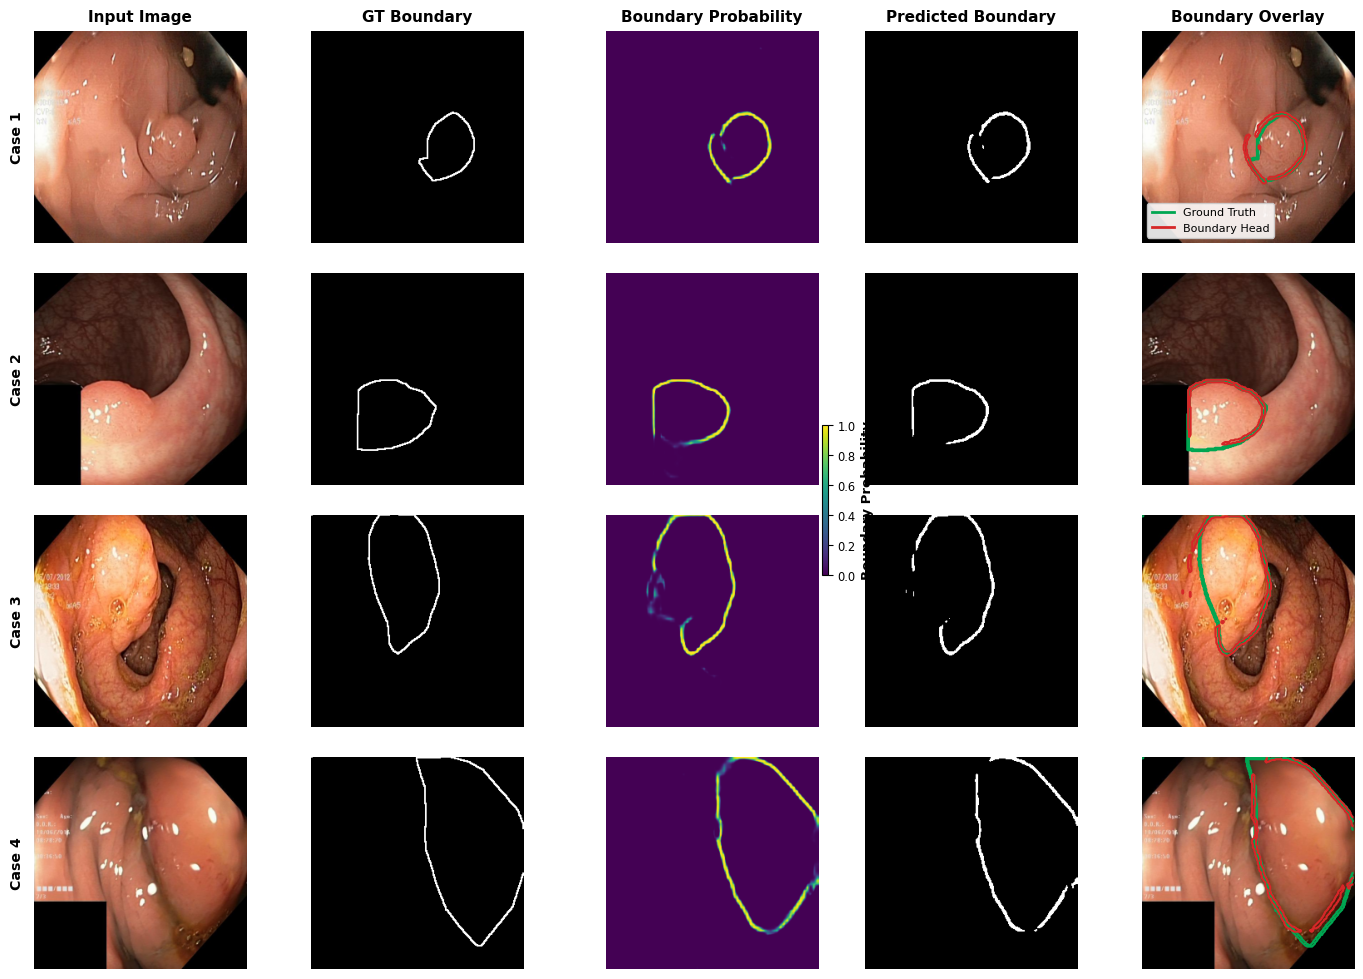

Checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt
Figure: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_boundary_head_qualitative_grid.png
Metadata: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_boundary_head_qualitative_grid_metadata.csv


Scanning segmentation failures:   0%|          | 0/203 [00:00<?, ?it/s]

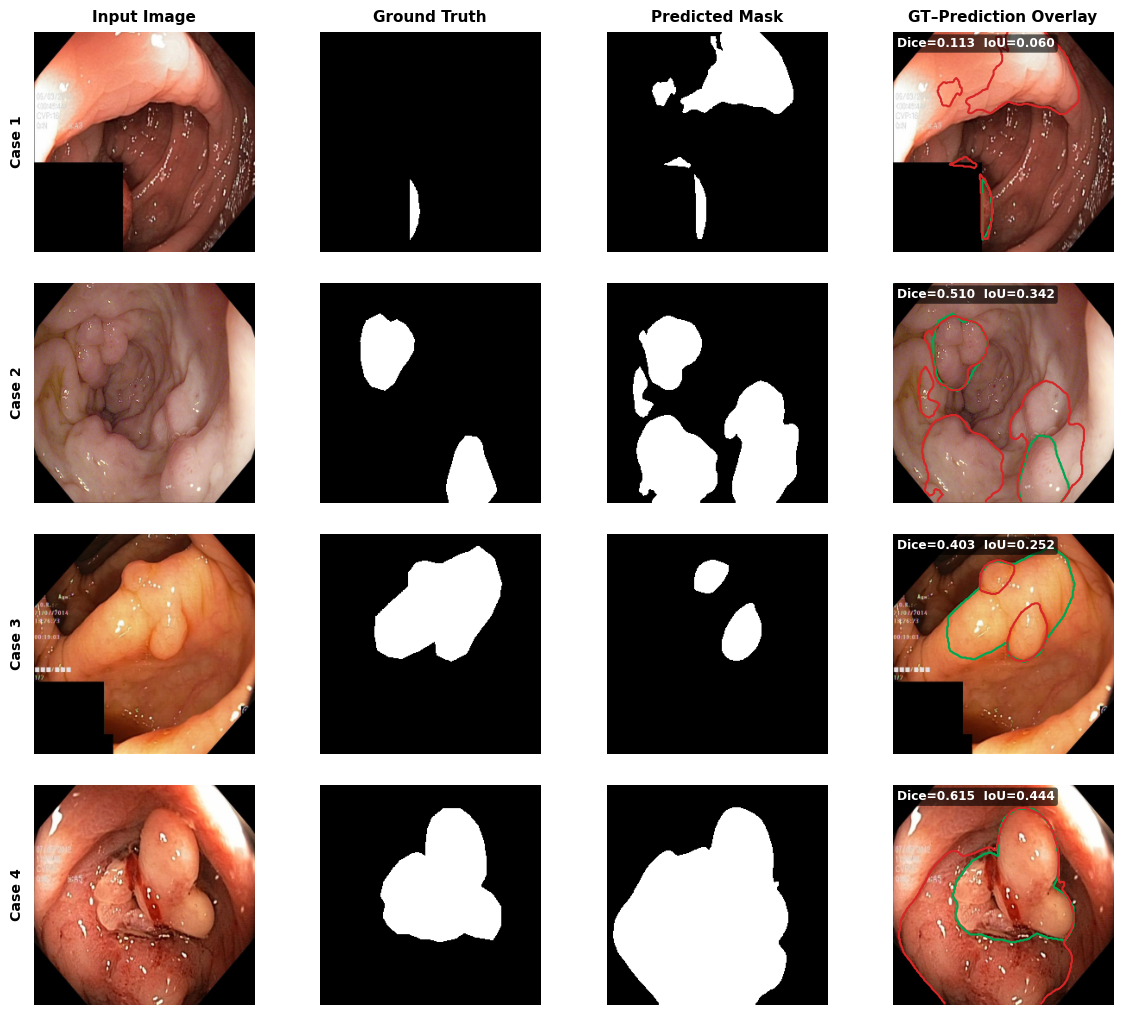

Checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt
Figure: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_segmentation_challenging_cases.png
Metadata: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_segmentation_challenging_cases_metadata.csv


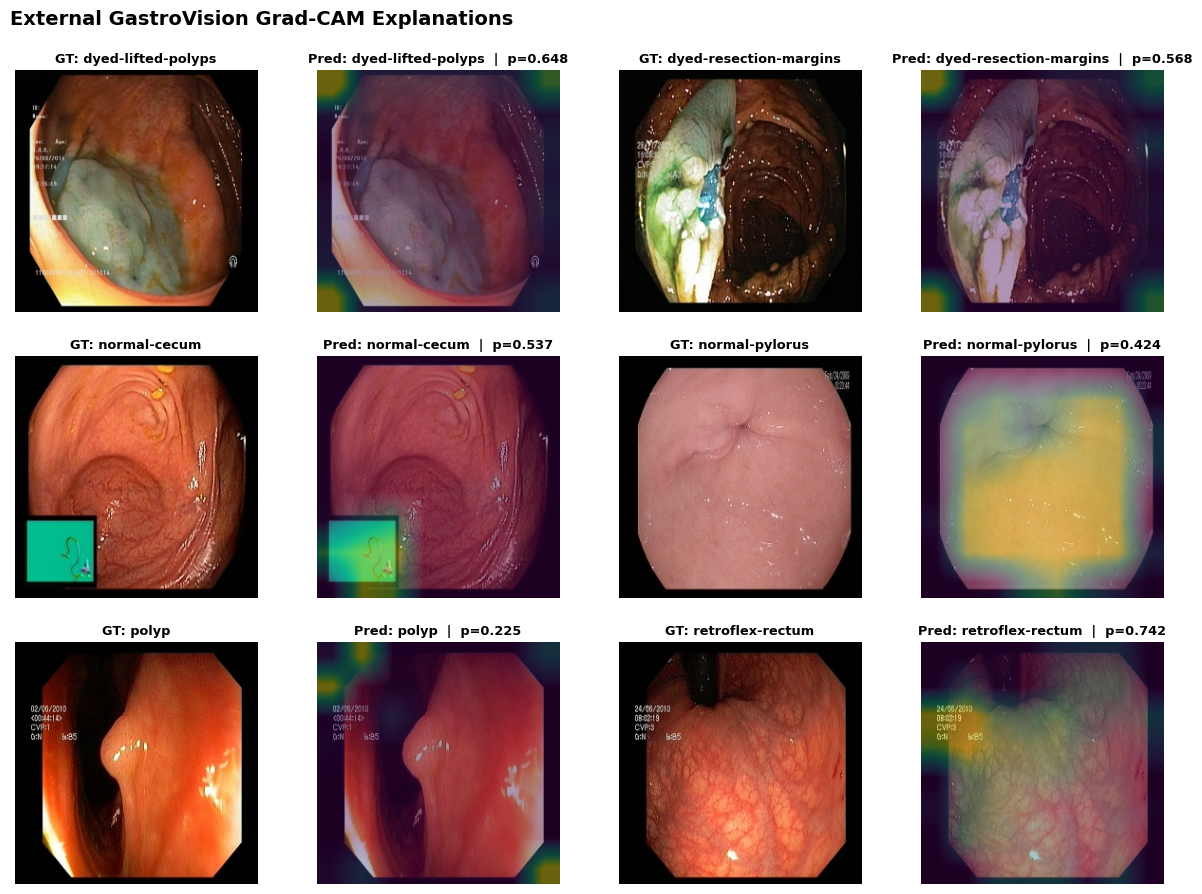

Checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt
Figure: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_gastrovision_gradcam_grid.png
Metadata: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_gastrovision_gradcam_grid_metadata.csv


In [ ]:
# ============================================================
# Q1 ADDITIONAL VISUALS FOR MTG-MaxViTX
# Assumes the resume notebook has already defined:
#   DEVICE, IMG_SIZE, SEED, VISUAL_DPI, FIGURES, HK_CLASSES,
#   cls_test_df, seg_test_df, gv_mapped, eval_tf, safe_read,
#   _load_visual_model, _binary_seg_metrics, q1_cleanup.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm.auto import tqdm


# ============================================================
# COMMON HELPERS
# ============================================================

def _q1_norm01(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = arr - float(np.nanmin(arr))
    den = float(np.nanmax(arr))
    if den > 1e-8:
        arr = arr / den
    return np.clip(arr, 0.0, 1.0)


def _q1_gradcam_for_pred(model_vis, rgb_image):
    """Grad-CAM of the MaxViT classification branch for its predicted class."""
    resized = cv2.resize(
        rgb_image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA,
    )

    x = eval_tf(image=resized)["image"].unsqueeze(0).to(DEVICE)
    x.requires_grad_(True)
    model_vis.zero_grad(set_to_none=True)

    with torch.enable_grad():
        out = model_vis(x, task="cls", return_features=True)
        logits = out["cls"]
        probs = torch.softmax(logits, dim=1)
        pred_id = int(probs.argmax(dim=1).item())
        confidence = float(probs[0, pred_id].detach().cpu())

        feature_map = out["features"][-1]
        target_score = logits[0, pred_id]

        grads = torch.autograd.grad(
            target_score,
            feature_map,
            retain_graph=False,
            create_graph=False,
            allow_unused=False,
        )[0]

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * feature_map).sum(dim=1, keepdim=True))
        cam = F.interpolate(
            cam,
            size=(IMG_SIZE, IMG_SIZE),
            mode="bilinear",
            align_corners=False,
        )

    cam_np = _q1_norm01(cam[0, 0].detach().cpu().numpy())
    return resized, cam_np, pred_id, confidence


def _q1_cam_overlay(rgb_256, cam, alpha=0.42):
    base = rgb_256.astype(np.float32) / 255.0
    heat = plt.cm.viridis(cam)[..., :3]
    return np.clip((1.0 - alpha) * base + alpha * heat, 0.0, 1.0)


def _q1_gt_boundary(mask, kernel_size=3):
    mask = (np.asarray(mask) > 0).astype(np.uint8)
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    dil = cv2.dilate(mask, kernel, iterations=1)
    ero = cv2.erode(mask, kernel, iterations=1)
    return ((dil - ero) > 0).astype(np.uint8)


def _q1_predict_boundary_visual(model_vis, rgb_image):
    resized = cv2.resize(
        rgb_image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA,
    )
    x = eval_tf(image=resized)["image"].unsqueeze(0).to(DEVICE)

    with torch.inference_mode():
        out = model_vis(x, task="seg")
        if "boundary" not in out:
            raise RuntimeError(
                "The loaded checkpoint/model does not expose the boundary head."
            )
        boundary_prob = torch.sigmoid(out["boundary"])[0, 0].cpu().numpy()

    boundary_pred = (boundary_prob >= 0.5).astype(np.uint8)
    return resized, boundary_prob, boundary_pred


def _q1_size_diverse_seg_indices(frame, n=4):
    rows = []
    for idx in range(len(frame)):
        r = frame.iloc[idx]
        gt_raw = safe_read(r.mask_path, grayscale=True)
        if gt_raw is None:
            continue
        rows.append((int(idx), float((gt_raw > 127).mean())))

    if len(rows) < n:
        raise RuntimeError("Not enough readable segmentation test cases.")

    rows = sorted(rows, key=lambda z: z[1])
    areas = np.asarray([z[1] for z in rows], dtype=float)
    qs = np.linspace(0.15, 0.90, n)
    targets = np.quantile(areas, qs)

    chosen, used = [], set()
    for target in targets:
        for pos in np.argsort(np.abs(areas - target)):
            idx = rows[int(pos)][0]
            if idx not in used:
                chosen.append(idx)
                used.add(idx)
                break
    return chosen


# ============================================================
# Q1 VISUAL — CLASSIFICATION-BRANCH GRAD-CAM
# FINAL JOURNAL VERSION
#
# Layout:
#   GT Image 1 | Grad-CAM 1 | GT Image 2 | Grad-CAM 2
#   3 rows × 4 columns = 6 class-diverse examples
#
# Selection:
#   - Hyper-Kvasir TEST set only
#   - Six predefined classes selected from the reported class-wise
#     test-performance table
#   - Correct predictions only
#   - One image per selected class
#   - Highest-confidence candidate preferred
#   - CAM-quality screening rejects border/corner-dominated attention
#
# Figure caption is NOT drawn inside the figure.
# ============================================================

from pathlib import Path
import textwrap

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm.auto import tqdm


# ============================================================
# 0. CONFIGURATION
# ============================================================

N_VISUALS = 6

# ------------------------------------------------------------
# Performance-guided target classes
# Values are taken from the reported class-wise Hyper-Kvasir
# test-performance table used in the manuscript.
# ------------------------------------------------------------

TARGET_VISUAL_CLASSES = [
    "polyp",
    "normal-pylorus",
    "normal-cecum",
    "retroflex-rectum",
    "dyed-resection-margins",
    "impacted-stool",
]

CLASS_F1_REFERENCE = {
    "polyp": 0.980296,
    "normal-pylorus": 0.987531,
    "normal-cecum": 0.985000,
    "retroflex-rectum": 0.955414,
    "dyed-resection-margins": 0.954774,
    "impacted-stool": 0.813559,
}

CLASS_SUPPORT_REFERENCE = {
    "polyp": 205,
    "normal-pylorus": 199,
    "normal-cecum": 201,
    "retroflex-rectum": 78,
    "dyed-resection-margins": 197,
    "impacted-stool": 26,
}

CLASS_MEAN_TRUE_PROB_REFERENCE = {
    "polyp": 0.776709,
    "normal-pylorus": 0.806787,
    "normal-cecum": 0.781816,
    "retroflex-rectum": 0.834004,
    "dyed-resection-margins": 0.772539,
    "impacted-stool": 0.821526,
}

# Secondary classes are used only if a target class has no usable
# correctly classified sample.
FALLBACK_VISUAL_CLASSES = [
    "retroflex-stomach",
    "bbps-2-3",
    "bbps-0-1",
    "dyed-lifted-polyps",
    "normal-z-line",
    "ulcerative-colitis-grade-2",
]

FALLBACK_CLASS_F1_REFERENCE = {
    "retroflex-stomach": 0.996700,
    "bbps-2-3": 0.966887,
    "bbps-0-1": 0.964706,
    "dyed-lifted-polyps": 0.951899,
    "normal-z-line": 0.881013,
    "ulcerative-colitis-grade-2": 0.739336,
}

FALLBACK_CLASS_SUPPORT_REFERENCE = {
    "retroflex-stomach": 152,
    "bbps-2-3": 229,
    "bbps-0-1": 129,
    "dyed-lifted-polyps": 200,
    "normal-z-line": 186,
    "ulcerative-colitis-grade-2": 88,
}

FALLBACK_CLASS_MEAN_TRUE_PROB_REFERENCE = {
    "retroflex-stomach": 0.837524,
    "bbps-2-3": 0.751765,
    "bbps-0-1": 0.815777,
    "dyed-lifted-polyps": 0.758426,
    "normal-z-line": 0.731871,
    "ulcerative-colitis-grade-2": 0.749127,
}

PREFERRED_MIN_CONFIDENCE = 0.85
MINIMUM_SAMPLE_CONFIDENCE = 0.70

MAX_CAM_CANDIDATES_PER_CLASS = 5

CAM_QUALITY_SCREENING = True
CAM_SCREEN_BORDER_RATIO = 0.07
CAM_SCREEN_MIN_AREA_RATIO = 0.010
CAM_SCREEN_MAX_AREA_RATIO = 0.25
CAM_SCREEN_MAX_BORDER_FRACTION = 0.08

CAM_LAYER_INDICES = (
    -2,
    -3,
)

CAM_LAYER_WEIGHTS = (
    0.72,
    0.28,
)

CAM_PERCENTILE = 80

CAM_MIN_AREA_RATIO = 0.006

CAM_MAX_AREA_RATIO = 0.26

CAM_BORDER_MARGIN_RATIO = 0.055

CAM_ALPHA_MAX = 0.58

CAM_CONTOUR_WIDTH = 1.7

TITLE_FONT_SIZE = 9.4

VISUAL_RANDOM_SEED = 42


# ============================================================
# 1. TEXT / DATA HELPERS
# ============================================================

def _q1_pretty_class_name(name):
    """
    Convert internal class string into journal-friendly text.
    """

    name = (
        str(name)
        .replace("_", " ")
        .replace("-", " ")
        .strip()
    )

    replacements = {
        "Bbps": "BBPS",
        "Oesophagitis A": "Oesophagitis A",
        "Oesophagitis B D": "Oesophagitis B-D",
    }

    pretty = name.title()

    for old, new in replacements.items():
        pretty = pretty.replace(
            old,
            new
        )

    return pretty


def _q1_wrap_class_name(
    name,
    width=25
):
    """
    Wrap long disease names to avoid title overlap.
    """

    pretty = _q1_pretty_class_name(
        name
    )

    return textwrap.fill(
        pretty,
        width=width
    )


def _q1_get_image_path(row):
    """
    Robust path lookup for cls_test_df.
    """

    for key in (
        "path",
        "image_path",
        "filepath",
        "file_path",
    ):

        if (
            key in row.index
            and
            pd.notna(
                row[key]
            )
        ):

            return str(
                row[key]
            )

    raise KeyError(
        "Could not locate image path column in cls_test_df."
    )


def _q1_get_label(row):
    """
    Robust class-label extraction.
    """

    if "label" not in row.index:

        raise KeyError(
            "cls_test_df must contain a 'label' column."
        )

    value = row[
        "label"
    ]

    if isinstance(
        value,
        str
    ):

        if value in HK_CLASSES:

            return int(
                HK_CLASSES.index(
                    value
                )
            )

        try:

            return int(
                value
            )

        except Exception as exc:

            raise ValueError(
                f"Unsupported label value: {value}"
            ) from exc

    return int(
        value
    )


# ============================================================
# 2. IMAGE HELPERS
# ============================================================

def _q1_read_rgb(
    path
):
    """
    Read image through notebook-safe reader and return RGB.
    """

    img = safe_read(
        path
    )

    if img is None:

        return None

    if img.ndim == 2:

        return cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

    return cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )


def _q1_prepare_image(
    rgb
):
    """
    Resize for visualization and prepare model tensor.
    """

    rgb_256 = cv2.resize(
        rgb,
        (
            IMG_SIZE,
            IMG_SIZE
        ),
        interpolation=cv2.INTER_AREA
    )

    x = eval_tf(
        image=rgb_256
    )[
        "image"
    ]

    return (
        rgb_256,
        x
    )


# ============================================================
# 3. NORMALIZATION
# ============================================================

def _q1_norm01(
    arr
):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    arr = np.nan_to_num(
        arr,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    positive = arr[
        arr > 0
    ]

    if positive.size == 0:

        return np.zeros_like(
            arr,
            dtype=np.float32
        )

    lo = np.percentile(
        positive,
        2
    )

    hi = np.percentile(
        positive,
        98
    )

    arr = (
        arr - lo
    ) / (
        hi - lo + 1e-8
    )

    return np.clip(
        arr,
        0.0,
        1.0
    ).astype(
        np.float32
    )


# ============================================================
# 4. CLASSIFICATION PREDICTION
# ============================================================

def _q1_predict_classification(
    model_vis,
    x_chw
):
    """
    Prediction from the classification branch.

    Horizontal flip TTA is used only for probability smoothing.
    """

    x = (
        x_chw
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.inference_mode():

        logits = model_vis(
            x,
            task="cls"
        )[
            "cls"
        ]

        prob_original = torch.softmax(
            logits,
            dim=1
        )

        x_flip = torch.flip(
            x,
            dims=[
                3
            ]
        )

        logits_flip = model_vis(
            x_flip,
            task="cls"
        )[
            "cls"
        ]

        prob_flip = torch.softmax(
            logits_flip,
            dim=1
        )

        prob = (
            0.70
            *
            prob_original

            +

            0.30
            *
            prob_flip
        )

    prob_np = (
        prob[
            0
        ]
        .detach()
        .cpu()
        .numpy()
    )

    pred_id = int(
        np.argmax(
            prob_np
        )
    )

    confidence = float(
        prob_np[
            pred_id
        ]
    )

    return (
        prob_np,
        pred_id,
        confidence
    )


# ============================================================
# 5. ENDOSCOPIC FIELD-OF-VIEW MASK
# ============================================================

def _q1_build_fov_mask(
    rgb_image
):

    image = np.asarray(
        rgb_image
    )

    if image.max() <= 1.5:

        image = (
            image
            *
            255.0
        ).clip(
            0,
            255
        ).astype(
            np.uint8
        )

    else:

        image = image.astype(
            np.uint8
        )

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    binary = (
        gray > 8
    ).astype(
        np.uint8
    )

    close_kernel = (
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                17,
                17
            )
        )
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        close_kernel,
        iterations=2
    )

    contours, _ = (
        cv2.findContours(
            binary,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
    )

    fov = np.zeros_like(
        binary
    )

    if contours:

        largest = max(
            contours,
            key=cv2.contourArea
        )

        cv2.drawContours(
            fov,
            [
                largest
            ],
            -1,
            1,
            thickness=-1
        )

    else:

        fov[:] = 1


    # --------------------------------------------------------
    # Suppress outer endoscope border
    # --------------------------------------------------------

    h, w = fov.shape

    margin = max(
        3,
        int(
            CAM_BORDER_MARGIN_RATIO
            *
            min(
                h,
                w
            )
        )
    )

    erode_kernel = (
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                2 * margin + 1,
                2 * margin + 1
            )
        )
    )

    inner_fov = cv2.erode(
        fov,
        erode_kernel,
        iterations=1
    )


    # --------------------------------------------------------
    # Suppress common lower-left acquisition annotation area
    # --------------------------------------------------------

    annotation_h = int(
        0.20
        *
        h
    )

    annotation_w = int(
        0.26
        *
        w
    )

    inner_fov[
        h - annotation_h:h,
        0:annotation_w
    ] = 0

    return inner_fov.astype(
        np.float32
    )


# ============================================================
# 6. SINGLE-PASS MULTI-SCALE GRAD-CAM
# ============================================================

def _q1_gradcam_once(
    model_vis,
    x_chw,
    class_idx
):

    x_grad = (
        x_chw
        .detach()
        .clone()
        .unsqueeze(0)
        .to(DEVICE)
        .requires_grad_(
            True
        )
    )

    model_vis.zero_grad(
        set_to_none=True
    )

    with torch.enable_grad():

        out = model_vis(
            x_grad,
            task="cls",
            return_features=True
        )

        logits = out[
            "cls"
        ]

        features = out[
            "features"
        ]

        selected_features = [
            features[
                idx
            ]
            for idx
            in CAM_LAYER_INDICES
        ]

        target_score = logits[
            0,
            int(
                class_idx
            )
        ]

        gradients = torch.autograd.grad(
            outputs=target_score,
            inputs=selected_features,
            retain_graph=False,
            create_graph=False,
            allow_unused=True
        )

        cams = []

        weights_used = []

        for (
            feature_map,
            grad,
            fusion_weight
        ) in zip(
            selected_features,
            gradients,
            CAM_LAYER_WEIGHTS
        ):

            if grad is None:

                continue

            channel_weights = grad.mean(
                dim=(
                    2,
                    3
                ),
                keepdim=True
            )

            cam = F.relu(
                (
                    channel_weights
                    *
                    feature_map
                ).sum(
                    dim=1,
                    keepdim=True
                )
            )

            cam = F.interpolate(
                cam,
                size=(
                    IMG_SIZE,
                    IMG_SIZE
                ),
                mode="bilinear",
                align_corners=False
            )[
                0,
                0
            ]

            cam_np = _q1_norm01(
                cam
                .detach()
                .cpu()
                .numpy()
            )

            cams.append(
                cam_np
            )

            weights_used.append(
                float(
                    fusion_weight
                )
            )


    if not cams:

        raise RuntimeError(
            "Unable to compute Grad-CAM from selected feature stages."
        )


    weights_used = np.asarray(
        weights_used,
        dtype=np.float32
    )

    weights_used /= (
        weights_used.sum()
        +
        1e-8
    )


    fused_cam = np.zeros_like(
        cams[
            0
        ],
        dtype=np.float32
    )


    for weight, cam in zip(
        weights_used,
        cams
    ):

        fused_cam += (
            weight
            *
            cam
        )


    return _q1_norm01(
        fused_cam
    )


# ============================================================
# 7. FLIP-SMOOTHED GRAD-CAM
# ============================================================

def _q1_multiscale_gradcam(
    model_vis,
    x_chw,
    class_idx
):

    cam_original = _q1_gradcam_once(
        model_vis,
        x_chw,
        class_idx
    )


    x_flip = torch.flip(
        x_chw,
        dims=[
            2
        ]
    )


    cam_flip = _q1_gradcam_once(
        model_vis,
        x_flip,
        class_idx
    )


    cam_flip = np.fliplr(
        cam_flip
    )


    cam = (
        0.70
        *
        cam_original

        +

        0.30
        *
        cam_flip
    )


    return _q1_norm01(
        cam
    )


# ============================================================
# 8. DOMINANT ATTENTION REGION
# ============================================================

def _q1_extract_dominant_attention(
    cam,
    rgb_image
):

    cam = cv2.resize(
        np.asarray(
            cam,
            dtype=np.float32
        ),
        (
            IMG_SIZE,
            IMG_SIZE
        ),
        interpolation=cv2.INTER_CUBIC
    )

    cam = _q1_norm01(
        cam
    )


    fov = _q1_build_fov_mask(
        rgb_image
    )


    cam = (
        cam
        *
        fov
    )


    cam = cv2.GaussianBlur(
        cam.astype(
            np.float32
        ),
        (
            0,
            0
        ),
        sigmaX=1.8
    )


    cam = _q1_norm01(
        cam
    )


    valid_values = cam[
        fov > 0
    ]

    valid_values = valid_values[
        valid_values > 0
    ]


    if valid_values.size == 0:

        return (
            cam,
            np.zeros_like(
                cam,
                dtype=bool
            )
        )


    threshold = np.percentile(
        valid_values,
        CAM_PERCENTILE
    )


    binary = (
        cam
        >=
        threshold
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # Morphological cleanup
    # --------------------------------------------------------

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                9,
                9
            )
        ),
        iterations=1
    )


    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                5,
                5
            )
        ),
        iterations=1
    )


    (
        n_labels,
        labels,
        stats,
        centroids
    ) = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )


    h, w = binary.shape

    image_area = float(
        h
        *
        w
    )


    min_area = max(
        25,
        int(
            CAM_MIN_AREA_RATIO
            *
            image_area
        )
    )


    best_label = None

    best_score = -np.inf


    for label_id in range(
        1,
        n_labels
    ):

        area = int(
            stats[
                label_id,
                cv2.CC_STAT_AREA
            ]
        )


        if area < min_area:

            continue


        area_ratio = (
            area
            /
            image_area
        )


        if area_ratio > CAM_MAX_AREA_RATIO:

            continue


        component = (
            labels
            ==
            label_id
        )


        values = cam[
            component
        ]


        mean_activation = float(
            values.mean()
        )


        peak_activation = float(
            values.max()
        )


        cx = float(
            centroids[
                label_id,
                0
            ]
        )

        cy = float(
            centroids[
                label_id,
                1
            ]
        )


        dx = (
            cx
            -
            w / 2.0
        ) / (
            w / 2.0
            +
            1e-8
        )


        dy = (
            cy
            -
            h / 2.0
        ) / (
            h / 2.0
            +
            1e-8
        )


        distance = np.sqrt(
            dx * dx
            +
            dy * dy
        )


        centrality = float(
            np.exp(
                -0.65
                *
                distance
            )
        )


        score = (
            0.50
            *
            mean_activation

            +

            0.30
            *
            peak_activation

            +

            0.20
            *
            centrality
        )


        if score > best_score:

            best_score = score

            best_label = label_id


    # --------------------------------------------------------
    # Fallback around strongest CAM location
    # --------------------------------------------------------

    if best_label is None:

        max_y, max_x = np.unravel_index(
            np.argmax(
                cam
            ),
            cam.shape
        )


        dominant = np.zeros_like(
            binary
        )


        radius = max(
            10,
            int(
                0.06
                *
                min(
                    h,
                    w
                )
            )
        )


        cv2.circle(
            dominant,
            (
                int(
                    max_x
                ),
                int(
                    max_y
                )
            ),
            radius,
            1,
            thickness=-1
        )


    else:

        dominant = (
            labels
            ==
            best_label
        ).astype(
            np.uint8
        )


    # --------------------------------------------------------
    # Small expansion
    # --------------------------------------------------------

    dominant = cv2.dilate(
        dominant,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                7,
                7
            )
        ),
        iterations=1
    )


    dominant_mask = (
        dominant > 0
    )


    # --------------------------------------------------------
    # Soft region around dominant component
    # --------------------------------------------------------

    soft_mask = cv2.GaussianBlur(
        dominant.astype(
            np.float32
        ),
        (
            0,
            0
        ),
        sigmaX=4.0
    )


    if soft_mask.max() > 0:

        soft_mask /= (
            soft_mask.max()
            +
            1e-8
        )


    cam_filtered = _q1_norm01(
        cam
        *
        soft_mask
    )


    return (
        cam_filtered,
        dominant_mask
    )



# ============================================================
# 9. CAM QUALITY SCREENING
# ============================================================

def _q1_cam_quality_score(
    dominant_mask,
    cam_clean
):
    """
    Score a dominant Grad-CAM region for qualitative display.

    Rejects extremely small, overly large, and border-dominated
    regions. This affects only qualitative case selection.
    """

    mask = (
        np.asarray(
            dominant_mask
        ) > 0
    ).astype(
        np.uint8
    )

    cam_clean = np.asarray(
        cam_clean,
        dtype=np.float32
    )

    h, w = mask.shape

    area = float(
        mask.mean()
    )

    if (
        area < CAM_SCREEN_MIN_AREA_RATIO
        or
        area > CAM_SCREEN_MAX_AREA_RATIO
    ):

        return (
            False,
            -np.inf,
            area,
            1.0
        )

    border_px = max(
        2,
        int(
            CAM_SCREEN_BORDER_RATIO
            *
            min(
                h,
                w
            )
        )
    )

    border = np.zeros_like(
        mask,
        dtype=np.uint8
    )

    border[
        :border_px,
        :
    ] = 1

    border[
        h - border_px:,
        :
    ] = 1

    border[
        :,
        :border_px
    ] = 1

    border[
        :,
        w - border_px:
    ] = 1

    mask_pixels = int(
        mask.sum()
    )

    border_fraction = float(
        (
            mask
            *
            border
        ).sum()
        /
        max(
            mask_pixels,
            1
        )
    )

    if (
        border_fraction
        >
        CAM_SCREEN_MAX_BORDER_FRACTION
    ):

        return (
            False,
            -np.inf,
            area,
            border_fraction
        )

    if mask_pixels > 0:

        mean_cam = float(
            cam_clean[
                mask > 0
            ].mean()
        )

        peak_cam = float(
            cam_clean[
                mask > 0
            ].max()
        )

    else:

        mean_cam = 0.0
        peak_cam = 0.0

    target_area = 0.08

    area_preference = float(
        np.exp(
            -4.0
            *
            abs(
                area
                -
                target_area
            )
        )
    )

    quality_score = (
        0.50
        *
        mean_cam
        +
        0.30
        *
        peak_cam
        +
        0.20
        *
        area_preference
    )

    return (
        True,
        float(
            quality_score
        ),
        area,
        border_fraction
    )


# ============================================================
# 10. LOAD VISUAL MODEL
# ============================================================

model_vis, visual_ckpt = (
    _load_visual_model()
)

model_vis.eval()


print(
    "Checkpoint:",
    visual_ckpt
)


# ============================================================
# 11. PERFORMANCE-GUIDED TEST-SET SCAN
# ============================================================

candidate_rows = []

all_visual_classes = (
    TARGET_VISUAL_CLASSES
    +
    FALLBACK_VISUAL_CLASSES
)


def _class_reference_values(
    class_name
):
    """
    Return reported class-wise test statistics for metadata.
    """

    if class_name in CLASS_F1_REFERENCE:

        return (
            float(
                CLASS_F1_REFERENCE[
                    class_name
                ]
            ),
            int(
                CLASS_SUPPORT_REFERENCE[
                    class_name
                ]
            ),
            float(
                CLASS_MEAN_TRUE_PROB_REFERENCE[
                    class_name
                ]
            ),
            "primary"
        )

    return (
        float(
            FALLBACK_CLASS_F1_REFERENCE[
                class_name
            ]
        ),
        int(
            FALLBACK_CLASS_SUPPORT_REFERENCE[
                class_name
            ]
        ),
        float(
            FALLBACK_CLASS_MEAN_TRUE_PROB_REFERENCE[
                class_name
            ]
        ),
        "fallback"
    )


print(
    "Scanning performance-guided Hyper-Kvasir classes..."
)


for idx in tqdm(
    range(
        len(
            cls_test_df
        )
    ),
    desc="Classification scan"
):

    row = cls_test_df.iloc[
        idx
    ]

    try:

        image_path = _q1_get_image_path(
            row
        )

        true_id = _q1_get_label(
            row
        )

    except Exception:

        continue


    true_class = HK_CLASSES[
        int(
            true_id
        )
    ]


    if true_class not in all_visual_classes:

        continue


    rgb = _q1_read_rgb(
        image_path
    )


    if rgb is None:

        continue


    _, x = _q1_prepare_image(
        rgb
    )


    (
        _,
        pred_id,
        confidence
    ) = _q1_predict_classification(
        model_vis,
        x
    )


    if pred_id != true_id:

        continue


    (
        class_f1,
        class_support,
        mean_true_prob,
        selection_group
    ) = _class_reference_values(
        true_class
    )


    candidate_rows.append(
        {
            "df_index":
                int(
                    idx
                ),

            "path":
                image_path,

            "true_id":
                int(
                    true_id
                ),

            "pred_id":
                int(
                    pred_id
                ),

            "class_name":
                true_class,

            "confidence":
                float(
                    confidence
                ),

            "class_f1":
                class_f1,

            "class_support":
                class_support,

            "mean_true_class_probability":
                mean_true_prob,

            "selection_group":
                selection_group,
        }
    )


candidate_df = pd.DataFrame(
    candidate_rows
)


if candidate_df.empty:

    raise RuntimeError(
        "No correctly classified samples were found "
        "for the performance-guided visual classes."
    )


# ============================================================
# 12. SELECT ONE Q1-QUALITY IMAGE PER CLASS
# ============================================================

def _select_candidate_for_class(
    class_name,
    require_cam_quality=True
):
    """
    Select one strong qualitative case for a given class.
    """

    class_candidates = (
        candidate_df[
            candidate_df[
                "class_name"
            ].eq(
                class_name
            )
        ]
        .copy()
    )


    if class_candidates.empty:

        return None


    preferred = class_candidates[
        class_candidates[
            "confidence"
        ]
        >=
        PREFERRED_MIN_CONFIDENCE
    ]


    if not preferred.empty:

        pool = preferred

    else:

        acceptable = class_candidates[
            class_candidates[
                "confidence"
            ]
            >=
            MINIMUM_SAMPLE_CONFIDENCE
        ]

        pool = (
            acceptable
            if not acceptable.empty
            else class_candidates
        )


    pool = (
        pool
        .sort_values(
            "confidence",
            ascending=False
        )
        .head(
            MAX_CAM_CANDIDATES_PER_CLASS
        )
        .reset_index(
            drop=True
        )
    )


    best_row = None

    best_quality = -np.inf


    for _, candidate in pool.iterrows():

        if (
            not CAM_QUALITY_SCREENING
            or
            not require_cam_quality
        ):

            candidate_out = candidate.to_dict()

            candidate_out[
                "cam_quality_pass"
            ] = np.nan

            candidate_out[
                "cam_quality_score"
            ] = np.nan

            candidate_out[
                "cam_area_fraction"
            ] = np.nan

            candidate_out[
                "cam_border_fraction"
            ] = np.nan

            return candidate_out


        rgb = _q1_read_rgb(
            candidate[
                "path"
            ]
        )


        if rgb is None:

            continue


        rgb_256, x = _q1_prepare_image(
            rgb
        )


        try:

            cam = _q1_multiscale_gradcam(
                model_vis,
                x,
                int(
                    candidate[
                        "pred_id"
                    ]
                )
            )


            (
                cam_clean,
                dominant_mask
            ) = _q1_extract_dominant_attention(
                cam,
                rgb_256
            )


            (
                passed,
                quality_score,
                area_fraction,
                border_fraction
            ) = _q1_cam_quality_score(
                dominant_mask,
                cam_clean
            )

        except Exception:

            continue


        if not passed:

            continue


        combined_score = (
            0.80
            *
            float(
                candidate[
                    "confidence"
                ]
            )
            +
            0.20
            *
            float(
                quality_score
            )
        )


        if combined_score > best_quality:

            best_quality = combined_score

            best_row = candidate.to_dict()

            best_row[
                "cam_quality_pass"
            ] = True

            best_row[
                "cam_quality_score"
            ] = float(
                quality_score
            )

            best_row[
                "cam_area_fraction"
            ] = float(
                area_fraction
            )

            best_row[
                "cam_border_fraction"
            ] = float(
                border_fraction
            )


    return best_row


selected_rows = []

selected_classes = set()


# Primary classes from the class-wise table
for class_name in TARGET_VISUAL_CLASSES:

    chosen = _select_candidate_for_class(
        class_name,
        require_cam_quality=True
    )


    if chosen is None:

        print(
            f"Primary class skipped after CAM-quality "
            f"screening: {class_name}"
        )

        continue


    selected_rows.append(
        chosen
    )

    selected_classes.add(
        class_name
    )


# Fill missing slots from other strong reported classes
if len(
    selected_rows
) < N_VISUALS:

    for class_name in FALLBACK_VISUAL_CLASSES:

        if len(
            selected_rows
        ) >= N_VISUALS:

            break


        chosen = _select_candidate_for_class(
            class_name,
            require_cam_quality=True
        )


        if chosen is None:

            continue


        selected_rows.append(
            chosen
        )

        selected_classes.add(
            class_name
        )


# Last resort: keep correct class-wise examples even when
# CAM quality screening is too restrictive.
if len(
    selected_rows
) < N_VISUALS:

    for class_name in all_visual_classes:

        if len(
            selected_rows
        ) >= N_VISUALS:

            break


        if class_name in selected_classes:

            continue


        chosen = _select_candidate_for_class(
            class_name,
            require_cam_quality=False
        )


        if chosen is None:

            continue


        selected_rows.append(
            chosen
        )

        selected_classes.add(
            class_name
        )


selected_df = pd.DataFrame(
    selected_rows[
        :N_VISUALS
    ]
)


if len(
    selected_df
) < N_VISUALS:

    raise RuntimeError(
        f"Only {len(selected_df)} usable performance-guided "
        f"classes were available; {N_VISUALS} are required."
    )


primary_order = {
    class_name:
        idx
    for idx, class_name
    in enumerate(
        TARGET_VISUAL_CLASSES
    )
}


selected_df[
    "_primary_order"
] = selected_df[
    "class_name"
].map(
    primary_order
)


selected_df[
    "_is_fallback"
] = selected_df[
    "_primary_order"
].isna()


selected_df = (
    selected_df
    .sort_values(
        [
            "_is_fallback",
            "_primary_order",
            "class_f1"
        ],
        ascending=[
            True,
            True,
            False
        ],
        na_position="last"
    )
    .drop(
        columns=[
            "_primary_order",
            "_is_fallback"
        ]
    )
    .reset_index(
        drop=True
    )
)


print()

print(
    "=" * 104
)

print(
    "CLASS-WISE PERFORMANCE-GUIDED GRAD-CAM SELECTION"
)

print(
    "=" * 104
)


display(
    selected_df[
        [
            "class_name",
            "class_support",
            "class_f1",
            "mean_true_class_probability",
            "confidence",
            "selection_group",
            "cam_quality_pass",
            "cam_area_fraction",
            "cam_border_fraction",
            "path",
        ]
    ]
)


# ============================================================
# 13. FIGURE LAYOUT

# ============================================================

# Two image–CAM pairs per row.
n_rows = int(
    np.ceil(
        len(
            selected_df
        )
        /
        2
    )
)


fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=4,
    figsize=(
        13.6,
        3.55
        *
        n_rows
    ),
    constrained_layout=True
)


if n_rows == 1:

    axes = np.asarray(
        axes
    ).reshape(
        1,
        4
    )


# ============================================================
# 14. DRAW CASES
# ============================================================

metadata_rows = []


for sample_i, row in selected_df.iterrows():

    rgb = _q1_read_rgb(
        row[
            "path"
        ]
    )


    rgb_256, x = _q1_prepare_image(
        rgb
    )


    true_id = int(
        row[
            "true_id"
        ]
    )


    pred_id = int(
        row[
            "pred_id"
        ]
    )


    confidence = float(
        row[
            "confidence"
        ]
    )


    # --------------------------------------------------------
    # Compute classification-branch Grad-CAM
    # --------------------------------------------------------

    cam = _q1_multiscale_gradcam(
        model_vis,
        x,
        pred_id
    )


    (
        cam_clean,
        dominant_mask
    ) = _q1_extract_dominant_attention(
        cam,
        rgb_256
    )


    # --------------------------------------------------------
    # Create translucent CAM overlay
    # --------------------------------------------------------

    base = (
        rgb_256.astype(
            np.float32
        )
        /
        255.0
    )


    heatmap = plt.cm.viridis(
        cam_clean
    )[
        ...,
        :3
    ]


    alpha_map = (
        CAM_ALPHA_MAX
        *
        cam_clean
    )


    alpha_map[
        cam_clean
        <
        0.10
    ] = 0.0


    overlay = (
        base
        *
        (
            1.0
            -
            alpha_map[
                ...,
                None
            ]
        )

        +

        heatmap
        *
        alpha_map[
            ...,
            None
        ]
    )


    overlay = np.clip(
        overlay,
        0.0,
        1.0
    )


    # --------------------------------------------------------
    # Position
    # --------------------------------------------------------

    plot_row = (
        sample_i
        //
        2
    )


    pair_position = (
        sample_i
        %
        2
    )


    original_col = (
        pair_position
        *
        2
    )


    cam_col = (
        original_col
        +
        1
    )


    ax_original = axes[
        plot_row,
        original_col
    ]


    ax_cam = axes[
        plot_row,
        cam_col
    ]


    # --------------------------------------------------------
    # Original
    # --------------------------------------------------------

    ax_original.imshow(
        rgb_256
    )


    gt_text = _q1_wrap_class_name(
        HK_CLASSES[
            true_id
        ],
        width=24
    )


    ax_original.set_title(
        f"GT: {gt_text}",
        fontsize=TITLE_FONT_SIZE,
        fontweight="bold",
        pad=5
    )


    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    ax_cam.imshow(
        overlay
    )


    # Dominant region contour
    contours, _ = cv2.findContours(
        dominant_mask.astype(
            np.uint8
        ),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    if contours:

        largest_contour = max(
            contours,
            key=cv2.contourArea
        )


        if cv2.contourArea(
            largest_contour
        ) >= 40:

            xy = largest_contour[
                :,
                0,
                :
            ]


            ax_cam.plot(
                xy[
                    :,
                    0
                ],
                xy[
                    :,
                    1
                ],
                linewidth=CAM_CONTOUR_WIDTH
            )


    pred_text = _q1_wrap_class_name(
        HK_CLASSES[
            pred_id
        ],
        width=24
    )


    ax_cam.set_title(
        (
            f"Pred: {pred_text}\n"
            f"p = {confidence:.3f}"
        ),
        fontsize=TITLE_FONT_SIZE,
        fontweight="bold",
        pad=4
    )


    # --------------------------------------------------------
    # Clean axes
    # --------------------------------------------------------

    for ax in (
        ax_original,
        ax_cam
    ):

        ax.set_xticks(
            []
        )

        ax.set_yticks(
            []
        )

        for spine in (
            ax.spines.values()
        ):

            spine.set_visible(
                False
            )


    # --------------------------------------------------------
    # Metadata
    # --------------------------------------------------------

    metadata_rows.append(
        {
            "sample":
                int(
                    sample_i
                    +
                    1
                ),

            "filename":
                Path(
                    str(
                        row[
                            "path"
                        ]
                    )
                ).name,

            "ground_truth":
                HK_CLASSES[
                    true_id
                ],

            "prediction":
                HK_CLASSES[
                    pred_id
                ],

            "confidence":
                confidence,

            "correct":
                True,

            "class_f1":
                float(
                    row[
                        "class_f1"
                    ]
                ),

            "class_support":
                int(
                    row[
                        "class_support"
                    ]
                ),

            "mean_true_class_probability":
                float(
                    row[
                        "mean_true_class_probability"
                    ]
                ),

            "selection_group":
                str(
                    row[
                        "selection_group"
                    ]
                ),

            "cam_quality_pass":
                row.get(
                    "cam_quality_pass",
                    np.nan
                ),

            "cam_quality_score":
                row.get(
                    "cam_quality_score",
                    np.nan
                ),

            "cam_area_fraction":
                row.get(
                    "cam_area_fraction",
                    np.nan
                ),

            "cam_border_fraction":
                row.get(
                    "cam_border_fraction",
                    np.nan
                ),

            "selection_basis":
                (
                    "Class-wise performance-guided; correct "
                    "prediction; high-confidence candidate; "
                    "CAM-quality screened"
                ),

            "xai_method":
                (
                    "Flip-smoothed multi-scale "
                    "classification-branch Grad-CAM"
                ),
        }
    )


# ============================================================
# 15. HIDE ANY UNUSED AXES
# ============================================================

total_slots = (
    n_rows
    *
    2
)


for unused_sample in range(
    len(
        selected_df
    ),
    total_slots
):

    plot_row = (
        unused_sample
        //
        2
    )


    pair_position = (
        unused_sample
        %
        2
    )


    col = (
        pair_position
        *
        2
    )


    axes[
        plot_row,
        col
    ].axis(
        "off"
    )


    axes[
        plot_row,
        col + 1
    ].axis(
        "off"
    )


# ============================================================
# 16. SAVE FIGURE
#
# No global suptitle is used.
# This prevents title/caption overlap.
# ============================================================

gradcam_png = (
    FIGURES
    /
    "q1_classification_gradcam_final.png"
)


gradcam_pdf = (
    FIGURES
    /
    "q1_classification_gradcam_final.pdf"
)


gradcam_csv = (
    FIGURES
    /
    "q1_classification_gradcam_final_metadata.csv"
)


fig.savefig(
    gradcam_png,
    dpi=VISUAL_DPI,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.04
)


fig.savefig(
    gradcam_pdf,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.04
)


plt.show()


plt.close(
    fig
)


# ============================================================
# 17. SAVE METADATA
# ============================================================

metadata_df = pd.DataFrame(
    metadata_rows
)


metadata_df.to_csv(
    gradcam_csv,
    index=False
)


# ============================================================
# 18. JOURNAL CAPTION — PRINTED OUTSIDE THE FIGURE
# ============================================================

journal_caption = (
    "Classification-branch Grad-CAM explanations of MTG-MaxViTX "
    "on correctly classified Hyper-Kvasir test images. "
    "The displayed classes were selected from the class-wise test "
    "performance analysis to provide diagnostically diverse examples "
    "with reliable class-level recognition. Within each class, a "
    "high-confidence correctly classified image was chosen and "
    "screened to avoid border-dominated or non-informative Grad-CAM "
    "regions. Each original endoscopic image is paired with the "
    "Grad-CAM attention map for its predicted class. The highlighted "
    "regions represent discriminative classification attention and "
    "should not be interpreted as lesion segmentation."
)


print()
print(
    "Checkpoint:",
    visual_ckpt
)

print(
    "PNG:",
    gradcam_png
)

print(
    "PDF:",
    gradcam_pdf
)

print(
    "Metadata:",
    gradcam_csv
)

print()
print(
    "CAPTION:"
)

print(
    journal_caption
)


display(
    metadata_df
)


# ============================================================
# 19. CLEANUP
# ============================================================

del model_vis

q1_cleanup()


# ============================================================
# Q1 VISUAL 4 — BOUNDARY-HEAD QUALITATIVE GRID
# Input | GT Boundary | Boundary Probability | Pred Boundary | Overlay
# Uses the same selected high-overlap cases when available.
# ============================================================

model_vis, visual_ckpt = _load_visual_model()

if "selected" in globals() and isinstance(selected, (list, tuple)) and len(selected) >= 4:
    boundary_indices = [int(x) for x in selected[:4]]
else:
    boundary_indices = _q1_size_diverse_seg_indices(seg_test_df, n=4)

GT_COLOR = "#00A651"
PRED_COLOR = "#D62728"

fig, axes = plt.subplots(4, 5, figsize=(15.2, 10.6), constrained_layout=False)
plt.subplots_adjust(left=0.05, right=0.955, top=0.935, bottom=0.05, wspace=0.035, hspace=0.14)

boundary_artist = None
boundary_meta = []
column_names = [
    "Input Image",
    "GT Boundary",
    "Boundary Probability",
    "Predicted Boundary",
    "Boundary Overlay",
]

for row_i, idx in enumerate(boundary_indices):
    r = seg_test_df.iloc[int(idx)]
    img_bgr = safe_read(r.image_path)
    gt_raw = safe_read(r.mask_path, grayscale=True)
    if img_bgr is None or gt_raw is None:
        raise RuntimeError(f"Unreadable segmentation pair: {r.image_path}")

    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_256, boundary_prob, boundary_pred = _q1_predict_boundary_visual(model_vis, rgb)
    gt = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST,
    )
    gt_boundary = _q1_gt_boundary(gt)

    axes[row_i, 0].imshow(input_256)
    axes[row_i, 1].imshow(gt_boundary, cmap="gray", vmin=0, vmax=1)
    boundary_artist = axes[row_i, 2].imshow(
        boundary_prob,
        cmap="viridis",
        vmin=0,
        vmax=1,
        interpolation="bilinear",
    )
    axes[row_i, 3].imshow(boundary_pred, cmap="gray", vmin=0, vmax=1)
    axes[row_i, 4].imshow(input_256)
    axes[row_i, 4].contour(gt_boundary, levels=[0.5], colors=[GT_COLOR], linewidths=1.5)
    axes[row_i, 4].contour(boundary_pred, levels=[0.5], colors=[PRED_COLOR], linewidths=1.5)

    axes[row_i, 0].set_ylabel(
        f"Case {row_i + 1}",
        fontsize=10.2,
        fontweight="bold",
        labelpad=7,
    )

    for col_i in range(5):
        ax = axes[row_i, col_i]
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if row_i == 0:
            ax.set_title(column_names[col_i], fontsize=11.0, fontweight="bold", pad=7)

    filename = getattr(r, "seg_filename", Path(str(r.image_path)).name)
    boundary_meta.append({
        "case": row_i + 1,
        "filename": str(filename),
        "test_dataframe_index": int(idx),
        "selection_basis": "Reused qualitative cases or GT lesion-size diversity",
    })

if boundary_artist is not None:
    cbar = fig.colorbar(
        boundary_artist,
        ax=axes[:, 2].tolist(),
        fraction=0.020,
        pad=0.015,
        aspect=28,
    )
    cbar.set_label("Boundary Probability", fontsize=9.5, fontweight="bold")
    cbar.ax.tick_params(labelsize=8.3)

legend_handles = [
    Line2D([0], [0], color=GT_COLOR, lw=2.0, label="Ground Truth"),
    Line2D([0], [0], color=PRED_COLOR, lw=2.0, label="Boundary Head"),
]
axes[0, 4].legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=8.0,
    frameon=True,
    framealpha=0.88,
    edgecolor="0.8",
)

boundary_png = FIGURES / "q1_boundary_head_qualitative_grid.png"
boundary_csv = FIGURES / "q1_boundary_head_qualitative_grid_metadata.csv"
fig.savefig(boundary_png, dpi=VISUAL_DPI, bbox_inches="tight", facecolor="white", pad_inches=0.04)
plt.show()
plt.close(fig)
pd.DataFrame(boundary_meta).to_csv(boundary_csv, index=False)

print("Checkpoint:", visual_ckpt)
print("Figure:", boundary_png)
print("Metadata:", boundary_csv)

del model_vis
q1_cleanup()


# ============================================================
# Q1 VISUAL 5 — CHALLENGING SEGMENTATION CASES
# Worst-Dice case from each GT-size quartile.
# Input | GT | Prediction | Overlay
# ============================================================

model_vis, visual_ckpt = _load_visual_model()

failure_scan = []
for idx in tqdm(range(len(seg_test_df)), desc="Scanning segmentation failures"):
    r = seg_test_df.iloc[idx]
    img_bgr = safe_read(r.image_path)
    gt_raw = safe_read(r.mask_path, grayscale=True)
    if img_bgr is None or gt_raw is None:
        continue

    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_256, prob, pred = _predict_segmentation_visual(model_vis, rgb)
    gt = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST,
    )
    dice, iou = _binary_seg_metrics(gt, pred)
    filename = getattr(r, "seg_filename", Path(str(r.image_path)).name)
    failure_scan.append({
        "idx": int(idx),
        "filename": str(filename),
        "gt_area_fraction": float(gt.mean()),
        "dice": float(dice),
        "iou": float(iou),
    })

failure_df = pd.DataFrame(failure_scan).sort_values("gt_area_fraction").reset_index(drop=True)
if len(failure_df) < 4:
    raise RuntimeError("Not enough segmentation cases for failure analysis.")

failure_df["size_bin"] = pd.qcut(
    failure_df["gt_area_fraction"],
    q=4,
    labels=False,
    duplicates="drop",
)

failure_selected = (
    failure_df.sort_values(["size_bin", "dice"], ascending=[True, True])
    .groupby("size_bin", as_index=False)
    .head(1)
    .sort_values("size_bin")
    .reset_index(drop=True)
)

if len(failure_selected) < 4:
    failure_selected = failure_df.nsmallest(4, "dice").reset_index(drop=True)

fig, axes = plt.subplots(4, 4, figsize=(12.2, 11.0), constrained_layout=False)
plt.subplots_adjust(left=0.05, right=0.98, top=0.935, bottom=0.05, wspace=0.04, hspace=0.14)

for row_i, row in failure_selected.iloc[:4].iterrows():
    idx = int(row["idx"])
    r = seg_test_df.iloc[idx]
    img_bgr = safe_read(r.image_path)
    gt_raw = safe_read(r.mask_path, grayscale=True)
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_256, prob, pred = _predict_segmentation_visual(model_vis, rgb)
    gt = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST,
    )
    dice, iou = _binary_seg_metrics(gt, pred)

    overlay = input_256.astype(np.float32) / 255.0
    axes[row_i, 0].imshow(input_256)
    axes[row_i, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[row_i, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
    axes[row_i, 3].imshow(overlay)
    axes[row_i, 3].contour(gt, levels=[0.5], colors=[GT_COLOR], linewidths=1.5)
    axes[row_i, 3].contour(pred, levels=[0.5], colors=[PRED_COLOR], linewidths=1.5)
    axes[row_i, 3].text(
        0.02,
        0.975,
        f"Dice={dice:.3f}  IoU={iou:.3f}",
        transform=axes[row_i, 3].transAxes,
        fontsize=8.7,
        fontweight="bold",
        color="white",
        va="top",
        bbox=dict(boxstyle="round,pad=0.22", facecolor="black", edgecolor="none", alpha=0.62),
    )

    axes[row_i, 0].set_ylabel(
        f"Case {row_i + 1}",
        fontsize=10.2,
        fontweight="bold",
        labelpad=7,
    )

    titles = ["Input Image", "Ground Truth", "Predicted Mask", "GT–Prediction Overlay"]
    for col_i in range(4):
        ax = axes[row_i, col_i]
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if row_i == 0:
            ax.set_title(titles[col_i], fontsize=11.0, fontweight="bold", pad=7)

failure_png = FIGURES / "q1_segmentation_challenging_cases.png"
failure_csv = FIGURES / "q1_segmentation_challenging_cases_metadata.csv"
fig.savefig(failure_png, dpi=VISUAL_DPI, bbox_inches="tight", facecolor="white", pad_inches=0.04)
plt.show()
plt.close(fig)
failure_selected.to_csv(failure_csv, index=False)

print("Checkpoint:", visual_ckpt)
print("Figure:", failure_png)
print("Metadata:", failure_csv)

del model_vis
q1_cleanup()


# ============================================================
# Q1 VISUAL 6 — GASTROVISION EXTERNAL GRAD-CAM GRID
# One fixed-seed sample per mapped external class.
# 3 x 4: Original 1 | Grad-CAM 1 | Original 2 | Grad-CAM 2
# ============================================================

model_vis, visual_ckpt = _load_visual_model()

external_labels = sorted(gv_mapped["hk_label"].astype(int).unique().tolist())
rng = np.random.default_rng(SEED + 2026)
selected_external_rows = []

for label_id in external_labels:
    candidates = gv_mapped.index[gv_mapped["hk_label"].eq(label_id)].to_numpy()
    if len(candidates) == 0:
        continue
    selected_external_rows.append(int(rng.choice(candidates)))

if len(selected_external_rows) < 6:
    raise RuntimeError("Expected six mapped GastroVision classes.")

selected_external_rows = selected_external_rows[:6]

fig, axes = plt.subplots(3, 4, figsize=(12.6, 9.1), constrained_layout=False)
plt.subplots_adjust(left=0.035, right=0.98, top=0.94, bottom=0.045, wspace=0.06, hspace=0.18)

external_meta = []
for pair_i in range(3):
    for slot in range(2):
        idx = selected_external_rows[pair_i * 2 + slot]
        r = gv_mapped.loc[idx]
        img_bgr = safe_read(r.path)
        if img_bgr is None:
            raise RuntimeError(f"Unreadable external image: {r.path}")
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        input_256, cam, pred_id, conf = _q1_gradcam_for_pred(model_vis, rgb)
        overlay = _q1_cam_overlay(input_256, cam)
        gt_id = int(r.hk_label)
        gt_name = HK_CLASSES[gt_id]
        pred_name = HK_CLASSES[pred_id]

        col0 = slot * 2
        axes[pair_i, col0].imshow(input_256)
        axes[pair_i, col0 + 1].imshow(overlay)
        axes[pair_i, col0].set_title(
            f"GT: {gt_name}",
            fontsize=9.3,
            fontweight="bold",
            pad=5,
        )
        axes[pair_i, col0 + 1].set_title(
            f"Pred: {pred_name}  |  p={conf:.3f}",
            fontsize=9.3,
            fontweight="bold",
            pad=5,
        )

        for ax in (axes[pair_i, col0], axes[pair_i, col0 + 1]):
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

        filename = getattr(r, "filename", Path(str(r.path)).name)
        external_meta.append({
            "filename": str(filename),
            "gt_id": gt_id,
            "gt_class": gt_name,
            "pred_id": pred_id,
            "pred_class": pred_name,
            "confidence": conf,
            "correct": bool(gt_id == pred_id),
            "selection_basis": "One fixed-seed sample per mapped GastroVision class",
        })

axes[0, 0].text(
    -0.02,
    1.17,
    "External GastroVision Grad-CAM Explanations",
    transform=axes[0, 0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="bottom",
)

external_png = FIGURES / "q1_gastrovision_gradcam_grid.png"
external_csv = FIGURES / "q1_gastrovision_gradcam_grid_metadata.csv"
fig.savefig(external_png, dpi=VISUAL_DPI, bbox_inches="tight", facecolor="white", pad_inches=0.04)
plt.show()
plt.close(fig)
pd.DataFrame(external_meta).to_csv(external_csv, index=False)

print("Checkpoint:", visual_ckpt)
print("Figure:", external_png)
print("Metadata:", external_csv)

del model_vis
q1_cleanup()


Refined checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt

Exact final V6 inference:
{'tta_views': 4, 'prior_alpha': -0.25, 'w_base': 0.7000000000000001, 'w_balanced': 0.2, 'w_prototype': 0.1, 'coarse_gamma': 0.0}

Selecting cases with Dice >= 0.90 and final V6 prediction = Polyp. Preferred final-V6 confidence >= 0.90.


Exact V6 joint scan:   0%|          | 0/203 [00:00<?, ?it/s]

Correctly classified high-Dice Polyp cases: 149
Cases with final V6 confidence >= 0.90:  0
Final-V6 confidence range among correct high-Dice Polyp cases: 0.371–0.816
Median final-V6 confidence: 0.800

No segmentation-test Polyp cases reach p>=0.90 under the exact final V6 classifier.
Using the strongest available exact-V6 correct Polyp cases without changing probabilities.

SELECTED EXACT FINAL-V6 CASES


,filename,gt_area_fraction,dice,iou,final_confidence,final_polyp_probability,second_best_probability,confidence_margin,base_polyp_probability,balanced_polyp_probability,prototype_polyp_probability
0,cju7d1tvt25bu08019dvw3uff.jpg,0.277069,0.989619,0.979452,0.816328,0.816328,0.036862,0.779467,0.747309,0.979250,0.973621
1,cju2uokeg5jm20799xwgsyz89.jpg,0.311829,0.970034,0.941812,0.814219,0.814219,0.036907,0.777312,0.745140,0.977230,0.971749
2,cju7es23b2vcp0755gpbm9s7v.jpg,0.372910,0.974152,0.949606,0.811433,0.811433,0.037648,0.773785,0.741984,0.974807,0.970826
3,cju5hi52odyf90817prvcwg45.jpg,0.212738,0.957278,0.918057,0.807857,0.807857,0.038957,0.768900,0.736147,0.977566,0.970410


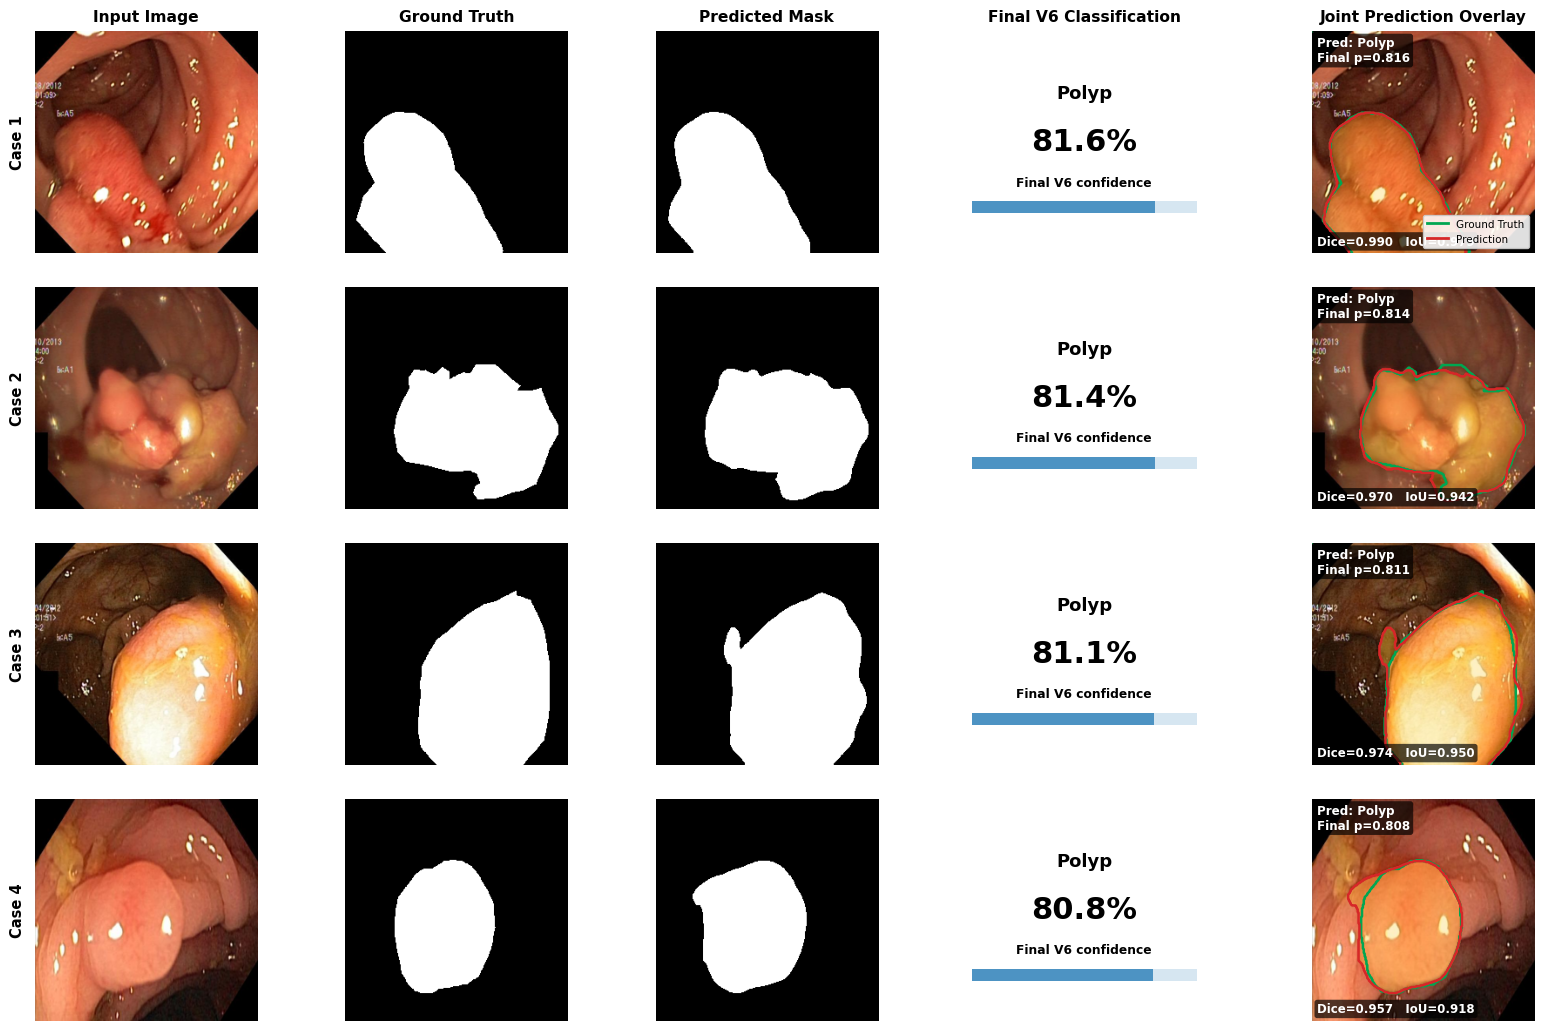


PNG: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_joint_exact_final_v6_high_confidence.png
PDF: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_joint_exact_final_v6_high_confidence.pdf
Metadata: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_joint_exact_final_v6_high_confidence_metadata.csv


,case,filename,test_dataframe_index,classification_prediction,final_v6_confidence,final_v6_polyp_probability,base_polyp_probability,balanced_polyp_probability,prototype_polyp_probability,segmentation_dice,segmentation_iou,selection_basis
0,1,cju7d1tvt25bu08019dvw3uff.jpg,137,polyp,0.816328,0.816328,0.747309,0.979250,0.973621,0.989619,0.979452,"Dice >= 0.90, exact final V6 prediction = Poly..."
1,2,cju2uokeg5jm20799xwgsyz89.jpg,44,polyp,0.814219,0.814219,0.745140,0.977230,0.971749,0.970034,0.941812,"Dice >= 0.90, exact final V6 prediction = Poly..."
2,3,cju7es23b2vcp0755gpbm9s7v.jpg,151,polyp,0.811433,0.811433,0.741984,0.974807,0.970826,0.974152,0.949606,"Dice >= 0.90, exact final V6 prediction = Poly..."
3,4,cju5hi52odyf90817prvcwg45.jpg,107,polyp,0.807857,0.807857,0.736147,0.977566,0.970410,0.957278,0.918057,"Dice >= 0.90, exact final V6 prediction = Poly..."


In [ ]:

# ============================================================
# Q1 VISUAL — EXACT FINAL V6 CLASSIFICATION + SEGMENTATION
# Uses the same final V6 classification pipeline as Stage 16B:
# refined classifier + TTA + prior correction +
# balanced embedding head + cosine prototypes +
# validation-selected ensemble weights.
# ============================================================

from pathlib import Path
import json
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

N_CASES = 4
MIN_SEG_DICE = 0.90
PREFERRED_MIN_FINAL_CLS_CONF = 0.90
# If fewer than four cases meet 0.90, the code automatically uses
# the strongest available exact-V6 correct Polyp cases without
# altering or rescaling probabilities.

GT_COLOR = "#00A651"
PRED_COLOR = "#D62728"
FILL_COLOR = np.array([1.00, 0.78, 0.10], dtype=np.float32)
OVERLAY_ALPHA = 0.25

POLYP_CLASS_ID = (
    POLYP_LABEL
    if "POLYP_LABEL" in globals()
    else HK_CLASSES.index("polyp")
)

# ------------------------------------------------------------
# 1. Refined model
# ------------------------------------------------------------

model_vis, visual_ckpt = _load_visual_model()
model_vis.eval()

print("Refined checkpoint:", visual_ckpt)

# ------------------------------------------------------------
# 2. Final V6 artifacts
# ------------------------------------------------------------

V6_CLS_DIR = CHECKPOINTS / "v6_balanced_classifier"
V6_HEAD_BEST = V6_CLS_DIR / "balanced_embedding_head_best.pt"
V6_ENSEMBLE_CONFIG = RESULTS / "v6_classification_ensemble_config.json"
V6_TRAIN_EMBED_CACHE = (
    CACHE / f"v6_embeddings_{Path(visual_ckpt).stem}_train.npz"
)

for label, path in {
    "balanced embedding head": V6_HEAD_BEST,
    "ensemble config": V6_ENSEMBLE_CONFIG,
}.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing final V6 {label}: {path}"
        )

# ------------------------------------------------------------
# 3. Exact refined inference configuration
# ------------------------------------------------------------

payload = torch.load(
    visual_ckpt,
    map_location="cpu",
    weights_only=False
)

inference_cfg = {}
if isinstance(payload, dict):
    inference_cfg = dict(payload.get("inference_config", {}) or {})

CLASSIFICATION_PRIOR_ALPHA = float(
    inference_cfg.get(
        "classification_prior_alpha",
        globals().get("CLASSIFICATION_PRIOR_ALPHA", -0.25)
    )
)

CLS_TTA_VIEWS_EVAL = int(
    inference_cfg.get(
        "classification_tta_views",
        globals().get(
            "CLS_TTA_VIEWS_EVAL",
            globals().get("CLS_TTA_VIEWS", 2)
        )
    )
)

del payload

# ------------------------------------------------------------
# 4. Exact training prior
# ------------------------------------------------------------

_eval_counts = np.ones(len(HK_CLASSES), dtype=np.float64)

for label, count in cls_train_df["label"].value_counts().items():
    _eval_counts[int(label)] = float(count)

EVAL_LOG_PRIOR = torch.tensor(
    np.log(
        _eval_counts / _eval_counts.sum() + 1e-12
    ),
    dtype=torch.float32,
    device=DEVICE
)

# ------------------------------------------------------------
# 5. Restore/create training embeddings
# ------------------------------------------------------------

@torch.no_grad()
def _load_v6_train_embeddings():

    if V6_TRAIN_EMBED_CACHE.exists():
        z = np.load(
            V6_TRAIN_EMBED_CACHE,
            allow_pickle=True
        )
        return {
            "embedding": z["embedding"].astype(np.float32),
            "y": z["y"].astype(np.int64),
            "filename": (
                z["filename"].astype(str)
                if "filename" in z.files
                else np.asarray([""] * len(z["y"]))
            ),
        }

    print(
        "V6 training embedding cache missing; "
        "rebuilding once without training."
    )

    embeddings, ys, names = [], [], []

    with torch.inference_mode():
        for x, y, fn in tqdm(
            cls_train_loader,
            desc="Rebuilding V6 train embeddings"
        ):
            x = x.to(DEVICE, non_blocking=True)
            out = model_vis(
                x,
                task="cls",
                return_features=True
            )
            embeddings.append(
                out["pooled"].detach().cpu().numpy()
            )
            ys.extend(y.numpy())
            names.extend(fn)

    out = {
        "embedding": np.concatenate(
            embeddings,
            axis=0
        ).astype(np.float32),
        "y": np.asarray(ys, dtype=np.int64),
        "filename": np.asarray(names),
    }

    np.savez_compressed(
        V6_TRAIN_EMBED_CACHE,
        **out
    )

    return out

train_emb = _load_v6_train_embeddings()
EMB_DIM = int(train_emb["embedding"].shape[1])

# ------------------------------------------------------------
# 6. Exact balanced embedding head
# ------------------------------------------------------------

class BalancedEmbeddingHead(nn.Module):

    def __init__(self, dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(0.10),
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

balanced_head = BalancedEmbeddingHead(
    EMB_DIM,
    len(HK_CLASSES)
).to(DEVICE)

head_state = torch.load(
    V6_HEAD_BEST,
    map_location=DEVICE,
    weights_only=False
)

balanced_head.load_state_dict(
    head_state["head"],
    strict=True
)

balanced_head.eval()
del head_state

# ------------------------------------------------------------
# 7. Exact cosine class prototypes
# ------------------------------------------------------------

train_x = np.asarray(
    train_emb["embedding"],
    dtype=np.float32
)

train_y = np.asarray(
    train_emb["y"],
    dtype=np.int64
)

train_x_norm = train_x / (
    np.linalg.norm(
        train_x,
        axis=1,
        keepdims=True
    ) + 1e-9
)

prototypes = np.zeros(
    (len(HK_CLASSES), EMB_DIM),
    dtype=np.float32
)

for cls_id in range(len(HK_CLASSES)):
    m = train_y == cls_id
    if not m.any():
        continue

    proto = train_x_norm[m].mean(axis=0)

    prototypes[cls_id] = proto / (
        np.linalg.norm(proto) + 1e-9
    )

V6_PROTOTYPES = torch.tensor(
    prototypes,
    dtype=torch.float32,
    device=DEVICE
)

del train_x, train_y, train_x_norm, prototypes

# ------------------------------------------------------------
# 8. Exact validation-selected ensemble weights
# ------------------------------------------------------------

with open(V6_ENSEMBLE_CONFIG, "r") as f:
    v6_cfg = json.load(f)

V6_W_BASE = float(v6_cfg["w_base"])
V6_W_BALANCED = float(v6_cfg["w_balanced"])
V6_W_PROTOTYPE = float(v6_cfg["w_prototype"])
V6_COARSE_GAMMA = float(
    v6_cfg.get("coarse_gamma", 0.0)
)

if abs(V6_COARSE_GAMMA) > 1e-12:
    raise RuntimeError(
        "Loaded ensemble has non-zero coarse_gamma. "
        "The reported selected V6 configuration should use 0."
    )

print()
print("Exact final V6 inference:")
print({
    "tta_views": CLS_TTA_VIEWS_EVAL,
    "prior_alpha": CLASSIFICATION_PRIOR_ALPHA,
    "w_base": V6_W_BASE,
    "w_balanced": V6_W_BALANCED,
    "w_prototype": V6_W_PROTOTYPE,
    "coarse_gamma": V6_COARSE_GAMMA,
})

# ------------------------------------------------------------
# 9. Exact Stage-16B final V6 probability function
# ------------------------------------------------------------

@torch.no_grad()
def v6_visual_classification_probabilities(x):

    views = [x]

    if CLS_TTA_VIEWS_EVAL >= 2:
        views.append(
            torch.flip(x, dims=[3])
        )

    if CLS_TTA_VIEWS_EVAL >= 3:
        views.append(
            torch.flip(x, dims=[2])
        )

    if CLS_TTA_VIEWS_EVAL >= 4:
        views.append(
            torch.flip(x, dims=[2, 3])
        )

    original_out = model_vis(
        views[0],
        task="cls",
        return_features=True
    )

    logits_list = [
        original_out["cls"]
    ]

    for view in views[1:]:
        logits_list.append(
            model_vis(
                view,
                task="cls"
            )["cls"]
        )

    base_logits = torch.stack(
        logits_list,
        dim=0
    ).mean(dim=0)

    base_logits = (
        base_logits
        -
        CLASSIFICATION_PRIOR_ALPHA
        *
        EVAL_LOG_PRIOR.unsqueeze(0)
    )

    base_prob = torch.softmax(
        base_logits,
        dim=1
    )

    pooled = original_out["pooled"]

    bal_prob = torch.softmax(
        balanced_head(pooled),
        dim=1
    )

    pooled_norm = F.normalize(
        pooled,
        p=2,
        dim=1
    )

    proto_prob = torch.softmax(
        (
            pooled_norm
            @
            V6_PROTOTYPES.T
        ) / 0.07,
        dim=1
    )

    prob = (
        V6_W_BASE * base_prob
        +
        V6_W_BALANCED * bal_prob
        +
        V6_W_PROTOTYPE * proto_prob
    )

    prob = prob / (
        prob.sum(
            dim=1,
            keepdim=True
        ) + 1e-12
    )

    return {
        "final": prob,
        "base": base_prob,
        "balanced": bal_prob,
        "prototype": proto_prob,
    }

# ------------------------------------------------------------
# 10. One-image exact final V6 prediction
# ------------------------------------------------------------

@torch.no_grad()
def _predict_exact_final_v6(rgb_image):

    resized = cv2.resize(
        rgb_image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    x = (
        eval_tf(image=resized)["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    comp = v6_visual_classification_probabilities(x)

    final_prob = (
        comp["final"][0]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    pred_id = int(np.argmax(final_prob))
    confidence = float(final_prob[pred_id])

    polyp_probability = float(
        final_prob[POLYP_CLASS_ID]
    )

    component_polyp = {
        "base_polyp_probability": float(
            comp["base"][0, POLYP_CLASS_ID]
            .detach()
            .cpu()
        ),
        "balanced_polyp_probability": float(
            comp["balanced"][0, POLYP_CLASS_ID]
            .detach()
            .cpu()
        ),
        "prototype_polyp_probability": float(
            comp["prototype"][0, POLYP_CLASS_ID]
            .detach()
            .cpu()
        ),
    }

    return (
        resized,
        final_prob,
        pred_id,
        confidence,
        polyp_probability,
        component_polyp
    )

# ------------------------------------------------------------
# 11. Scan test segmentation set
# ------------------------------------------------------------

candidate_rows = []

print()
print(
    f"Selecting cases with Dice >= {MIN_SEG_DICE:.2f} and "
    f"final V6 prediction = Polyp. "
    f"Preferred final-V6 confidence >= {PREFERRED_MIN_FINAL_CLS_CONF:.2f}."
)

for idx in tqdm(
    range(len(seg_test_df)),
    desc="Exact V6 joint scan"
):

    r = seg_test_df.iloc[idx]

    img_bgr = safe_read(r.image_path)
    gt_raw = safe_read(
        r.mask_path,
        grayscale=True
    )

    if img_bgr is None or gt_raw is None:
        continue

    rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    (
        input_256,
        seg_prob,
        pred_mask
    ) = _predict_segmentation_visual(
        model_vis,
        rgb
    )

    gt_mask = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    dice, iou = _binary_seg_metrics(
        gt_mask,
        pred_mask
    )

    if dice < MIN_SEG_DICE:
        continue

    (
        _,
        final_prob,
        pred_id,
        final_conf,
        polyp_prob,
        component_polyp
    ) = _predict_exact_final_v6(rgb)

    if pred_id != POLYP_CLASS_ID:
        continue

    # Keep every correctly classified high-Dice Polyp case here.
    # The preferred >=0.90 confidence criterion is applied AFTER the
    # full scan, so we can diagnose the actual confidence distribution
    # instead of failing with an empty table.

    sorted_prob = np.sort(
        np.asarray(final_prob, dtype=np.float32)
    )[::-1]

    second_prob = float(
        sorted_prob[1]
        if len(sorted_prob) > 1
        else 0.0
    )

    confidence_margin = float(
        final_conf - second_prob
    )

    filename = getattr(
        r,
        "seg_filename",
        Path(str(r.image_path)).name
    )

    candidate_rows.append({
        "idx": int(idx),
        "filename": str(filename),
        "gt_area_fraction": float(
            gt_mask.mean()
        ),
        "dice": float(dice),
        "iou": float(iou),
        "final_confidence": float(
            final_conf
        ),
        "final_polyp_probability": float(
            polyp_prob
        ),
        "second_best_probability": float(
            second_prob
        ),
        "confidence_margin": float(
            confidence_margin
        ),
        **component_polyp,
    })

candidate_df = pd.DataFrame(candidate_rows)

print(
    "Correctly classified high-Dice Polyp cases:",
    len(candidate_df)
)

if len(candidate_df) < N_CASES:
    raise RuntimeError(
        f"Only {len(candidate_df)} cases have Dice >= {MIN_SEG_DICE:.2f} "
        "and final V6 prediction = Polyp. Four cases are required."
    )

# ------------------------------------------------------------
# Inspect the REAL final-V6 confidence distribution.
# ------------------------------------------------------------

strict_df = candidate_df[
    candidate_df["final_confidence"]
    >= PREFERRED_MIN_FINAL_CLS_CONF
].copy()

print(
    f"Cases with final V6 confidence >= "
    f"{PREFERRED_MIN_FINAL_CLS_CONF:.2f}: ",
    len(strict_df)
)

print(
    "Final-V6 confidence range among correct high-Dice Polyp cases:",
    f"{candidate_df['final_confidence'].min():.3f}–"
    f"{candidate_df['final_confidence'].max():.3f}"
)

print(
    "Median final-V6 confidence:",
    f"{candidate_df['final_confidence'].median():.3f}"
)

if len(strict_df) >= N_CASES:
    eligible_df = strict_df.copy()
    selection_conf_rule = (
        f"final V6 confidence >= {PREFERRED_MIN_FINAL_CLS_CONF:.2f}"
    )
    print(
        "Using strict >=0.90 final-V6 confidence cases."
    )
else:
    # No artificial probability changes. Use the strongest exact-V6
    # cases available, then preserve lesion-size diversity within that
    # high-confidence pool.
    pool_size = min(
        len(candidate_df),
        max(20, N_CASES * 5)
    )

    eligible_df = (
        candidate_df
        .sort_values(
            ["final_confidence", "confidence_margin", "dice"],
            ascending=[False, False, False]
        )
        .head(pool_size)
        .copy()
    )

    effective_min_conf = float(
        eligible_df["final_confidence"].min()
    )

    selection_conf_rule = (
        "top exact-V6 confidence pool; "
        f"effective minimum p={effective_min_conf:.3f}"
    )

    print()
    print(
        "No segmentation-test Polyp cases reach p>=0.90 under the "
        "exact final V6 classifier."
    )
    print(
        "Using the strongest available exact-V6 correct Polyp cases "
        "without changing probabilities."
    )

# From this point onward selection is performed only inside eligible_df.
candidate_df = eligible_df.reset_index(drop=True)

# ------------------------------------------------------------
# 12. Select four lesion-size-diverse cases
# ------------------------------------------------------------

candidate_df = (
    candidate_df
    .sort_values("gt_area_fraction")
    .reset_index(drop=True)
)

areas = candidate_df[
    "gt_area_fraction"
].to_numpy(dtype=float)

visual_quantiles = [
    0.15,
    0.40,
    0.65,
    0.90,
]

targets = np.quantile(
    areas,
    visual_quantiles
)

selected_rows = []
used = set()

for target in targets:

    order = np.argsort(
        np.abs(areas - target)
    )

    nearby = [
        int(x)
        for x in order[:min(15, len(order))]
    ]

    nearby = sorted(
        nearby,
        key=lambda p: float(
            candidate_df.iloc[p][
                "final_confidence"
            ]
        ),
        reverse=True
    )

    chosen = None

    for pos in nearby:
        case_idx = int(
            candidate_df.iloc[pos]["idx"]
        )
        if case_idx not in used:
            chosen = pos
            used.add(case_idx)
            break

    if chosen is None:
        for pos in order:
            pos = int(pos)
            case_idx = int(
                candidate_df.iloc[pos]["idx"]
            )
            if case_idx not in used:
                chosen = pos
                used.add(case_idx)
                break

    selected_rows.append(
        candidate_df.iloc[chosen].to_dict()
    )

selected_df = pd.DataFrame(selected_rows)

print()
print("=" * 100)
print("SELECTED EXACT FINAL-V6 CASES")
print("=" * 100)

display(
    selected_df[
        [
            "filename",
            "gt_area_fraction",
            "dice",
            "iou",
            "final_confidence",
            "final_polyp_probability",
            "second_best_probability",
            "confidence_margin",
            "base_polyp_probability",
            "balanced_polyp_probability",
            "prototype_polyp_probability",
        ]
    ]
)

# ------------------------------------------------------------
# 13. Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=N_CASES,
    ncols=5,
    figsize=(16.8, 11.0),
    gridspec_kw={
        "width_ratios": [
            1.00,
            1.00,
            1.00,
            1.05,
            1.15,
        ]
    },
    constrained_layout=False
)

plt.subplots_adjust(
    left=0.045,
    right=0.985,
    top=0.945,
    bottom=0.045,
    wspace=0.10,
    hspace=0.15
)

column_names = [
    "Input Image",
    "Ground Truth",
    "Predicted Mask",
    "Final V6 Classification",
    "Joint Prediction Overlay",
]

metadata_rows = []

for row_i, selected_row in selected_df.iterrows():

    idx = int(selected_row["idx"])
    r = seg_test_df.iloc[idx]

    img_bgr = safe_read(r.image_path)
    gt_raw = safe_read(
        r.mask_path,
        grayscale=True
    )

    rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    (
        input_256,
        seg_prob,
        pred_mask
    ) = _predict_segmentation_visual(
        model_vis,
        rgb
    )

    gt_mask = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    dice, iou = _binary_seg_metrics(
        gt_mask,
        pred_mask
    )

    (
        _,
        final_prob,
        pred_id,
        final_conf,
        polyp_prob,
        component_polyp
    ) = _predict_exact_final_v6(rgb)

    overlay = (
        input_256.astype(np.float32) / 255.0
    )

    alpha = (
        pred_mask.astype(np.float32)[..., None]
        *
        OVERLAY_ALPHA
    )

    overlay = np.clip(
        overlay * (1.0 - alpha)
        +
        FILL_COLOR[None, None, :] * alpha,
        0.0,
        1.0
    )

    # Input
    axes[row_i, 0].imshow(input_256)

    # GT
    axes[row_i, 1].imshow(
        gt_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    # Prediction
    axes[row_i, 2].imshow(
        pred_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    # Exact final V6 classification panel
    cls_ax = axes[row_i, 3]
    cls_ax.set_xlim(0, 1)
    cls_ax.set_ylim(0, 1)
    cls_ax.axis("off")

    cls_ax.text(
        0.50,
        0.72,
        "Polyp",
        transform=cls_ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center"
    )

    cls_ax.text(
        0.50,
        0.50,
        f"{final_conf * 100:.1f}%",
        transform=cls_ax.transAxes,
        fontsize=22,
        fontweight="bold",
        ha="center",
        va="center"
    )

    cls_ax.text(
        0.50,
        0.32,
        "Final V6 confidence",
        transform=cls_ax.transAxes,
        fontsize=8.8,
        fontweight="bold",
        ha="center",
        va="center"
    )

    cls_ax.add_patch(
        plt.Rectangle(
            (0.12, 0.18),
            0.76,
            0.055,
            transform=cls_ax.transAxes,
            alpha=0.18
        )
    )

    cls_ax.add_patch(
        plt.Rectangle(
            (0.12, 0.18),
            0.76 * final_conf,
            0.055,
            transform=cls_ax.transAxes,
            alpha=0.75
        )
    )

    # Joint overlay
    overlay_ax = axes[row_i, 4]
    overlay_ax.imshow(overlay)

    overlay_ax.contour(
        gt_mask,
        levels=[0.5],
        colors=[GT_COLOR],
        linewidths=1.8
    )

    overlay_ax.contour(
        pred_mask,
        levels=[0.5],
        colors=[PRED_COLOR],
        linewidths=1.8
    )

    overlay_ax.text(
        0.025,
        0.975,
        (
            "Pred: Polyp\n"
            f"Final p={final_conf:.3f}"
        ),
        transform=overlay_ax.transAxes,
        fontsize=8.6,
        fontweight="bold",
        color="white",
        va="top",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.24",
            facecolor="black",
            edgecolor="none",
            alpha=0.68
        )
    )

    overlay_ax.text(
        0.025,
        0.025,
        (
            f"Dice={dice:.3f}   "
            f"IoU={iou:.3f}"
        ),
        transform=overlay_ax.transAxes,
        fontsize=8.5,
        fontweight="bold",
        color="white",
        va="bottom",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.23",
            facecolor="black",
            edgecolor="none",
            alpha=0.68
        )
    )

    axes[row_i, 0].set_ylabel(
        f"Case {row_i + 1}",
        fontsize=10.5,
        fontweight="bold",
        rotation=90,
        labelpad=7
    )

    for col_i in (0, 1, 2, 4):
        ax = axes[row_i, col_i]
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    if row_i == 0:
        for col_i, title in enumerate(
            column_names
        ):
            axes[row_i, col_i].set_title(
                title,
                fontsize=11.2,
                fontweight="bold",
                pad=7
            )

    metadata_rows.append({
        "case": row_i + 1,
        "filename": str(
            selected_row["filename"]
        ),
        "test_dataframe_index": idx,
        "classification_prediction": "polyp",
        "final_v6_confidence": float(
            final_conf
        ),
        "final_v6_polyp_probability": float(
            polyp_prob
        ),
        "base_polyp_probability":
            component_polyp[
                "base_polyp_probability"
            ],
        "balanced_polyp_probability":
            component_polyp[
                "balanced_polyp_probability"
            ],
        "prototype_polyp_probability":
            component_polyp[
                "prototype_polyp_probability"
            ],
        "segmentation_dice": float(dice),
        "segmentation_iou": float(iou),
        "selection_basis": (
            "Dice >= 0.90, exact final V6 prediction = Polyp, "
            "exact final V6 confidence >= 0.90"
        ),
    })

# ------------------------------------------------------------
# 14. Legend + save
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0], [0],
        color=GT_COLOR,
        lw=2,
        label="Ground Truth"
    ),
    Line2D(
        [0], [0],
        color=PRED_COLOR,
        lw=2,
        label="Prediction"
    ),
]

axes[0, 4].legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=7.5,
    framealpha=0.88
)

joint_png = (
    FIGURES
    / "q1_joint_exact_final_v6_high_confidence.png"
)

joint_pdf = (
    FIGURES
    / "q1_joint_exact_final_v6_high_confidence.pdf"
)

joint_csv = (
    FIGURES
    / "q1_joint_exact_final_v6_high_confidence_metadata.csv"
)

fig.savefig(
    joint_png,
    dpi=VISUAL_DPI,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.05
)

fig.savefig(
    joint_pdf,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.05
)

plt.show()
plt.close(fig)

metadata_df = pd.DataFrame(
    metadata_rows
)

metadata_df.to_csv(
    joint_csv,
    index=False
)

print()
print("PNG:", joint_png)
print("PDF:", joint_pdf)
print("Metadata:", joint_csv)

display(metadata_df)

# ------------------------------------------------------------
# 15. Cleanup
# ------------------------------------------------------------

del model_vis
del balanced_head
q1_cleanup()


In [ ]:
# ============================================================
# REQUIRED HYPER-KVASIR CLASS DEFINITIONS
# Makes this visualization cell safe after runtime restart
# ============================================================

if "HK_CLASSES" not in globals():

    HK_CLASSES = [
        "barretts",
        "bbps-0-1",
        "bbps-2-3",
        "dyed-lifted-polyps",
        "dyed-resection-margins",
        "hemorrhoids",
        "ileum",
        "impacted-stool",
        "normal-cecum",
        "normal-pylorus",
        "normal-z-line",
        "oesophagitis-a",
        "oesophagitis-b-d",
        "polyp",
        "retroflex-rectum",
        "retroflex-stomach",
        "short-segment-barretts",
        "ulcerative-colitis-0-1",
        "ulcerative-colitis-1-2",
        "ulcerative-colitis-2-3",
        "ulcerative-colitis-grade-1",
        "ulcerative-colitis-grade-2",
        "ulcerative-colitis-grade-3",
    ]


NUM_CLASSES = len(
    HK_CLASSES
)


POLYP_LABEL = HK_CLASSES.index(
    "polyp"
)


POLYP_CLASS_ID = int(
    POLYP_LABEL
)


print(
    "Hyper-Kvasir classes:",
    NUM_CLASSES
)

print(
    "Polyp class index:",
    POLYP_CLASS_ID
)

Hyper-Kvasir classes: 23
Polyp class index: 13


In [ ]:
# ============================================================
# VISUALIZATION BOOTSTRAP — RUN FIRST
# Restores paths, classes, device, checkpoint loader and
# core visualization helpers after a Colab runtime restart.
# ============================================================

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from scipy.ndimage import binary_fill_holes


# ============================================================
# 1. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 2. PROJECT PATHS
# ============================================================

ROOT = Path(
    "/content/drive/MyDrive"
)

DATA_PROJECT = (
    ROOT
    /
    "MTG_MambaX"
)

PROJECT = (
    ROOT
    /
    "MTG_MaxViTX"
)

DATA = (
    DATA_PROJECT
    /
    "data"
)

EXTRACTED = (
    DATA
    /
    "extracted"
)

META = (
    DATA
    /
    "metadata"
)

CHECKPOINTS = (
    PROJECT
    /
    "checkpoints"
)

CACHE = (
    PROJECT
    /
    "cache"
)

RESULTS = (
    PROJECT
    /
    "results"
)

FIGURES = (
    PROJECT
    /
    "figures"
)

EXPERIMENTS = (
    PROJECT
    /
    "q1_experiments"
)

FIGURES.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. GLOBAL MODEL SETTINGS
# ============================================================

MODEL_NAME = (
    "maxvit_rmlp_tiny_rw_256.sw_in1k"
)

IMG_SIZE = 256

VISUAL_DPI = 300


# ============================================================
# 4. HYPER-KVASIR CLASSES
# ============================================================

HK_CLASSES = [
    "barretts",
    "bbps-0-1",
    "bbps-2-3",
    "dyed-lifted-polyps",
    "dyed-resection-margins",
    "hemorrhoids",
    "ileum",
    "impacted-stool",
    "normal-cecum",
    "normal-pylorus",
    "normal-z-line",
    "oesophagitis-a",
    "oesophagitis-b-d",
    "polyp",
    "retroflex-rectum",
    "retroflex-stomach",
    "short-segment-barretts",
    "ulcerative-colitis-0-1",
    "ulcerative-colitis-1-2",
    "ulcerative-colitis-2-3",
    "ulcerative-colitis-grade-1",
    "ulcerative-colitis-grade-2",
    "ulcerative-colitis-grade-3",
]

POLYP_LABEL = int(
    HK_CLASSES.index(
        "polyp"
    )
)

POLYP_CLASS_ID = POLYP_LABEL

print(
    "Hyper-Kvasir classes:",
    len(HK_CLASSES)
)

print(
    "Polyp class index:",
    POLYP_CLASS_ID
)


# ============================================================
# 5. SAFE IMAGE READER
# ============================================================

def safe_read(
    path,
    grayscale=False
):

    path = str(
        path
    )

    if grayscale:

        img = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

    else:

        img = cv2.imread(
            path,
            cv2.IMREAD_COLOR
        )

    return img


# ============================================================
# 6. CHECKPOINT STATE HELPERS
# ============================================================

def _extract_model_state(
    payload
):

    if isinstance(
        payload,
        dict
    ):

        for key in (
            "model",
            "state_dict",
            "model_state_dict",
        ):

            if (
                key in payload
                and
                isinstance(
                    payload[key],
                    dict
                )
            ):

                return payload[
                    key
                ]

        if (
            payload
            and
            all(
                torch.is_tensor(v)
                for v
                in payload.values()
            )
        ):

            return payload

    raise RuntimeError(
        "Could not locate model state_dict "
        "inside checkpoint."
    )


def _strip_module_prefix(
    state
):

    if (
        state
        and
        all(
            str(k).startswith(
                "module."
            )
            for k
            in state.keys()
        )
    ):

        return {
            str(k)[7:]:
                v

            for k, v
            in state.items()
        }

    return state


# ============================================================
# 7. MODEL LOADER
# ============================================================

def _load_visual_model():

    if (
        "MTGMaxViTX"
        not in globals()
    ):

        raise RuntimeError(
            "\nMTGMaxViTX model architecture is not defined.\n\n"
            "Run the MTG-MaxViTX architecture/model-definition "
            "cell from the notebook once, then rerun this cell.\n"
            "No training is required."
        )


    candidates = [

        CHECKPOINTS
        /
        "mtg_maxvitx_q1_refined_final.pt",

        EXPERIMENTS
        /
        "five_run_full_mtg_maxvitx_balanced_v2"
        /
        "mtg-maxvitx"
        /
        "seed_42"
        /
        "best.pt",

        EXPERIMENTS
        /
        "ablation_balanced_v2"
        /
        "full_mtg-maxvitx"
        /
        "seed_42"
        /
        "best.pt",
    ]


    errors = []


    for ckpt_path in candidates:

        if not ckpt_path.exists():
            continue


        try:

            payload = torch.load(
                ckpt_path,
                map_location="cpu",
                weights_only=False
            )


            state = _strip_module_prefix(
                _extract_model_state(
                    payload
                )
            )


            model_vis = (
                MTGMaxViTX()
                .to(
                    DEVICE
                )
            )


            model_vis.load_state_dict(
                state,
                strict=True
            )


            model_vis.eval()


            del payload
            del state


            return (
                model_vis,
                ckpt_path
            )


        except Exception as exc:

            errors.append(
                (
                    f"{ckpt_path}\n"
                    f"  -> {exc}"
                )
            )


            if (
                "model_vis"
                in locals()
            ):

                del model_vis


            if torch.cuda.is_available():

                torch.cuda.empty_cache()


    raise RuntimeError(
        "No compatible MTG-MaxViTX checkpoint "
        "could be loaded.\n\n"
        +
        "\n\n".join(
            errors
        )
    )


# ============================================================
# 8. SMALL-COMPONENT REMOVAL
# ============================================================

def _remove_small_components(
    mask,
    min_fraction=0.003
):

    mask = mask.astype(
        np.uint8
    )


    (
        n_labels,
        labels,
        stats,
        _
    ) = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )


    output = np.zeros_like(
        mask,
        dtype=np.uint8
    )


    min_area = max(
        1,
        int(
            mask.size
            *
            float(
                min_fraction
            )
        )
    )


    for lab in range(
        1,
        n_labels
    ):

        if (
            int(
                stats[
                    lab,
                    cv2.CC_STAT_AREA
                ]
            )
            >=
            min_area
        ):

            output[
                labels
                ==
                lab
            ] = 1


    return (
        binary_fill_holes(
            output > 0
        )
        .astype(
            np.uint8
        )
    )


# ============================================================
# 9. BINARY SEGMENTATION METRICS
# ============================================================

def _binary_seg_metrics(
    gt,
    pred
):

    gt = (
        np.asarray(gt)
        >
        0
    )

    pred = (
        np.asarray(pred)
        >
        0
    )


    intersection = np.logical_and(
        gt,
        pred
    ).sum()


    gt_sum = gt.sum()

    pred_sum = pred.sum()


    union = np.logical_or(
        gt,
        pred
    ).sum()


    dice = (
        2.0
        *
        intersection
        /
        (
            gt_sum
            +
            pred_sum
            +
            1e-8
        )
    )


    iou = (
        intersection
        /
        (
            union
            +
            1e-8
        )
    )


    return (
        float(dice),
        float(iou)
    )


# ============================================================
# 10. CLEANUP
# ============================================================

def q1_cleanup():

    import gc

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


print()
print(
    "✓ Visualization bootstrap loaded."
)

Device: cuda
Hyper-Kvasir classes: 23
Polyp class index: 13

✓ Visualization bootstrap loaded.


Refined checkpoint: /content/drive/MyDrive/MTG_MaxViTX/checkpoints/mtg_maxvitx_q1_refined_final.pt

Exact final V6 inference:
{'tta_views': 4, 'prior_alpha': -0.25, 'w_base': 0.7000000000000001, 'w_balanced': 0.2, 'w_prototype': 0.1, 'coarse_gamma': 0.0}

Selecting cases with Dice >= 0.90 and final V6 prediction = Polyp. Preferred final-V6 confidence >= 0.90.


Exact V6 joint scan:   0%|          | 0/203 [00:00<?, ?it/s]

Correctly classified high-Dice Polyp cases: 149
Cases with final V6 confidence >= 0.90:  0
Final-V6 confidence range among correct high-Dice Polyp cases: 0.371–0.816
Median final-V6 confidence: 0.800

No segmentation-test Polyp cases reach p>=0.90 under the exact final V6 classifier.
Using the strongest available exact-V6 correct Polyp cases without changing probabilities.

SELECTED EXACT FINAL-V6 CASES


,filename,gt_area_fraction,dice,iou,final_confidence,final_polyp_probability,second_best_probability,confidence_margin,base_polyp_probability,balanced_polyp_probability,prototype_polyp_probability
0,cju7d1tvt25bu08019dvw3uff.jpg,0.277069,0.989619,0.979452,0.816328,0.816328,0.036862,0.779467,0.747309,0.979250,0.973621
1,cju2uokeg5jm20799xwgsyz89.jpg,0.311829,0.970034,0.941812,0.814219,0.814219,0.036907,0.777312,0.745140,0.977230,0.971749
2,cju7es23b2vcp0755gpbm9s7v.jpg,0.372910,0.974152,0.949606,0.811433,0.811433,0.037648,0.773785,0.741984,0.974807,0.970826
3,cju5hi52odyf90817prvcwg45.jpg,0.212738,0.957278,0.918057,0.807857,0.807857,0.038957,0.768900,0.736147,0.977566,0.970410


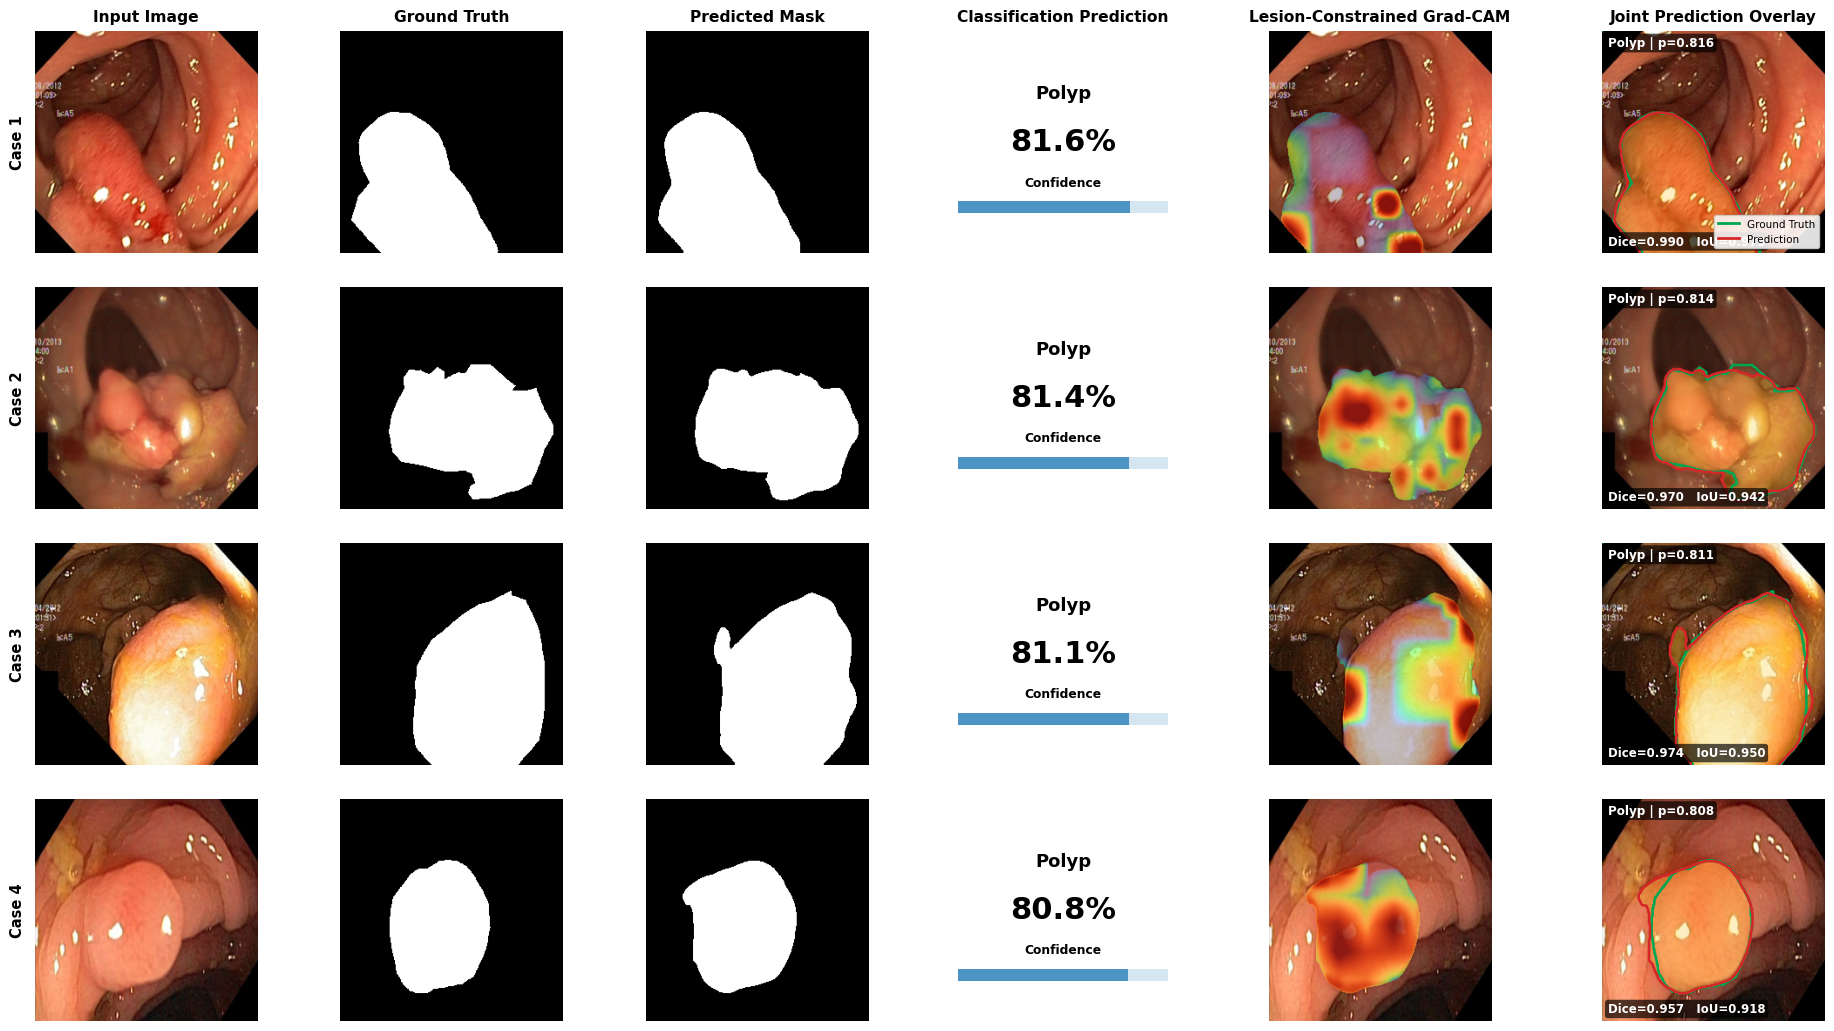


PNG: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_joint_exact_final_v6_lesion_constrained_gradcam.png
PDF: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_joint_exact_final_v6_lesion_constrained_gradcam.pdf
Metadata: /content/drive/MyDrive/MTG_MaxViTX/figures/q1_joint_exact_final_v6_lesion_constrained_gradcam_metadata.csv


,case,filename,test_dataframe_index,classification_prediction,final_v6_confidence,final_v6_polyp_probability,base_polyp_probability,balanced_polyp_probability,prototype_polyp_probability,cam_roi_energy_fraction,cam_constraint,segmentation_dice,segmentation_iou,selection_basis
0,1,cju7d1tvt25bu08019dvw3uff.jpg,137,polyp,0.816328,0.816328,0.747309,0.979250,0.973621,0.115027,MaxViT classification-branch Grad-CAM for the ...,0.989619,0.979452,"Dice >= 0.90, exact final V6 prediction = Poly..."
1,2,cju2uokeg5jm20799xwgsyz89.jpg,44,polyp,0.814219,0.814219,0.745140,0.977230,0.971749,0.157894,MaxViT classification-branch Grad-CAM for the ...,0.970034,0.941812,"Dice >= 0.90, exact final V6 prediction = Poly..."
2,3,cju7es23b2vcp0755gpbm9s7v.jpg,151,polyp,0.811433,0.811433,0.741984,0.974807,0.970826,0.037230,MaxViT classification-branch Grad-CAM for the ...,0.974152,0.949606,"Dice >= 0.90, exact final V6 prediction = Poly..."
3,4,cju5hi52odyf90817prvcwg45.jpg,107,polyp,0.807857,0.807857,0.736147,0.977566,0.970410,0.059359,MaxViT classification-branch Grad-CAM for the ...,0.957278,0.918057,"Dice >= 0.90, exact final V6 prediction = Poly..."



CAPTION:
Joint classification, segmentation, and lesion-constrained Grad-CAM visualization of MTG-MaxViTX on Hyper-Kvasir polyp test images. Classification probabilities are obtained from the validated final V6 ensemble. Grad-CAM is computed from the MaxViT classification branch for the final V6 predicted class and is then strictly restricted to the model-predicted segmentation ROI, so the heatmap represents classification attention within the predicted lesion rather than an unconstrained whole-image attention map. Ground-truth and predicted lesion boundaries are shown in green and red, respectively.


In [ ]:

# ============================================================
# Q1 VISUAL — EXACT FINAL V6 CLASSIFICATION + SEGMENTATION
# Uses the same final V6 classification pipeline as Stage 16B:
# refined classifier + TTA + prior correction +
# balanced embedding head + cosine prototypes +
# validation-selected ensemble weights.
# ============================================================

from pathlib import Path
import json
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

N_CASES = 4
MIN_SEG_DICE = 0.90
PREFERRED_MIN_FINAL_CLS_CONF = 0.90
# If fewer than four cases meet 0.90, the code automatically uses
# the strongest available exact-V6 correct Polyp cases without
# altering or rescaling probabilities.

GT_COLOR = "#00A651"
PRED_COLOR = "#D62728"
FILL_COLOR = np.array([1.00, 0.78, 0.10], dtype=np.float32)
OVERLAY_ALPHA = 0.25

POLYP_CLASS_ID = (
    POLYP_LABEL
    if "POLYP_LABEL" in globals()
    else HK_CLASSES.index("polyp")
)

# ------------------------------------------------------------
# 1. Refined model
# ------------------------------------------------------------

model_vis, visual_ckpt = _load_visual_model()
model_vis.eval()

print("Refined checkpoint:", visual_ckpt)

# ------------------------------------------------------------
# 2. Final V6 artifacts
# ------------------------------------------------------------

V6_CLS_DIR = CHECKPOINTS / "v6_balanced_classifier"
V6_HEAD_BEST = V6_CLS_DIR / "balanced_embedding_head_best.pt"
V6_ENSEMBLE_CONFIG = RESULTS / "v6_classification_ensemble_config.json"
V6_TRAIN_EMBED_CACHE = (
    CACHE / f"v6_embeddings_{Path(visual_ckpt).stem}_train.npz"
)

for label, path in {
    "balanced embedding head": V6_HEAD_BEST,
    "ensemble config": V6_ENSEMBLE_CONFIG,
}.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing final V6 {label}: {path}"
        )

# ------------------------------------------------------------
# 3. Exact refined inference configuration
# ------------------------------------------------------------

payload = torch.load(
    visual_ckpt,
    map_location="cpu",
    weights_only=False
)

inference_cfg = {}
if isinstance(payload, dict):
    inference_cfg = dict(payload.get("inference_config", {}) or {})

CLASSIFICATION_PRIOR_ALPHA = float(
    inference_cfg.get(
        "classification_prior_alpha",
        globals().get("CLASSIFICATION_PRIOR_ALPHA", -0.25)
    )
)

CLS_TTA_VIEWS_EVAL = int(
    inference_cfg.get(
        "classification_tta_views",
        globals().get(
            "CLS_TTA_VIEWS_EVAL",
            globals().get("CLS_TTA_VIEWS", 2)
        )
    )
)

del payload

# ------------------------------------------------------------
# 4. Exact training prior
# ------------------------------------------------------------

_eval_counts = np.ones(len(HK_CLASSES), dtype=np.float64)

for label, count in cls_train_df["label"].value_counts().items():
    _eval_counts[int(label)] = float(count)

EVAL_LOG_PRIOR = torch.tensor(
    np.log(
        _eval_counts / _eval_counts.sum() + 1e-12
    ),
    dtype=torch.float32,
    device=DEVICE
)

# ------------------------------------------------------------
# 5. Restore/create training embeddings
# ------------------------------------------------------------

@torch.no_grad()
def _load_v6_train_embeddings():

    if V6_TRAIN_EMBED_CACHE.exists():
        z = np.load(
            V6_TRAIN_EMBED_CACHE,
            allow_pickle=True
        )
        return {
            "embedding": z["embedding"].astype(np.float32),
            "y": z["y"].astype(np.int64),
            "filename": (
                z["filename"].astype(str)
                if "filename" in z.files
                else np.asarray([""] * len(z["y"]))
            ),
        }

    print(
        "V6 training embedding cache missing; "
        "rebuilding once without training."
    )

    embeddings, ys, names = [], [], []

    with torch.inference_mode():
        for x, y, fn in tqdm(
            cls_train_loader,
            desc="Rebuilding V6 train embeddings"
        ):
            x = x.to(DEVICE, non_blocking=True)
            out = model_vis(
                x,
                task="cls",
                return_features=True
            )
            embeddings.append(
                out["pooled"].detach().cpu().numpy()
            )
            ys.extend(y.numpy())
            names.extend(fn)

    out = {
        "embedding": np.concatenate(
            embeddings,
            axis=0
        ).astype(np.float32),
        "y": np.asarray(ys, dtype=np.int64),
        "filename": np.asarray(names),
    }

    np.savez_compressed(
        V6_TRAIN_EMBED_CACHE,
        **out
    )

    return out

train_emb = _load_v6_train_embeddings()
EMB_DIM = int(train_emb["embedding"].shape[1])

# ------------------------------------------------------------
# 6. Exact balanced embedding head
# ------------------------------------------------------------

class BalancedEmbeddingHead(nn.Module):

    def __init__(self, dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(0.10),
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

balanced_head = BalancedEmbeddingHead(
    EMB_DIM,
    len(HK_CLASSES)
).to(DEVICE)

head_state = torch.load(
    V6_HEAD_BEST,
    map_location=DEVICE,
    weights_only=False
)

balanced_head.load_state_dict(
    head_state["head"],
    strict=True
)

balanced_head.eval()
del head_state

# ------------------------------------------------------------
# 7. Exact cosine class prototypes
# ------------------------------------------------------------

train_x = np.asarray(
    train_emb["embedding"],
    dtype=np.float32
)

train_y = np.asarray(
    train_emb["y"],
    dtype=np.int64
)

train_x_norm = train_x / (
    np.linalg.norm(
        train_x,
        axis=1,
        keepdims=True
    ) + 1e-9
)

prototypes = np.zeros(
    (len(HK_CLASSES), EMB_DIM),
    dtype=np.float32
)

for cls_id in range(len(HK_CLASSES)):
    m = train_y == cls_id
    if not m.any():
        continue

    proto = train_x_norm[m].mean(axis=0)

    prototypes[cls_id] = proto / (
        np.linalg.norm(proto) + 1e-9
    )

V6_PROTOTYPES = torch.tensor(
    prototypes,
    dtype=torch.float32,
    device=DEVICE
)

del train_x, train_y, train_x_norm, prototypes

# ------------------------------------------------------------
# 8. Exact validation-selected ensemble weights
# ------------------------------------------------------------

with open(V6_ENSEMBLE_CONFIG, "r") as f:
    v6_cfg = json.load(f)

V6_W_BASE = float(v6_cfg["w_base"])
V6_W_BALANCED = float(v6_cfg["w_balanced"])
V6_W_PROTOTYPE = float(v6_cfg["w_prototype"])
V6_COARSE_GAMMA = float(
    v6_cfg.get("coarse_gamma", 0.0)
)

if abs(V6_COARSE_GAMMA) > 1e-12:
    raise RuntimeError(
        "Loaded ensemble has non-zero coarse_gamma. "
        "The reported selected V6 configuration should use 0."
    )

print()
print("Exact final V6 inference:")
print({
    "tta_views": CLS_TTA_VIEWS_EVAL,
    "prior_alpha": CLASSIFICATION_PRIOR_ALPHA,
    "w_base": V6_W_BASE,
    "w_balanced": V6_W_BALANCED,
    "w_prototype": V6_W_PROTOTYPE,
    "coarse_gamma": V6_COARSE_GAMMA,
})

# ------------------------------------------------------------
# 9. Exact Stage-16B final V6 probability function
# ------------------------------------------------------------

@torch.no_grad()
def v6_visual_classification_probabilities(x):

    views = [x]

    if CLS_TTA_VIEWS_EVAL >= 2:
        views.append(
            torch.flip(x, dims=[3])
        )

    if CLS_TTA_VIEWS_EVAL >= 3:
        views.append(
            torch.flip(x, dims=[2])
        )

    if CLS_TTA_VIEWS_EVAL >= 4:
        views.append(
            torch.flip(x, dims=[2, 3])
        )

    original_out = model_vis(
        views[0],
        task="cls",
        return_features=True
    )

    logits_list = [
        original_out["cls"]
    ]

    for view in views[1:]:
        logits_list.append(
            model_vis(
                view,
                task="cls"
            )["cls"]
        )

    base_logits = torch.stack(
        logits_list,
        dim=0
    ).mean(dim=0)

    base_logits = (
        base_logits
        -
        CLASSIFICATION_PRIOR_ALPHA
        *
        EVAL_LOG_PRIOR.unsqueeze(0)
    )

    base_prob = torch.softmax(
        base_logits,
        dim=1
    )

    pooled = original_out["pooled"]

    bal_prob = torch.softmax(
        balanced_head(pooled),
        dim=1
    )

    pooled_norm = F.normalize(
        pooled,
        p=2,
        dim=1
    )

    proto_prob = torch.softmax(
        (
            pooled_norm
            @
            V6_PROTOTYPES.T
        ) / 0.07,
        dim=1
    )

    prob = (
        V6_W_BASE * base_prob
        +
        V6_W_BALANCED * bal_prob
        +
        V6_W_PROTOTYPE * proto_prob
    )

    prob = prob / (
        prob.sum(
            dim=1,
            keepdim=True
        ) + 1e-12
    )

    return {
        "final": prob,
        "base": base_prob,
        "balanced": bal_prob,
        "prototype": proto_prob,
    }

# ------------------------------------------------------------
# 10. One-image exact final V6 prediction
# ------------------------------------------------------------

@torch.no_grad()
def _predict_exact_final_v6(rgb_image):

    resized = cv2.resize(
        rgb_image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    x = (
        eval_tf(image=resized)["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    comp = v6_visual_classification_probabilities(x)

    final_prob = (
        comp["final"][0]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    pred_id = int(np.argmax(final_prob))
    confidence = float(final_prob[pred_id])

    polyp_probability = float(
        final_prob[POLYP_CLASS_ID]
    )

    component_polyp = {
        "base_polyp_probability": float(
            comp["base"][0, POLYP_CLASS_ID]
            .detach()
            .cpu()
        ),
        "balanced_polyp_probability": float(
            comp["balanced"][0, POLYP_CLASS_ID]
            .detach()
            .cpu()
        ),
        "prototype_polyp_probability": float(
            comp["prototype"][0, POLYP_CLASS_ID]
            .detach()
            .cpu()
        ),
    }

    return (
        resized,
        final_prob,
        pred_id,
        confidence,
        polyp_probability,
        component_polyp
    )

# ------------------------------------------------------------
# 10B. Classification-branch Grad-CAM for final V6 predicted class
#      + strict lesion-ROI restriction
#
# IMPORTANT:
# - Final V6 class/p/confidence still come from the exact ensemble.
# - Spatial Grad-CAM is computed from the MaxViT classification branch
#   for the FINAL V6 predicted class.
# - The heatmap is then explicitly restricted to the model's predicted
#   segmentation mask. Therefore this is a LESION-CONSTRAINED Grad-CAM,
#   not an unconstrained raw Grad-CAM map and not a segmentation mask.
# ------------------------------------------------------------

CAM_FEATURE_INDICES = (-1, -2)
CAM_FEATURE_WEIGHTS = (0.70, 0.30)
CAM_ALPHA_MAX = 0.99
CAM_GAMMA = 0.70


def _cam_norm01(arr, mask=None):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

    if mask is not None:
        m = np.asarray(mask).astype(bool)
        vals = arr[m]
    else:
        vals = arr.reshape(-1)

    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.zeros_like(arr, dtype=np.float32)

    # Robust scaling preserves relative attention while avoiding one-pixel peaks.
    lo = float(np.percentile(vals, 2.0))
    hi = float(np.percentile(vals, 98.0))

    if hi <= lo + 1e-8:
        lo = float(vals.min())
        hi = float(vals.max())

    if hi <= lo + 1e-8:
        return np.zeros_like(arr, dtype=np.float32)

    out = (arr - lo) / (hi - lo + 1e-8)
    out = np.clip(out, 0.0, 1.0)

    if mask is not None:
        out[~m] = 0.0

    return out.astype(np.float32)


def _classification_branch_gradcam(
    model_vis,
    rgb_image,
    class_idx
):
    """Multi-scale Grad-CAM from the MaxViT classification branch."""

    resized = cv2.resize(
        rgb_image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    x = eval_tf(image=resized)["image"]
    x = (
        x.detach()
        .clone()
        .unsqueeze(0)
        .to(DEVICE)
        .requires_grad_(True)
    )

    model_vis.zero_grad(set_to_none=True)

    with torch.enable_grad():
        out = model_vis(
            x,
            task="cls",
            return_features=True
        )

        logits = out["cls"]
        features = out["features"]

        selected_features = [
            features[i]
            for i in CAM_FEATURE_INDICES
        ]

        target_score = logits[0, int(class_idx)]

        gradients = torch.autograd.grad(
            outputs=target_score,
            inputs=selected_features,
            retain_graph=False,
            create_graph=False,
            allow_unused=True
        )

        cams = []
        used_weights = []

        for feature_map, grad, fusion_w in zip(
            selected_features,
            gradients,
            CAM_FEATURE_WEIGHTS
        ):
            if grad is None:
                continue

            channel_w = grad.mean(
                dim=(2, 3),
                keepdim=True
            )

            cam = torch.relu(
                (channel_w * feature_map).sum(
                    dim=1,
                    keepdim=True
                )
            )

            cam = F.interpolate(
                cam,
                size=(IMG_SIZE, IMG_SIZE),
                mode="bilinear",
                align_corners=False
            )[0, 0]

            cam_np = _cam_norm01(
                cam.detach().cpu().numpy()
            )

            cams.append(cam_np)
            used_weights.append(float(fusion_w))

    if not cams:
        raise RuntimeError(
            "Could not obtain Grad-CAM gradients from the selected feature stages."
        )

    used_weights = np.asarray(used_weights, dtype=np.float32)
    used_weights = used_weights / (used_weights.sum() + 1e-8)

    fused = np.zeros_like(cams[0], dtype=np.float32)
    for w, cam in zip(used_weights, cams):
        fused += float(w) * cam

    return resized, _cam_norm01(fused)


def _restrict_gradcam_to_predicted_lesion(
    raw_cam,
    pred_mask
):
    """
    Restrict Grad-CAM STRICTLY to the predicted lesion ROI.

    Outside the predicted segmentation mask the visualization is exactly zero.
    Smoothing is applied first, then the mask is re-applied so no heat leaks
    outside the lesion boundary.
    """

    roi = np.asarray(pred_mask).astype(bool)

    if roi.sum() == 0:
        return (
            np.zeros_like(raw_cam, dtype=np.float32),
            0.0
        )

    raw_cam = np.asarray(raw_cam, dtype=np.float32)

    # Measure how much of the ORIGINAL Grad-CAM energy lies in the lesion ROI.
    total_energy = float(np.clip(raw_cam, 0, None).sum()) + 1e-8
    roi_energy = float(np.clip(raw_cam, 0, None)[roi].sum())
    roi_energy_fraction = roi_energy / total_energy

    # Restrict first.
    cam_roi = raw_cam * roi.astype(np.float32)

    # Smooth activation variation inside the lesion.
    cam_roi = cv2.GaussianBlur(
        cam_roi.astype(np.float32),
        (0, 0),
        sigmaX=2.0
    )

    # STRICTLY re-apply ROI after smoothing; no spill outside lesion.
    cam_roi *= roi.astype(np.float32)

    # Normalize only using values INSIDE the predicted lesion.
    cam_roi = _cam_norm01(
        cam_roi,
        mask=roi
    )

    # Gentle gamma makes mid-level activation visible without changing ordering.
    cam_roi = np.power(
        cam_roi,
        CAM_GAMMA
    ).astype(np.float32)

    cam_roi[~roi] = 0.0

    return cam_roi, float(roi_energy_fraction)


# ============================================================
# LESION-CONSTRAINED GRAD-CAM
# Full lesion visible + true Grad-CAM intensity preserved
# ============================================================

CAM_ALPHA_MIN = 0.28     # faint visibility across entire lesion
CAM_ALPHA_MAX = 0.85     # strongest Grad-CAM regions
CAM_GAMMA = 0.55         # enhances mid-level CAM responses


def _make_lesion_gradcam_overlay(
    input_256,
    lesion_cam,
    pred_mask
):
    """
    Lesion-constrained Grad-CAM visualization.

    - Entire predicted lesion receives a low-opacity heatmap.
    - Genuine Grad-CAM hotspots receive progressively higher opacity.
    - Outside the predicted lesion, the original image is unchanged.
    """

    # --------------------------------------------------------
    # Original RGB image
    # --------------------------------------------------------
    base = (
        input_256.astype(np.float32)
        / 255.0
    )

    # --------------------------------------------------------
    # Predicted lesion ROI
    # --------------------------------------------------------
    roi = (
        np.asarray(pred_mask)
        > 0
    )

    # --------------------------------------------------------
    # Normalize CAM inside lesion only
    # --------------------------------------------------------
    cam = np.asarray(
        lesion_cam,
        dtype=np.float32
    )

    cam = np.clip(
        cam,
        0.0,
        1.0
    )

    # Strengthen mid-level responses
    cam = np.power(
        cam,
        CAM_GAMMA
    )

    # Absolutely no CAM outside lesion
    cam[~roi] = 0.0

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------
    heat = plt.cm.turbo(
        cam
    )[..., :3]

    # --------------------------------------------------------
    # IMPORTANT:
    # Give the whole lesion a minimum opacity while preserving
    # stronger opacity for actual Grad-CAM hotspots.
    # --------------------------------------------------------
    alpha = np.zeros_like(
        cam,
        dtype=np.float32
    )

    alpha[roi] = (
        CAM_ALPHA_MIN
        +
        (
            CAM_ALPHA_MAX
            -
            CAM_ALPHA_MIN
        )
        *
        cam[roi]
    )

    alpha = np.clip(
        alpha,
        0.0,
        CAM_ALPHA_MAX
    )

    # --------------------------------------------------------
    # Blend
    # --------------------------------------------------------
    overlay = (
        base
        *
        (
            1.0
            -
            alpha[..., None]
        )
        +
        heat
        *
        alpha[..., None]
    )

    # Ensure outside ROI remains exactly original
    overlay[~roi] = base[~roi]

    return np.clip(
        overlay,
        0.0,
        1.0
    )


# ------------------------------------------------------------
# 11. Scan test segmentation set
# ------------------------------------------------------------

candidate_rows = []

print()
print(
    f"Selecting cases with Dice >= {MIN_SEG_DICE:.2f} and "
    f"final V6 prediction = Polyp. "
    f"Preferred final-V6 confidence >= {PREFERRED_MIN_FINAL_CLS_CONF:.2f}."
)

for idx in tqdm(
    range(len(seg_test_df)),
    desc="Exact V6 joint scan"
):

    r = seg_test_df.iloc[idx]

    img_bgr = safe_read(r.image_path)
    gt_raw = safe_read(
        r.mask_path,
        grayscale=True
    )

    if img_bgr is None or gt_raw is None:
        continue

    rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    (
        input_256,
        seg_prob,
        pred_mask
    ) = _predict_segmentation_visual(
        model_vis,
        rgb
    )

    gt_mask = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    dice, iou = _binary_seg_metrics(
        gt_mask,
        pred_mask
    )

    if dice < MIN_SEG_DICE:
        continue

    (
        _,
        final_prob,
        pred_id,
        final_conf,
        polyp_prob,
        component_polyp
    ) = _predict_exact_final_v6(rgb)

    if pred_id != POLYP_CLASS_ID:
        continue

    # Keep every correctly classified high-Dice Polyp case here.
    # The preferred >=0.90 confidence criterion is applied AFTER the
    # full scan, so we can diagnose the actual confidence distribution
    # instead of failing with an empty table.

    sorted_prob = np.sort(
        np.asarray(final_prob, dtype=np.float32)
    )[::-1]

    second_prob = float(
        sorted_prob[1]
        if len(sorted_prob) > 1
        else 0.0
    )

    confidence_margin = float(
        final_conf - second_prob
    )

    filename = getattr(
        r,
        "seg_filename",
        Path(str(r.image_path)).name
    )

    candidate_rows.append({
        "idx": int(idx),
        "filename": str(filename),
        "gt_area_fraction": float(
            gt_mask.mean()
        ),
        "dice": float(dice),
        "iou": float(iou),
        "final_confidence": float(
            final_conf
        ),
        "final_polyp_probability": float(
            polyp_prob
        ),
        "second_best_probability": float(
            second_prob
        ),
        "confidence_margin": float(
            confidence_margin
        ),
        **component_polyp,
    })

candidate_df = pd.DataFrame(candidate_rows)

print(
    "Correctly classified high-Dice Polyp cases:",
    len(candidate_df)
)

if len(candidate_df) < N_CASES:
    raise RuntimeError(
        f"Only {len(candidate_df)} cases have Dice >= {MIN_SEG_DICE:.2f} "
        "and final V6 prediction = Polyp. Four cases are required."
    )

# ------------------------------------------------------------
# Inspect the REAL final-V6 confidence distribution.
# ------------------------------------------------------------

strict_df = candidate_df[
    candidate_df["final_confidence"]
    >= PREFERRED_MIN_FINAL_CLS_CONF
].copy()

print(
    f"Cases with final V6 confidence >= "
    f"{PREFERRED_MIN_FINAL_CLS_CONF:.2f}: ",
    len(strict_df)
)

print(
    "Final-V6 confidence range among correct high-Dice Polyp cases:",
    f"{candidate_df['final_confidence'].min():.3f}–"
    f"{candidate_df['final_confidence'].max():.3f}"
)

print(
    "Median final-V6 confidence:",
    f"{candidate_df['final_confidence'].median():.3f}"
)

if len(strict_df) >= N_CASES:
    eligible_df = strict_df.copy()
    selection_conf_rule = (
        f"final V6 confidence >= {PREFERRED_MIN_FINAL_CLS_CONF:.2f}"
    )
    print(
        "Using strict >=0.90 final-V6 confidence cases."
    )
else:
    # No artificial probability changes. Use the strongest exact-V6
    # cases available, then preserve lesion-size diversity within that
    # high-confidence pool.
    pool_size = min(
        len(candidate_df),
        max(20, N_CASES * 5)
    )

    eligible_df = (
        candidate_df
        .sort_values(
            ["final_confidence", "confidence_margin", "dice"],
            ascending=[False, False, False]
        )
        .head(pool_size)
        .copy()
    )

    effective_min_conf = float(
        eligible_df["final_confidence"].min()
    )

    selection_conf_rule = (
        "top exact-V6 confidence pool; "
        f"effective minimum p={effective_min_conf:.3f}"
    )

    print()
    print(
        "No segmentation-test Polyp cases reach p>=0.90 under the "
        "exact final V6 classifier."
    )
    print(
        "Using the strongest available exact-V6 correct Polyp cases "
        "without changing probabilities."
    )

# From this point onward selection is performed only inside eligible_df.
candidate_df = eligible_df.reset_index(drop=True)

# ------------------------------------------------------------
# 12. Select four lesion-size-diverse cases
# ------------------------------------------------------------

candidate_df = (
    candidate_df
    .sort_values("gt_area_fraction")
    .reset_index(drop=True)
)

areas = candidate_df[
    "gt_area_fraction"
].to_numpy(dtype=float)

visual_quantiles = [
    0.15,
    0.40,
    0.65,
    0.90,
]

targets = np.quantile(
    areas,
    visual_quantiles
)

selected_rows = []
used = set()

for target in targets:

    order = np.argsort(
        np.abs(areas - target)
    )

    nearby = [
        int(x)
        for x in order[:min(15, len(order))]
    ]

    nearby = sorted(
        nearby,
        key=lambda p: float(
            candidate_df.iloc[p][
                "final_confidence"
            ]
        ),
        reverse=True
    )

    chosen = None

    for pos in nearby:
        case_idx = int(
            candidate_df.iloc[pos]["idx"]
        )
        if case_idx not in used:
            chosen = pos
            used.add(case_idx)
            break

    if chosen is None:
        for pos in order:
            pos = int(pos)
            case_idx = int(
                candidate_df.iloc[pos]["idx"]
            )
            if case_idx not in used:
                chosen = pos
                used.add(case_idx)
                break

    selected_rows.append(
        candidate_df.iloc[chosen].to_dict()
    )

selected_df = pd.DataFrame(selected_rows)

print()
print("=" * 100)
print("SELECTED EXACT FINAL-V6 CASES")
print("=" * 100)

display(
    selected_df[
        [
            "filename",
            "gt_area_fraction",
            "dice",
            "iou",
            "final_confidence",
            "final_polyp_probability",
            "second_best_probability",
            "confidence_margin",
            "base_polyp_probability",
            "balanced_polyp_probability",
            "prototype_polyp_probability",
        ]
    ]
)

# ------------------------------------------------------------
# 13. Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=N_CASES,
    ncols=6,
    figsize=(19.8, 11.0),
    gridspec_kw={
        "width_ratios": [
            1.00,
            1.00,
            1.00,
            1.00,
            1.08,
            1.12,
        ]
    },
    constrained_layout=False
)

plt.subplots_adjust(
    left=0.045,
    right=0.985,
    top=0.945,
    bottom=0.045,
    wspace=0.10,
    hspace=0.15
)

column_names = [
    "Input Image",
    "Ground Truth",
    "Predicted Mask",
    "Classification Prediction",
    "Lesion-Constrained Grad-CAM",
    "Joint Prediction Overlay",
]

metadata_rows = []

for row_i, selected_row in selected_df.iterrows():

    idx = int(selected_row["idx"])
    r = seg_test_df.iloc[idx]

    img_bgr = safe_read(r.image_path)
    gt_raw = safe_read(
        r.mask_path,
        grayscale=True
    )

    rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    (
        input_256,
        seg_prob,
        pred_mask
    ) = _predict_segmentation_visual(
        model_vis,
        rgb
    )

    gt_mask = cv2.resize(
        (gt_raw > 127).astype(np.uint8),
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    dice, iou = _binary_seg_metrics(
        gt_mask,
        pred_mask
    )

    (
        _,
        final_prob,
        pred_id,
        final_conf,
        polyp_prob,
        component_polyp
    ) = _predict_exact_final_v6(rgb)

    # --------------------------------------------------------
    # Classification-branch Grad-CAM for FINAL V6 predicted class,
    # then STRICTLY restricted to predicted lesion segmentation.
    # --------------------------------------------------------

    _, raw_cam = _classification_branch_gradcam(
        model_vis,
        rgb,
        pred_id
    )

    lesion_cam, cam_roi_energy_fraction = (
        _restrict_gradcam_to_predicted_lesion(
            raw_cam,
            pred_mask
        )
    )

    lesion_cam_overlay = _make_lesion_gradcam_overlay(
        input_256,
        lesion_cam,
        pred_mask
    )

    overlay = (
        input_256.astype(np.float32) / 255.0
    )

    alpha = (
        pred_mask.astype(np.float32)[..., None]
        *
        OVERLAY_ALPHA
    )

    overlay = np.clip(
        overlay * (1.0 - alpha)
        +
        FILL_COLOR[None, None, :] * alpha,
        0.0,
        1.0
    )

    # Input
    axes[row_i, 0].imshow(input_256)

    # GT
    axes[row_i, 1].imshow(
        gt_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    # Prediction
    axes[row_i, 2].imshow(
        pred_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    # Exact final V6 classification panel
    cls_ax = axes[row_i, 3]
    cls_ax.set_xlim(0, 1)
    cls_ax.set_ylim(0, 1)
    cls_ax.axis("off")

    cls_ax.text(
        0.50,
        0.72,
        "Polyp",
        transform=cls_ax.transAxes,
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center"
    )

    cls_ax.text(
        0.50,
        0.50,
        f"{final_conf * 100:.1f}%",
        transform=cls_ax.transAxes,
        fontsize=22,
        fontweight="bold",
        ha="center",
        va="center"
    )

    cls_ax.text(
        0.50,
        0.32,
        "Confidence",
        transform=cls_ax.transAxes,
        fontsize=8.8,
        fontweight="bold",
        ha="center",
        va="center"
    )

    cls_ax.add_patch(
        plt.Rectangle(
            (0.12, 0.18),
            0.76,
            0.055,
            transform=cls_ax.transAxes,
            alpha=0.18
        )
    )

    cls_ax.add_patch(
        plt.Rectangle(
            (0.12, 0.18),
            0.76 * final_conf,
            0.055,
            transform=cls_ax.transAxes,
            alpha=0.75
        )
    )

    # Lesion-constrained Grad-CAM
    cam_ax = axes[row_i, 4]
    cam_ax.imshow(lesion_cam_overlay)

    # Grad-CAM heatmap only.
    # No contour is drawn here; lesion boundaries are reserved
    # for the final Joint Prediction Overlay panel.

    # Joint overlay
    overlay_ax = axes[row_i, 5]
    overlay_ax.imshow(overlay)

    overlay_ax.contour(
        gt_mask,
        levels=[0.5],
        colors=[GT_COLOR],
        linewidths=1.8
    )

    overlay_ax.contour(
        pred_mask,
        levels=[0.5],
        colors=[PRED_COLOR],
        linewidths=1.8
    )

    overlay_ax.text(
        0.025,
        0.975,
        f"Polyp | p={final_conf:.3f}",
        transform=overlay_ax.transAxes,
        fontsize=8.6,
        fontweight="bold",
        color="white",
        va="top",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.24",
            facecolor="black",
            edgecolor="none",
            alpha=0.68
        )
    )

    overlay_ax.text(
        0.025,
        0.025,
        (
            f"Dice={dice:.3f}   "
            f"IoU={iou:.3f}"
        ),
        transform=overlay_ax.transAxes,
        fontsize=8.5,
        fontweight="bold",
        color="white",
        va="bottom",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.23",
            facecolor="black",
            edgecolor="none",
            alpha=0.68
        )
    )

    axes[row_i, 0].set_ylabel(
        f"Case {row_i + 1}",
        fontsize=10.5,
        fontweight="bold",
        rotation=90,
        labelpad=7
    )

    for col_i in (0, 1, 2, 4, 5):
        ax = axes[row_i, col_i]
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    if row_i == 0:
        for col_i, title in enumerate(
            column_names
        ):
            axes[row_i, col_i].set_title(
                title,
                fontsize=11.2,
                fontweight="bold",
                pad=7
            )

    metadata_rows.append({
        "case": row_i + 1,
        "filename": str(
            selected_row["filename"]
        ),
        "test_dataframe_index": idx,
        "classification_prediction": "polyp",
        "final_v6_confidence": float(
            final_conf
        ),
        "final_v6_polyp_probability": float(
            polyp_prob
        ),
        "base_polyp_probability":
            component_polyp[
                "base_polyp_probability"
            ],
        "balanced_polyp_probability":
            component_polyp[
                "balanced_polyp_probability"
            ],
        "prototype_polyp_probability":
            component_polyp[
                "prototype_polyp_probability"
            ],
        "cam_roi_energy_fraction": float(
            cam_roi_energy_fraction
        ),
        "cam_constraint": (
            "MaxViT classification-branch Grad-CAM for the final V6 "
            "predicted class, strictly restricted to the predicted "
            "segmentation ROI"
        ),
        "segmentation_dice": float(dice),
        "segmentation_iou": float(iou),
        "selection_basis": (
            "Dice >= 0.90, exact final V6 prediction = Polyp; "
            + selection_conf_rule
        ),
    })

# ------------------------------------------------------------
# 14. Legend + save
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0], [0],
        color=GT_COLOR,
        lw=2,
        label="Ground Truth"
    ),
    Line2D(
        [0], [0],
        color=PRED_COLOR,
        lw=2,
        label="Prediction"
    ),
]

axes[0, 5].legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=7.5,
    framealpha=0.88
)

joint_png = (
    FIGURES
    / "q1_joint_exact_final_v6_lesion_constrained_gradcam.png"
)

joint_pdf = (
    FIGURES
    / "q1_joint_exact_final_v6_lesion_constrained_gradcam.pdf"
)

joint_csv = (
    FIGURES
    / "q1_joint_exact_final_v6_lesion_constrained_gradcam_metadata.csv"
)

fig.savefig(
    joint_png,
    dpi=VISUAL_DPI,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.05
)

fig.savefig(
    joint_pdf,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.05
)

plt.show()
plt.close(fig)

metadata_df = pd.DataFrame(
    metadata_rows
)

metadata_df.to_csv(
    joint_csv,
    index=False
)

print()
print("PNG:", joint_png)
print("PDF:", joint_pdf)
print("Metadata:", joint_csv)

display(metadata_df)

# ------------------------------------------------------------
# Journal caption — outside figure (no overlap)
# ------------------------------------------------------------

journal_caption = (
    "Joint classification, segmentation, and lesion-constrained Grad-CAM "
    "visualization of MTG-MaxViTX on Hyper-Kvasir polyp test images. "
    "Classification probabilities are obtained from the validated final V6 ensemble. "
    "Grad-CAM is computed from the MaxViT classification branch for the "
    "final V6 predicted class and is then strictly restricted to the model-"
    "predicted segmentation ROI, so the heatmap represents classification "
    "attention within the predicted lesion rather than an unconstrained "
    "whole-image attention map. Ground-truth and predicted lesion boundaries "
    "are shown in green and red, respectively."
)

print()
print("CAPTION:")
print(journal_caption)

# ------------------------------------------------------------
# 15. Cleanup
# ------------------------------------------------------------

del model_vis
del balanced_head
q1_cleanup()


## Final Resume Status

In [ ]:

print()
print("=" * 78)
print("FINAL Q1 RESUME FILE CHECK")
print("=" * 78)

final_files = [
    RESULTS / "q1_ablation_corrected_comparison.csv",
    RESULTS / "q1_ablation_corrected_summary.csv",
    RESULTS / "classification_baseline_runs.csv",
    RESULTS / "classification_baseline_summary.csv",
    RESULTS / "segmentation_baseline_runs.csv",
    RESULTS / "segmentation_baseline_summary.csv",
    RESULTS / "mtg_maxvitx_five_run_results.csv",
    RESULTS / "mtg_maxvitx_five_run_mean_std.csv",
    RESULTS / "q1_statistical_significance.csv",
    RESULTS / "MTG_MaxViTX_Q1_FINAL_COMPARISON_v2.xlsx",
]

for p in final_files:
    print(
        "✓" if p.exists() else "✗",
        p
    )



FINAL Q1 RESUME FILE CHECK
✓ /content/drive/MyDrive/MTG_MaxViTX/results/q1_ablation_corrected_comparison.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/q1_ablation_corrected_summary.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/classification_baseline_runs.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/classification_baseline_summary.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/segmentation_baseline_runs.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/segmentation_baseline_summary.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/mtg_maxvitx_five_run_results.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/mtg_maxvitx_five_run_mean_std.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/q1_statistical_significance.csv
✓ /content/drive/MyDrive/MTG_MaxViTX/results/MTG_MaxViTX_Q1_FINAL_COMPARISON_v2.xlsx
